<a href="https://colab.research.google.com/github/MalakAmgad/Android-Maleware-Detection/blob/main/finalAdvanced_ML_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Android Maleware Detection

##EDA

In [ ]:
!pip install shimmy>=2.0

In [ ]:
!pip install stable-baselines3[extra]

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import random
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import DQN
from gym import spaces
import gym
import random

In [ ]:
from google.colab import drive
import pandas as pd

# Mount your Google Drive
drive.mount('/content/drive')

# Read the CSV file using pandas
data = pd.read_csv('/content/drive/MyDrive/CSV/TUANDROMD.csv'
)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#data = pd.read_csv("/content/TUANDROMD.csv")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
data.head()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,malware
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware


In [ ]:
print(f"Dataset shape: {data.shape}")


Dataset shape: (4465, 242)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
print(f"Columns: {list(data.columns)}")


Columns: ['ACCESS_ALL_DOWNLOADS', 'ACCESS_CACHE_FILESYSTEM', 'ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION', 'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION', 'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_MOCK_LOCATION', 'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE', 'ACCESS_PROVIDER', 'ACCESS_SERVICE', 'ACCESS_SHARED_DATA', 'ACCESS_SUPERUSER', 'ACCESS_SURFACE_FLINGER', 'ACCESS_WIFI_STATE', 'activityCalled', 'ACTIVITY_RECOGNITION', 'ACCOUNT_MANAGER', 'ADD_VOICEMAIL', 'ANT', 'ANT_ADMIN', 'AUTHENTICATE_ACCOUNTS', 'AUTORUN_MANAGER_LICENSE_MANAGER', 'AUTORUN_MANAGER_LICENSE_SERVICE(.autorun)', 'BATTERY_STATS', 'BILLING', 'BIND_ACCESSIBILITY_SERVICE', 'BIND_APPWIDGET', 'BIND_CARRIER_MESSAGING_SERVICE', 'BIND_DEVICE_ADMIN', 'BIND_DREAM_SERVICE', 'BIND_GET_INSTALL_REFERRER_SERVICE', 'BIND_INPUT_METHOD', 'BIND_NFC_SERVICE', 'BIND_goodwareTIFICATION_LISTENER_SERVICE', 'BIND_PRINT_SERVICE', 'BIND_REMOTEVIEWS', 'BIND_TEXT_SERVICE', 'BIND_TV_INPUT', 'BIND_VOICE_INTERACTION', 'BIND_VPN_SERVICE', 'BIN

In [ ]:
print(data.isnull().sum())


ACCESS_ALL_DOWNLOADS                                        1
ACCESS_CACHE_FILESYSTEM                                     1
ACCESS_CHECKIN_PROPERTIES                                   1
ACCESS_COARSE_LOCATION                                      1
ACCESS_COARSE_UPDATES                                       1
                                                           ..
Landroid/telephony/TelephonyManager;->getSimOperatorName    1
Landroid/telephony/TelephonyManager;->getSimCountryIso      1
Landroid/telephony/TelephonyManager;->getSimSerialNumber    1
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    1
Label                                                       1
Length: 242, dtype: int64


In [ ]:
# Separate features and target
features = data.iloc[:, :-1]  # Columns 1-241
target = data['Label'].map({'malware': 1, 'goodware': 0})  # Encode labels

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
print(target.unique())


[ 1. nan  0.]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
print(f"Number of NaN values in target: {target.isnull().sum()}")
features.fillna(features.mean(), inplace=True)


Number of NaN values in target: 1


In [ ]:
print(data['Label'].unique())


['malware' nan 'goodware']


In [ ]:
print(data.isnull().sum())

ACCESS_ALL_DOWNLOADS                                        1
ACCESS_CACHE_FILESYSTEM                                     1
ACCESS_CHECKIN_PROPERTIES                                   1
ACCESS_COARSE_LOCATION                                      1
ACCESS_COARSE_UPDATES                                       1
                                                           ..
Landroid/telephony/TelephonyManager;->getSimOperatorName    1
Landroid/telephony/TelephonyManager;->getSimCountryIso      1
Landroid/telephony/TelephonyManager;->getSimSerialNumber    1
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    1
Label                                                       1
Length: 242, dtype: int64


In [ ]:
print(data.describe())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


       ACCESS_ALL_DOWNLOADS  ACCESS_CACHE_FILESYSTEM  \
count           4464.000000              4464.000000   
mean               0.000896                 0.000896   
std                0.029924                 0.029924   
min                0.000000                 0.000000   
25%                0.000000                 0.000000   
50%                0.000000                 0.000000   
75%                0.000000                 0.000000   
max                1.000000                 1.000000   

       ACCESS_CHECKIN_PROPERTIES  ACCESS_COARSE_LOCATION  \
count                4464.000000             4464.000000   
mean                    0.004928                0.083333   
std                     0.070037                0.276416   
min                     0.000000                0.000000   
25%                     0.000000                0.000000   
50%                     0.000000                0.000000   
75%                     0.000000                0.000000   
max            

In [ ]:
print(target.value_counts())


Label
1.0    3565
0.0     899
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
data = data.dropna(subset=['Label'])
features = data.iloc[:, :-1]  # All columns except the last (Label column)
target = data['Label'].map({'malware': 1, 'goodware': 0})  # Encoding labels (malware -> 1, goodware -> 0)


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=0)
features_resampled, target_resampled = smote.fit_resample(features, target)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.Clas

In [ ]:
print(target_resampled.value_counts())


Label
1    3565
0    3565
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
print(f"Shape of resampled features: {features_resampled.shape}")
print(f"Shape of resampled target: {target_resampled.shape}")


Shape of resampled features: (7130, 241)
Shape of resampled target: (7130,)


<ipython-input-21-423d1c13526b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_resampled, palette='viridis')  # Use the resampled target


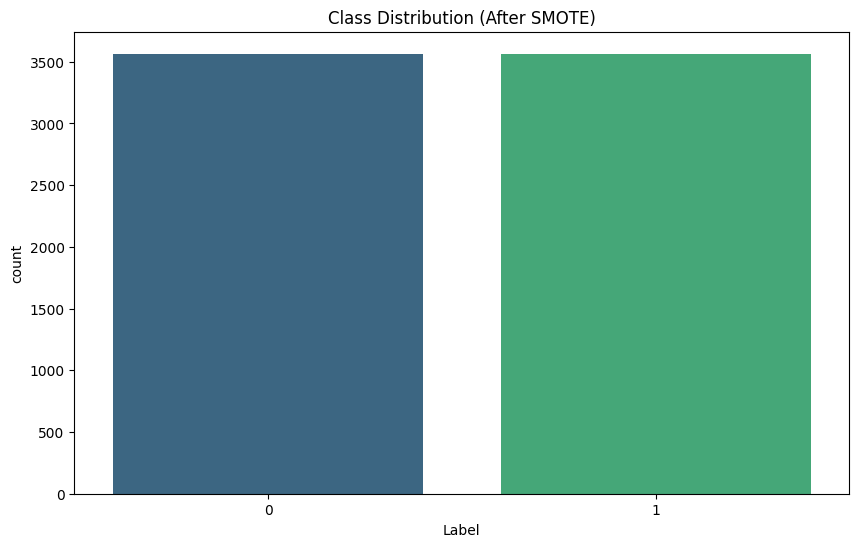

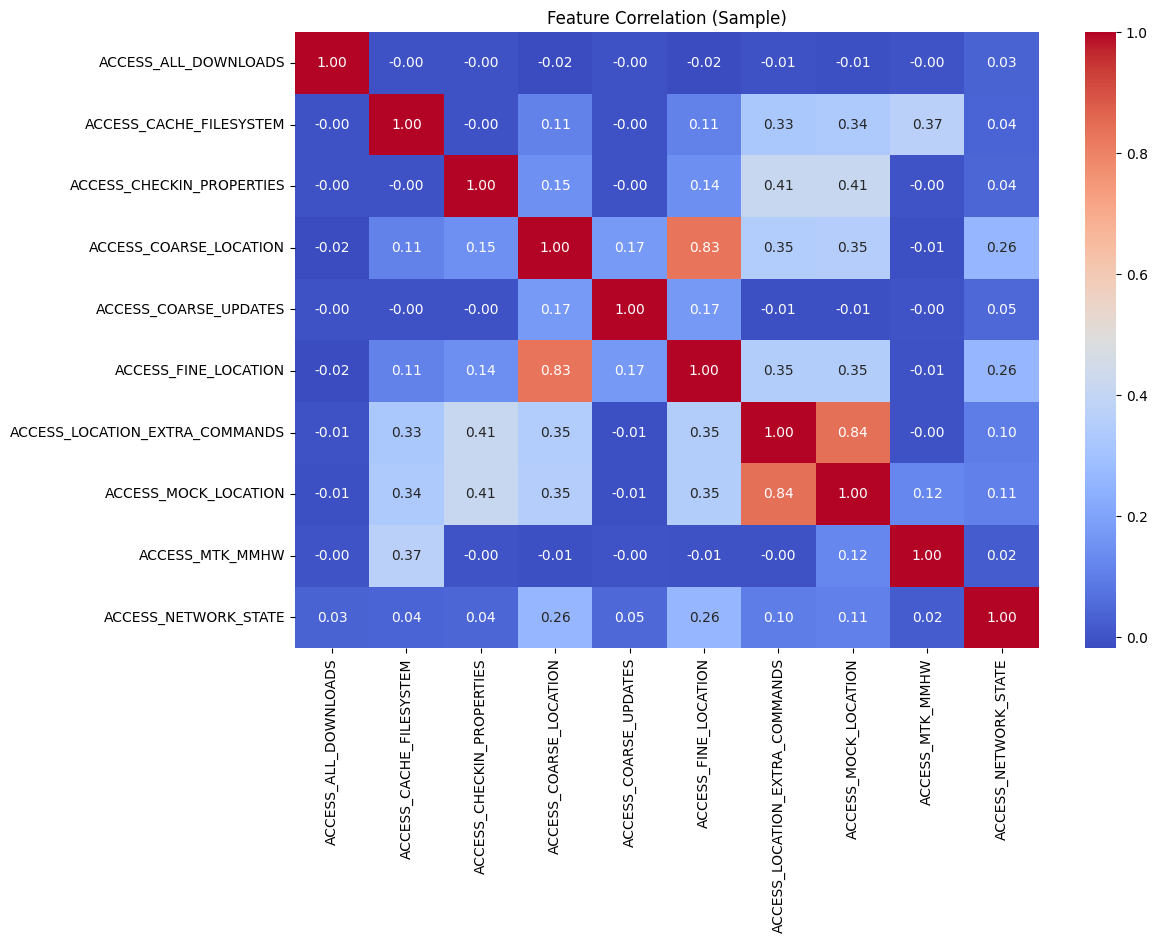

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=target_resampled, palette='viridis')  # Use the resampled target
plt.title('Class Distribution (After SMOTE)')
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(features_resampled.corr().iloc[:10, :10], cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Feature Correlation (Sample)')
plt.show()

###Split the Dataset

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_resampled_scaled = scaler.fit_transform(features_resampled)

features_resampled_scaled = pd.DataFrame(features_resampled_scaled, columns=features.columns)

print(f"Shape of scaled features: {features_resampled_scaled.shape}")#Shape of scaled features: (7130, 241)


Shape of scaled features: (7130, 241)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features_resampled_scaled, target_resampled, test_size=0.2, random_state=42)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Normalize features using MinMaxScaler
normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train_scaled)
X_test_normalized = normalizer.transform(X_test_scaled)

X_train_scaled=X_train_normalized
X_test_scaled =X_test_normalized

###Preprocessing

In [ ]:

np.savez('processed_data.npz',
         X_train=features_resampled_scaled[:len(X_train)],
         X_test=features_resampled_scaled[len(X_train):],
         y_train=y_train,
         y_test=y_test)

print("Data Preparation Completed.")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Data Preparation Completed.


##Model Initialization

Baseline Model Performance:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       694
           1       0.99      0.99      0.99       732

    accuracy                           0.99      1426
   macro avg       0.99      0.99      0.99      1426
weighted avg       0.99      0.99      0.99      1426

AUC-ROC: 0.9994911497456733


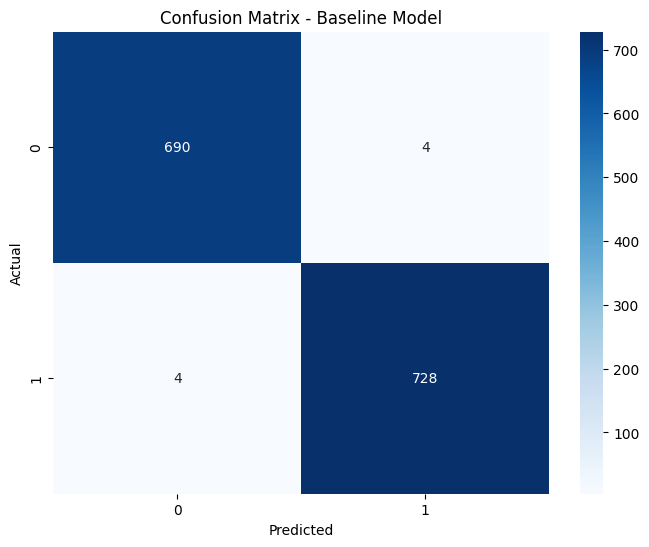

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

# Evaluate the baseline model
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Model Performance:")
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



Class distribution:
 1    3565
0     899
Name: count, dtype: int64


<ipython-input-26-50fb9b1ac43c>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


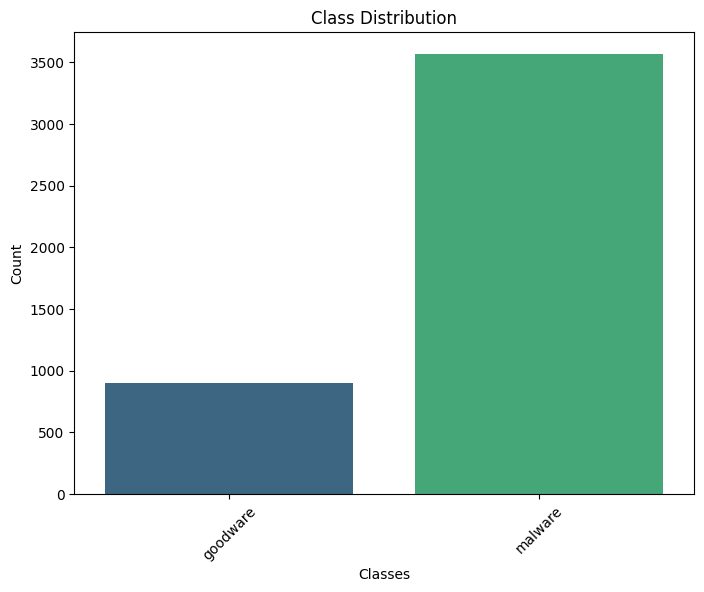

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Class distribution after SMOTE:
 1    3565
0    3565
Name: count, dtype: int64


<ipython-input-26-50fb9b1ac43c>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts_resampled.index, y=class_counts_resampled.values, palette="viridis")


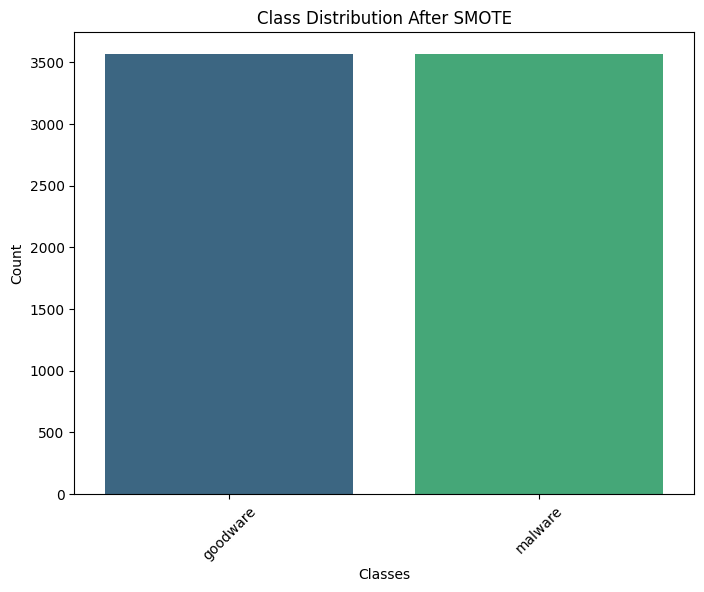

Resampled permission features shape: (7130, 64)
Resampled API features shape: (7130, 18)


In [ ]:
permission_features = [col for col in data.columns if col.startswith(('ACCESS_', 'WRITE_', 'READ_', 'PERMISSION_'))]
api_features = [col for col in data.columns if col.startswith('Landroid/')]

X_permissions = data[permission_features]
X_apis = data[api_features]
y = data['Label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_counts = pd.Series(y_encoded).value_counts()
print("Class distribution:\n", class_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(ticks=range(len(class_counts)), labels=label_encoder.classes_, rotation=45)
plt.show()

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_resampled, y_resampled = smote.fit_resample(data[permission_features + api_features], y_encoded)

X_resampled_df = pd.DataFrame(X_resampled, columns=permission_features + api_features)

class_counts_resampled = pd.Series(y_resampled).value_counts()
print("Class distribution after SMOTE:\n", class_counts_resampled)

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts_resampled.index, y=class_counts_resampled.values, palette="viridis")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(ticks=range(len(class_counts_resampled)), labels=label_encoder.classes_, rotation=45)
plt.show()

X_permissions_resampled = X_resampled_df[permission_features]
X_apis_resampled = X_resampled_df[api_features]

print("Resampled permission features shape:", X_permissions_resampled.shape)
print("Resampled API features shape:", X_apis_resampled.shape)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.Clas


Model Performance on Combined (Resampled) Features:
Accuracy: 0.8758765778401122
Confusion Matrix:
 [[656  57]
 [120 593]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88       713
           1       0.91      0.83      0.87       713

    accuracy                           0.88      1426
   macro avg       0.88      0.88      0.88      1426
weighted avg       0.88      0.88      0.88      1426



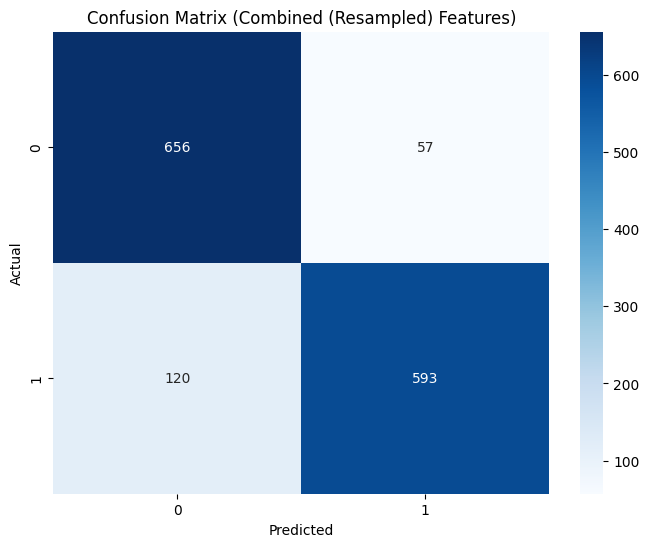

AUC-ROC: 0.924699381748297


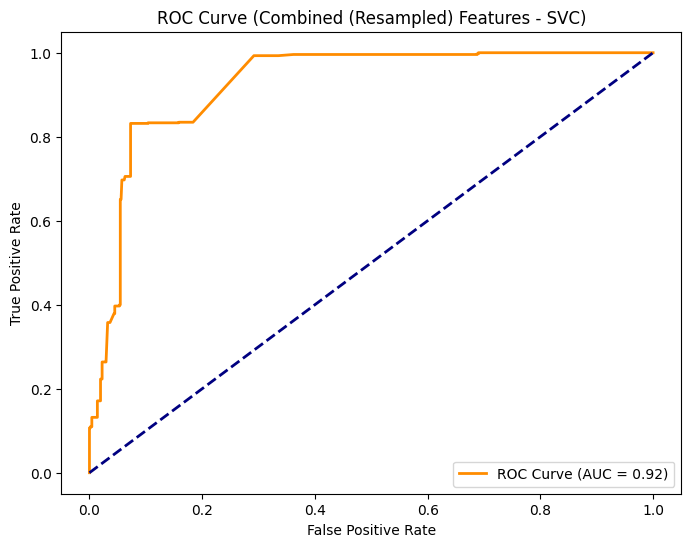


Model Performance on Combined (Resampled) Features:
Accuracy: 0.9291725105189341
Confusion Matrix:
 [[619  94]
 [  7 706]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.92       713
           1       0.88      0.99      0.93       713

    accuracy                           0.93      1426
   macro avg       0.94      0.93      0.93      1426
weighted avg       0.94      0.93      0.93      1426



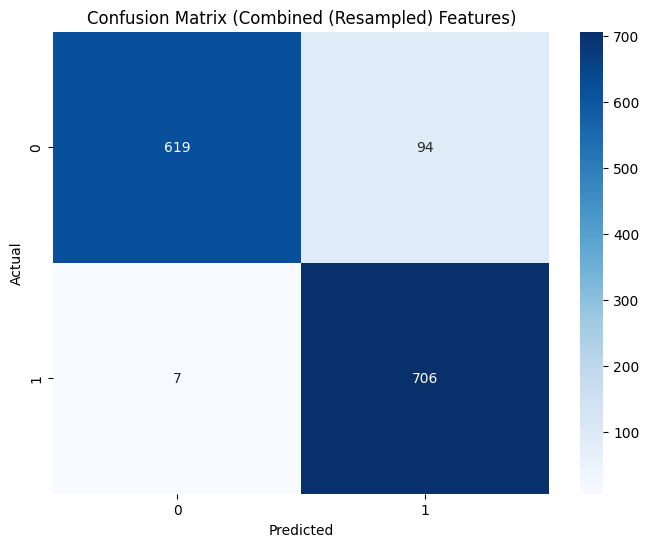

AUC-ROC: 0.9834519807462689


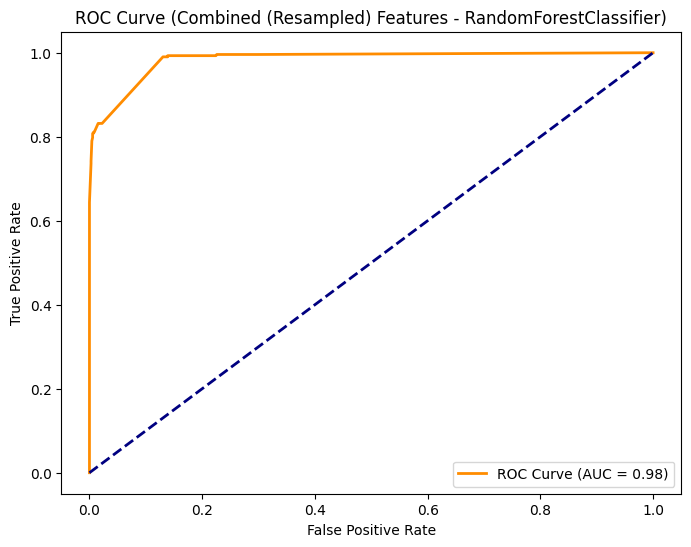


Model Performance on Combined (Resampled) Features:
Accuracy: 0.8674614305750351
Confusion Matrix:
 [[645  68]
 [121 592]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87       713
           1       0.90      0.83      0.86       713

    accuracy                           0.87      1426
   macro avg       0.87      0.87      0.87      1426
weighted avg       0.87      0.87      0.87      1426



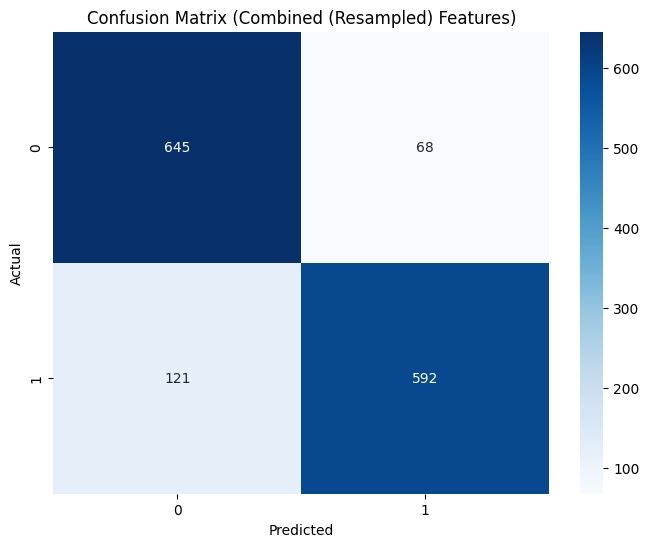

AUC-ROC: 0.9519118986405544


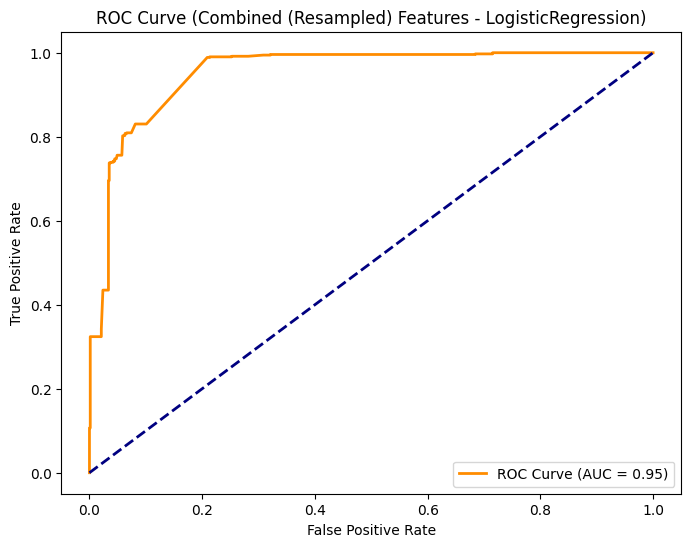

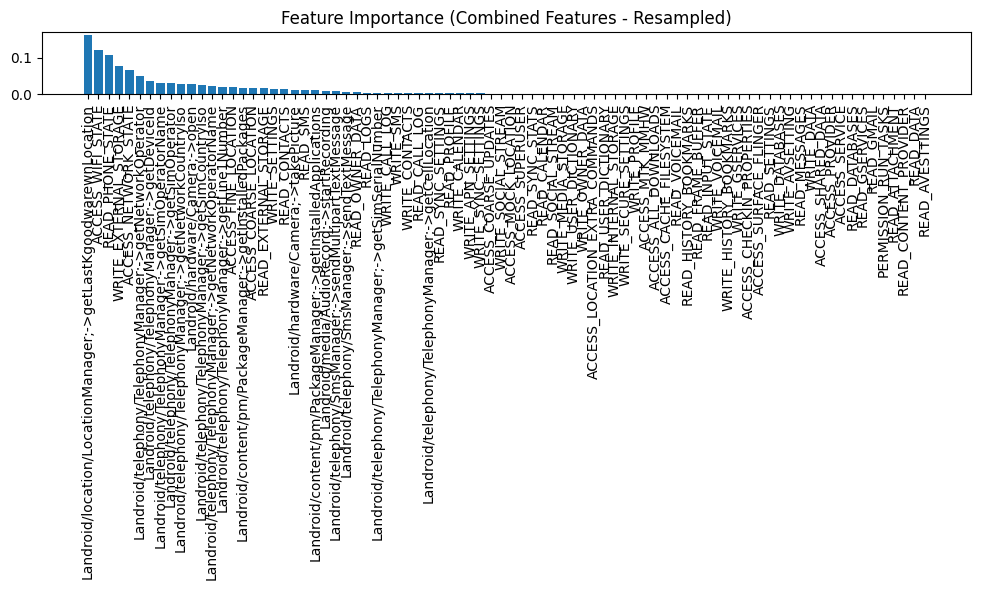


Model Performance on Permission-Based (Resampled) Features:
Accuracy: 0.8373071528751753
Confusion Matrix:
 [[544 169]
 [ 63 650]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.82       713
           1       0.79      0.91      0.85       713

    accuracy                           0.84      1426
   macro avg       0.84      0.84      0.84      1426
weighted avg       0.84      0.84      0.84      1426



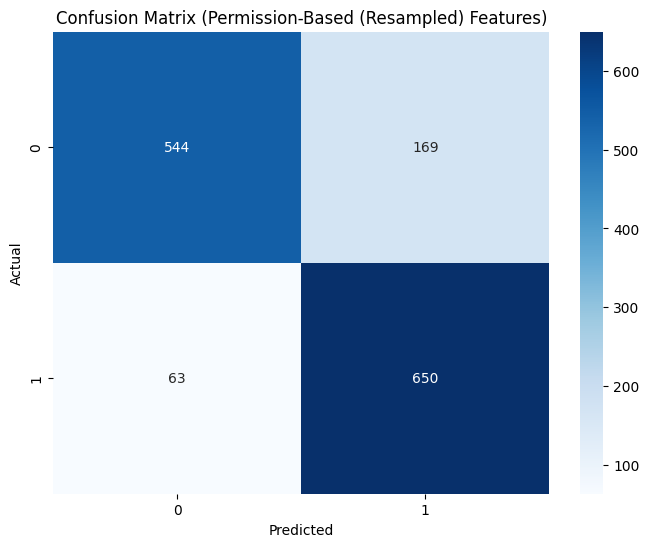

AUC-ROC: 0.863901024649418


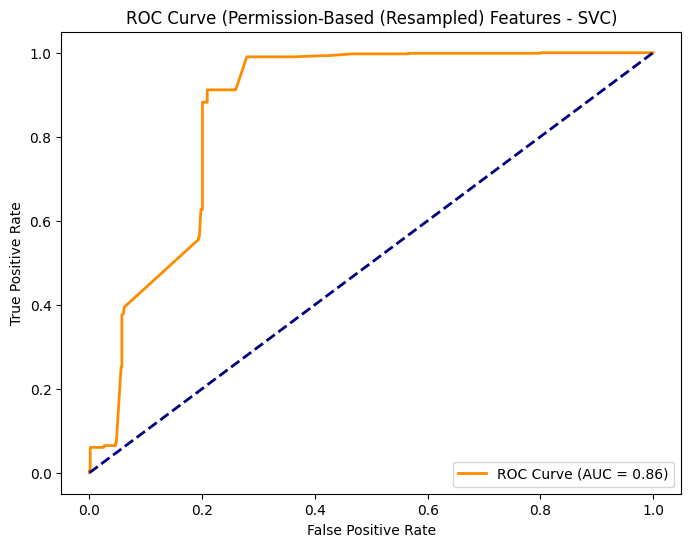


Model Performance on Permission-Based (Resampled) Features:
Accuracy: 0.8962131837307152
Confusion Matrix:
 [[688  25]
 [123 590]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90       713
           1       0.96      0.83      0.89       713

    accuracy                           0.90      1426
   macro avg       0.90      0.90      0.90      1426
weighted avg       0.90      0.90      0.90      1426



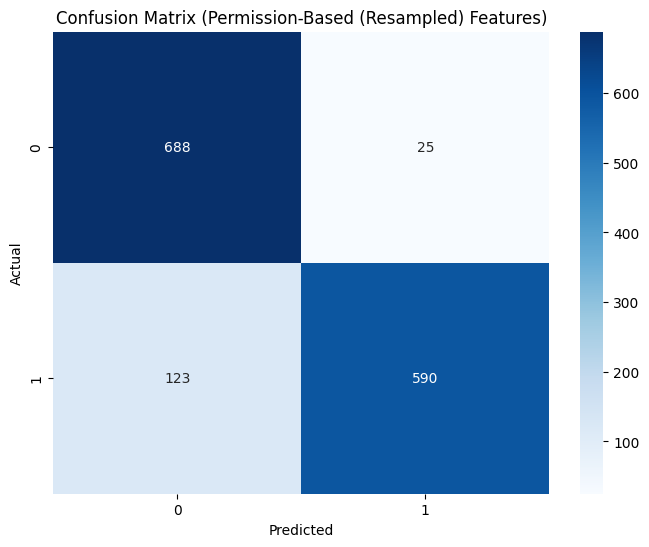

AUC-ROC: 0.9774032248229141


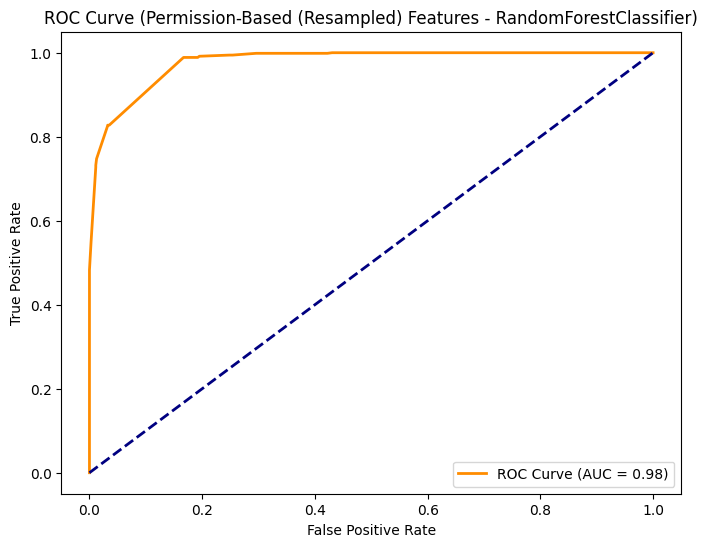


Model Performance on Permission-Based (Resampled) Features:
Accuracy: 0.8127629733520336
Confusion Matrix:
 [[507 206]
 [ 61 652]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.71      0.79       713
           1       0.76      0.91      0.83       713

    accuracy                           0.81      1426
   macro avg       0.83      0.81      0.81      1426
weighted avg       0.83      0.81      0.81      1426



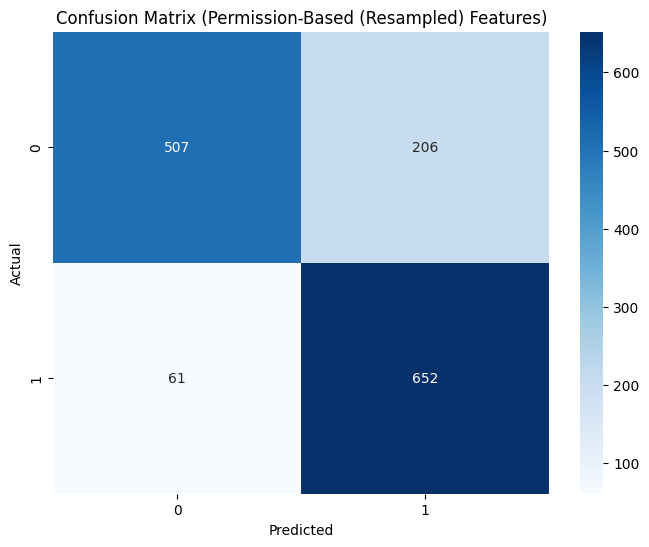

AUC-ROC: 0.8953073456485348


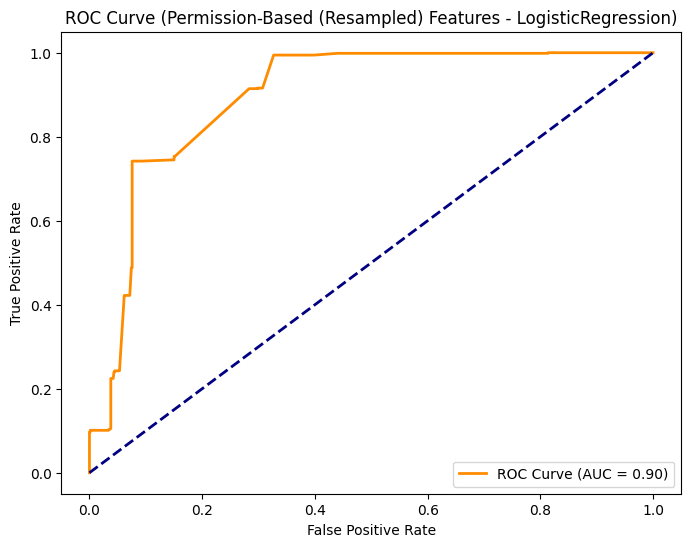

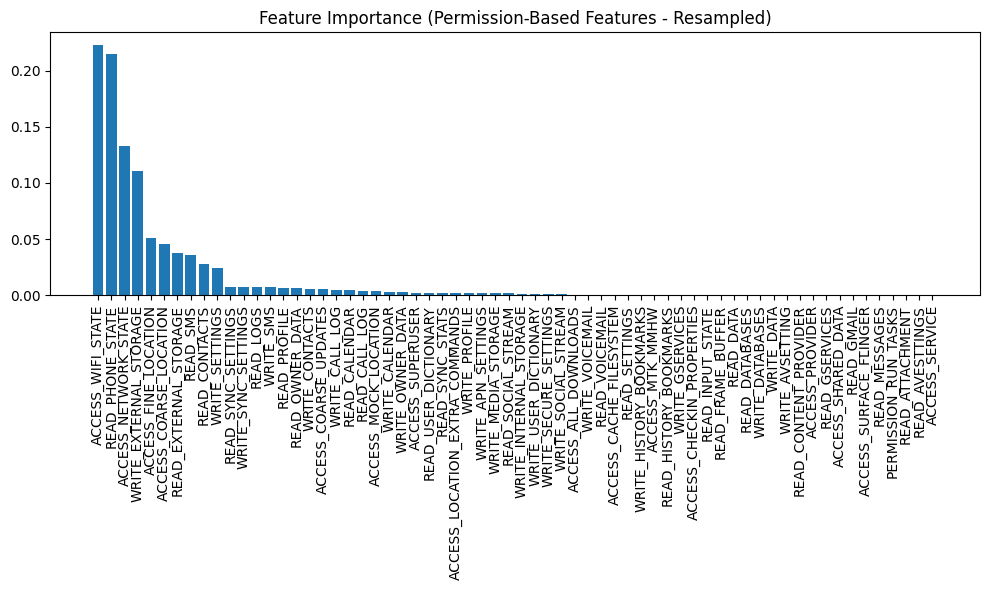


Model Performance on API-Based (Resampled) Features:
Accuracy: 0.8141654978962132
Confusion Matrix:
 [[455 258]
 [  7 706]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.64      0.77       713
           1       0.73      0.99      0.84       713

    accuracy                           0.81      1426
   macro avg       0.86      0.81      0.81      1426
weighted avg       0.86      0.81      0.81      1426



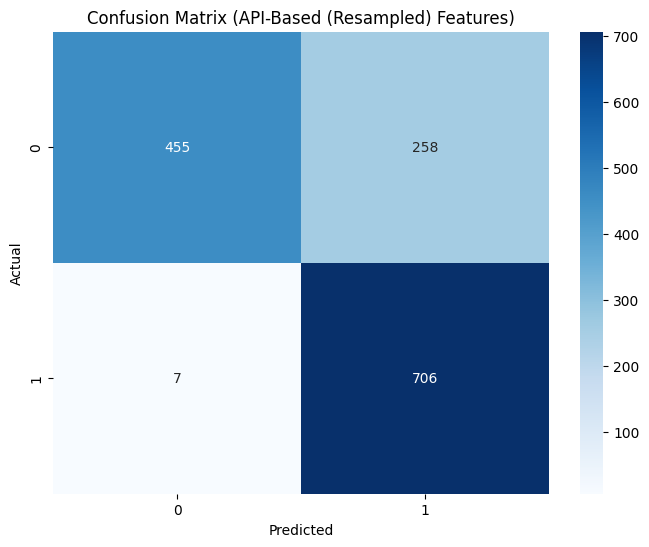

AUC-ROC: 0.836835054851889


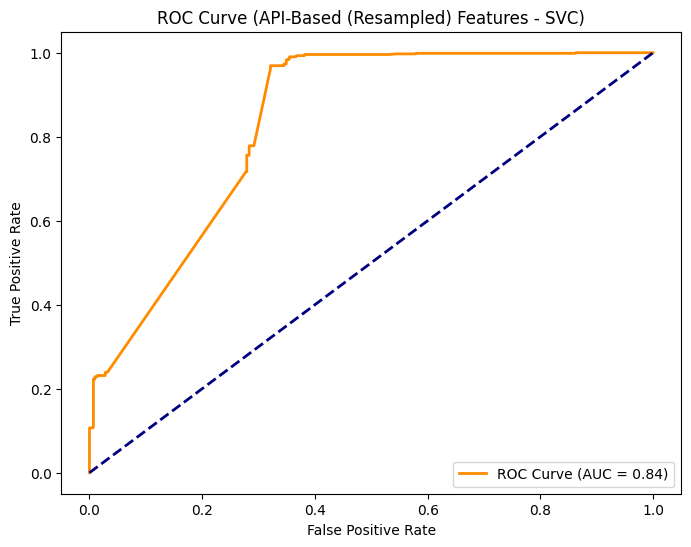


Model Performance on API-Based (Resampled) Features:
Accuracy: 0.8562412342215989
Confusion Matrix:
 [[511 202]
 [  3 710]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.72      0.83       713
           1       0.78      1.00      0.87       713

    accuracy                           0.86      1426
   macro avg       0.89      0.86      0.85      1426
weighted avg       0.89      0.86      0.85      1426



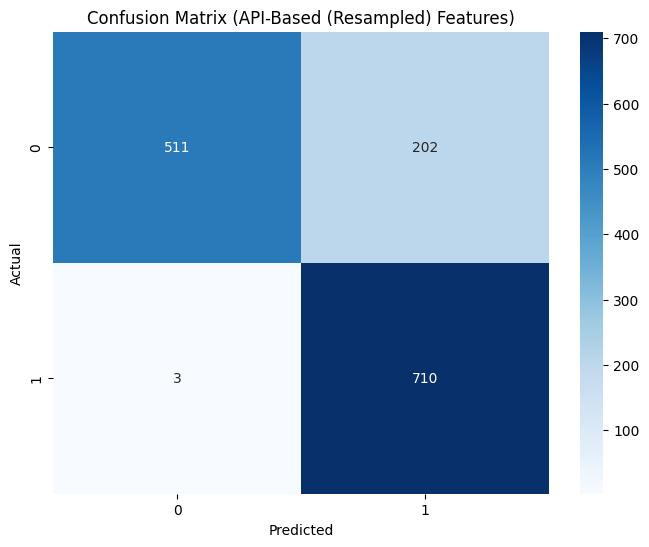

AUC-ROC: 0.9196105584722908


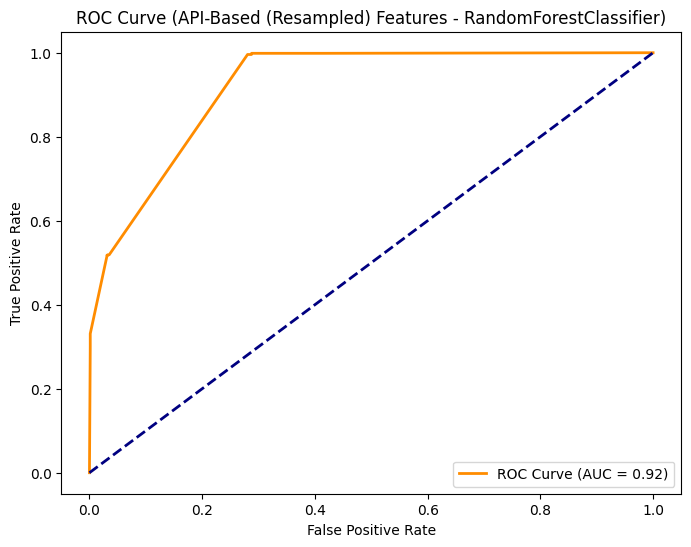


Model Performance on API-Based (Resampled) Features:
Accuracy: 0.8225806451612904
Confusion Matrix:
 [[469 244]
 [  9 704]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.66      0.79       713
           1       0.74      0.99      0.85       713

    accuracy                           0.82      1426
   macro avg       0.86      0.82      0.82      1426
weighted avg       0.86      0.82      0.82      1426



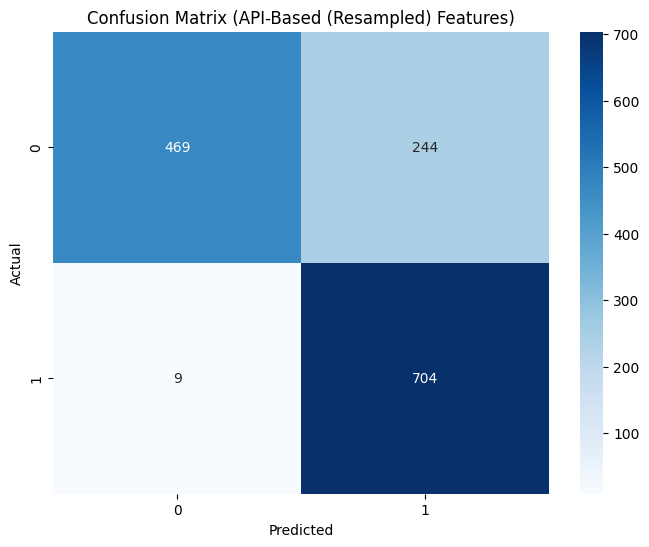

AUC-ROC: 0.8844618771010819


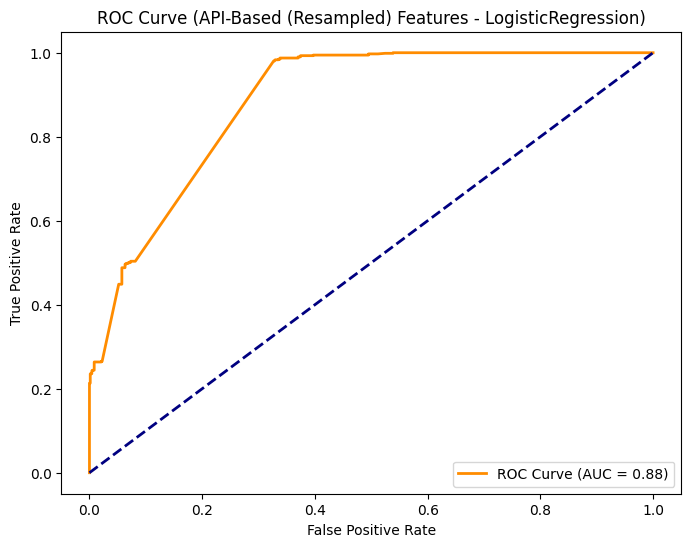

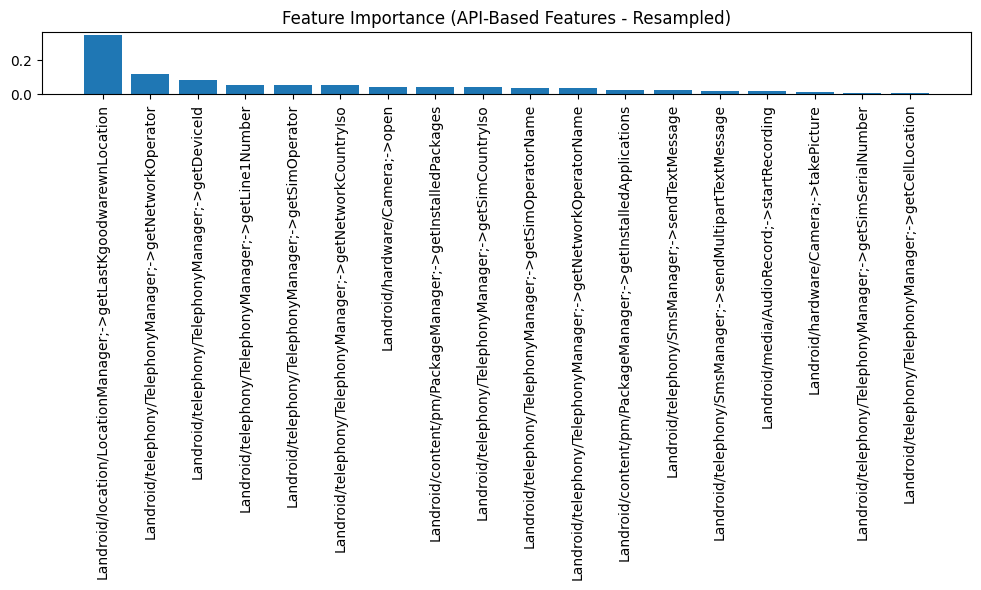

In [ ]:
min_class_count = class_counts.min()
if min_class_count < 2:
    print("Warning: Some classes have fewer than 2 instances. Removing these instances.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(label_encoder.inverse_transform(valid_classes))]
    y = data['Label']
    y_encoded = label_encoder.fit_transform(y)
    X_permissions = data[permission_features]
    X_apis = data[api_features]

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_resampled, y_resampled = smote.fit_resample(data[permission_features + api_features], y_encoded)

X_resampled_df = pd.DataFrame(X_resampled, columns=permission_features + api_features)

X_permissions_resampled = X_resampled_df.iloc[:, :len(permission_features)]  # Permission features slice
X_apis_resampled = X_resampled_df.iloc[:, len(permission_features):]  # API features slice

scaler = StandardScaler()
X_permissions_resampled_scaled = scaler.fit_transform(X_permissions_resampled)
X_apis_resampled_scaled = scaler.fit_transform(X_apis_resampled)
X_resampled_combined = np.hstack((X_permissions_resampled_scaled, X_apis_resampled_scaled))

# Split data into train and test sets (80-20 split) for resampled data
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(
    X_resampled_combined, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

Xp_train_resampled, Xp_test_resampled, yp_train_resampled, yp_test_resampled = train_test_split(
    X_permissions_resampled_scaled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

Xa_train_resampled, Xa_test_resampled, ya_train_resampled, ya_test_resampled = train_test_split(
    X_apis_resampled_scaled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

def plot_feature_importance(model, feature_names, title):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(importances)), importances[indices], align="center")
        plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
        plt.title(title)
        plt.tight_layout()
        plt.show()

# Function to plot ROC curve
def plot_roc_curve(y_test, y_pred_proba, feature_set, model_name):
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve ({feature_set} Features - {model_name})")
        plt.legend(loc="lower right")
        plt.show()

def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, feature_set):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    print(f"\nModel Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_pred_proba is not None:
        print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))
        plot_roc_curve(y_test, y_pred_proba, feature_set, model.__class__.__name__)

svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

train_and_evaluate_model(svm_model, X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled, "Combined (Resampled)")
train_and_evaluate_model(rf_model, X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled, "Combined (Resampled)")
train_and_evaluate_model(lr_model, X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled, "Combined (Resampled)")

combined_features = permission_features + api_features
plot_feature_importance(rf_model, combined_features, "Feature Importance (Combined Features - Resampled)")

train_and_evaluate_model(svm_model, Xp_train_resampled, Xp_test_resampled, yp_train_resampled, yp_test_resampled, "Permission-Based (Resampled)")
train_and_evaluate_model(rf_model, Xp_train_resampled, Xp_test_resampled, yp_train_resampled, yp_test_resampled, "Permission-Based (Resampled)")
train_and_evaluate_model(lr_model, Xp_train_resampled, Xp_test_resampled, yp_train_resampled, yp_test_resampled, "Permission-Based (Resampled)")

plot_feature_importance(rf_model, permission_features, "Feature Importance (Permission-Based Features - Resampled)")

train_and_evaluate_model(svm_model, Xa_train_resampled, Xa_test_resampled, ya_train_resampled, ya_test_resampled, "API-Based (Resampled)")
train_and_evaluate_model(rf_model, Xa_train_resampled, Xa_test_resampled, ya_train_resampled, ya_test_resampled, "API-Based (Resampled)")
train_and_evaluate_model(lr_model, Xa_train_resampled, Xa_test_resampled, ya_train_resampled, ya_test_resampled, "API-Based (Resampled)")

plot_feature_importance(rf_model, api_features, "Feature Importance (API-Based Features - Resampled)")

## Implement Active Learning and RL


###Active Learning Setup

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


smote = SMOTE(sampling_strategy='auto', random_state=0)
X_resampled, y_resampled = smote.fit_resample(features, target)

print(X_resampled.shape)#(7130, 241)

print(y_resampled.shape)#(7130,)


# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled)

# Check if the scaling worked
print(X_train_scaled.shape)#(7130, 241)


# Train the model
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train_scaled, y_resampled)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.Clas

(7130, 241)
(7130,)
(7130, 241)


RandomForestClassifier(random_state=42)

#### Create RL Agent


In [ ]:
def uncertainty_sampling(probs, n_samples):
    """Select samples with the highest uncertainty."""
    uncertainty = 1 - np.max(probs, axis=1)
    uncertain_indices = np.argsort(uncertainty)[-n_samples:]  # Indices of the most uncertain samples
    return uncertain_indices

n_iterations = 5
for i in range(n_iterations):
    # Get predicted probabilities from the model
    probs = baseline_model.predict_proba(X_train_scaled)

    # Select uncertain samples
    uncertain_indices = uncertainty_sampling(probs, n_samples=int(0.1 * len(X_train_scaled)))

    # Extract the most uncertain samples for active learning
    X_active = X_train_scaled[uncertain_indices]
    y_active = y_resampled[uncertain_indices]

    # Optionally, remove selected samples from the pool to avoid duplicates
    X_train_scaled = np.delete(X_train_scaled, uncertain_indices, axis=0)
    y_resampled = np.delete(y_resampled, uncertain_indices, axis=0)

    # Add selected active samples to training data
    X_train_scaled = np.concatenate([X_train_scaled, X_active])
    y_resampled = np.concatenate([y_resampled, y_active])

    # Retrain the baseline model with the expanded dataset
    baseline_model.fit(X_train_scaled, y_resampled)

    # Evaluate the model on the test set
    X_test_scaled = scaler.transform(X_test)  # Ensure scaling of the test set
    y_pred = baseline_model.predict(X_test_scaled)

    print(f"Iteration {i+1} - Accuracy: {accuracy_score(y_test, y_pred)}")




/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Iteration 1 - Accuracy: 0.9270687237026648
Iteration 2 - Accuracy: 0.9200561009817672
Iteration 3 - Accuracy: 0.9172510518934082
Iteration 4 - Accuracy: 0.9256661991584852
Iteration 5 - Accuracy: 0.9242636746143057


In [ ]:
# Split the resampled dataset into active learning pool and test set
X_train_active, X_active_pool, y_train_active, y_active_pool = train_test_split(
    X_resampled_combined, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
class ActiveLearningEnv(gym.Env):
    def __init__(self, model, X_pool, y_pool, X_test, y_test):
        """
        Reinforcement learning environment for active learning.
        """
        self.model = model
        self.X_pool = X_pool
        self.y_pool = y_pool
        self.X_test = X_test
        self.y_test = y_test
        self.action_space = gym.spaces.Discrete(len(X_pool))  # Actions: select samples

        # Observation space: features of a sample in the pool
        self.observation_space = gym.spaces.Box(
            low=0, high=1, shape=(X_pool.shape[1],), dtype=np.float32
        )

    def step(self, action):
        """
        Perform an action by selecting a sample from the pool and training the model.
        """
        # Ensure action is within valid bounds
        action = min(max(0, action), len(self.X_pool) - 1)

        # Select sample based on the action index
        X_selected = self.X_pool[action].reshape(1, -1)  # Ensure 2D for training
        y_selected = [self.y_pool[action]]

        # Train the model incrementally with the selected sample
        self.model.fit(X_selected, y_selected)

        # Get predicted probabilities for the test set
        y_pred_prob = self.model.predict_proba(self.X_test)

        # Step 1: Inspect the output of predict_proba() (optional, for debugging)
        print(f"Shape of predicted probabilities: {y_pred_prob.shape}")

        # Step 2: Handle binary classification
        if y_pred_prob.shape[1] > 1:
            y_pred_prob_class_1 = y_pred_prob[:, 1]  # Probability of class 1
        else:
            # For binary classification with only one output (e.g., 0 or 1 prediction)
            y_pred_prob_class_1 = y_pred_prob.ravel()  # Flatten the output to 1D

        # Step 3: Calculate reward using AUC score
        reward = roc_auc_score(self.y_test, y_pred_prob_class_1)

        # Remove the selected sample from the pool
        self.X_pool = np.delete(self.X_pool, action, axis=0)
        self.y_pool = np.delete(self.y_pool, action, axis=0)

        # After removal, adjust the action space size
        self.action_space = gym.spaces.Discrete(len(self.X_pool))

        done = True  # End episode after one sample is selected

        # Return the new state, reward, done status, and any additional info
        return self.X_pool[0] if len(self.X_pool) > 0 else None, reward, done, {}

    def reset(self):
        """
        Reset the environment.
        """
        return self.X_pool[0] if len(self.X_pool) > 0 else None




/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


###Initialize RL environment and agent

In [ ]:

model = baseline_model

X_pool = X_active  # Active learning pool features
y_pool = y_active  # Active learning pool labels

env = ActiveLearningEnv(model=model, X_pool=X_pool, y_pool=y_pool, X_test=X_test_scaled, y_test=y_test)

agent = DQN('MlpPolicy', env, verbose=1)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


###Reinforcement Learning Loop

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from scipy.optimize import minimize

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define a simple neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Model, loss, and optimizer
input_size = X_train.shape[1]
num_classes = len(np.unique(y))
model = NeuralNet(input_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

train_model(model, train_loader, criterion, optimizer, epochs=10)

# Fast Gradient Sign Method (FGSM) Attack
def fgsm_attack(model, data, labels, eps):
    data.requires_grad = True
    outputs = model(data)
    loss = criterion(outputs, labels)

    # Backward pass
    model.zero_grad()
    loss.backward()

    # Generate perturbation
    grad = data.grad.data
    adv_data = data + eps * grad.sign()
    adv_data = torch.clamp(adv_data, 0, 1)  # Ensure valid data
    return adv_data

# Projected Gradient Descent (PGD) Attack
def pgd_attack(model, data, labels, eps, alpha, iters):
    adv_data = data.clone().detach().to(device)
    adv_data.requires_grad = True

    for _ in range(iters):
        adv_data.requires_grad = True
        outputs = model(adv_data)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        # Generate adversarial perturbation
        grad = adv_data.grad.data
        adv_data = adv_data + alpha * grad.sign()

        # Clamp to epsilon-ball
        perturbation = torch.clamp(adv_data - data, min=-eps, max=eps)
        adv_data = torch.clamp(data + perturbation, min=0, max=1).detach()

    return adv_data

# Carlini-Wagner (CW) Attack
def cw_attack(model, data, labels, c=1e-4, lr=0.01, max_iters=10):
    adv_data = data.clone().detach().to(device)
    adv_data.requires_grad = True

    for _ in range(max_iters):
        adv_data.requires_grad = True
        outputs = model(adv_data)
        one_hot_labels = torch.eye(len(outputs[0]))[labels].to(device)

        # CW Loss
        real = (one_hot_labels * outputs).sum(dim=1)
        other = ((1 - one_hot_labels) * outputs - one_hot_labels * 1e4).max(dim=1)[0]
        loss = torch.clamp(real - other + c, min=0).mean()

        model.zero_grad()
        loss.backward()
        grad = adv_data.grad.data

        # Update adversarial examples
        adv_data = adv_data - lr * grad
        adv_data = torch.clamp(adv_data, 0, 1).detach()

    return adv_data

# Test all attacks
eps = 0.1
alpha = 0.01
iters = 10

model.eval()

for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    # FGSM Attack
    adv_fgsm = fgsm_attack(model, X_batch, y_batch, eps)
    outputs_fgsm = model(adv_fgsm)
    _, preds_fgsm = outputs_fgsm.max(1)

    # PGD Attack
    adv_pgd = pgd_attack(model, X_batch, y_batch, eps, alpha, iters)
    outputs_pgd = model(adv_pgd)
    _, preds_pgd = outputs_pgd.max(1)

    # CW Attack
    adv_cw = cw_attack(model, X_batch, y_batch, c=1e-4, lr=0.01, max_iters=10)
    outputs_cw = model(adv_cw)
    _, preds_cw = outputs_cw.max(1)

    print(f"Original Labels: {y_batch[:5].cpu().numpy()}")
    print(f"FGSM Predictions: {preds_fgsm[:5].cpu().numpy()}")
    print(f"PGD Predictions: {preds_pgd[:5].cpu().numpy()}")
    print(f"CW Predictions: {preds_cw[:5].cpu().numpy()}")
    break


Epoch [1/10], Loss: 0.0068
Epoch [2/10], Loss: 0.0087
Epoch [3/10], Loss: 0.0021
Epoch [4/10], Loss: 0.0053
Epoch [5/10], Loss: 0.0021
Epoch [6/10], Loss: 0.0029
Epoch [7/10], Loss: 0.0007
Epoch [8/10], Loss: 0.0020
Epoch [9/10], Loss: 0.0007
Epoch [10/10], Loss: 0.0016
Original Labels: [0 1 1 0 0]
FGSM Predictions: [0 1 1 0 1]
PGD Predictions: [0 1 1 0 1]
CW Predictions: [0 1 1 0 0]


Shape of predicted probabilities: (1426, 1)
Shape of predicted probabilities: (1426, 1)
Shape of predicted probabilities: (1426, 1)
Shape of predicted probabilities: (1426, 1)
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1        |
|    ep_rew_mean      | 0.5      |
|    exploration_rate | 0.62     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5        |
|    time_elapsed     | 0        |
|    total_timesteps  | 4        |
----------------------------------
Shape of predicted probabilities: (1426, 1)
Shape of predicted probabilities: (1426, 1)
Shape of predicted probabilities: (1426, 1)
Shape of predicted probabilities: (1426, 1)
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1        |
|    ep_rew_mean      | 0.5      |
|    exploration_rate | 0.24     |
| time/               |          |
|    episodes         | 8        |
|    fps          

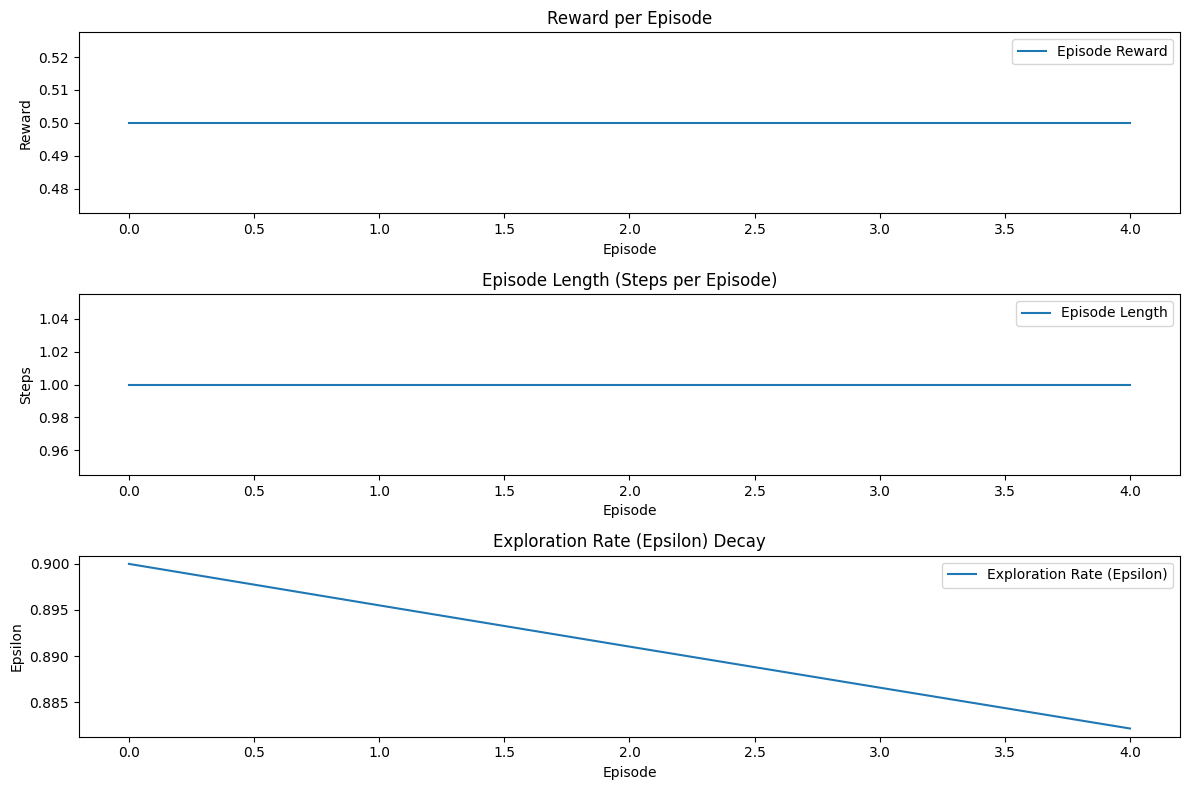

In [ ]:
agent.learn(total_timesteps=100)

epsilon = 0.9  # Initial exploration rate
epsilon_min = 0.05  # Minimum epsilon value
epsilon_decay = 0.995  # Decay factor for epsilon
num_iterations = 5  # Number of iterations
num_samples_per_iteration = 5  # Number of samples selected per iteration

episode_rewards = []
episode_lengths = []
exploration_rates = []

# Main loop for agent interaction with environment
for iteration in range(num_iterations):
    state = env.reset()  # Reset the environment at the start of each iteration
    done = False
    selected_samples = []

    total_reward = 0  # Track total reward for the current episode
    total_steps = 0  # Track the number of steps for the current episode

    while not done and len(selected_samples) < num_samples_per_iteration:
        # Epsilon-greedy strategy for exploration vs exploitation
        if np.random.rand() < epsilon:
            # Explore: Randomly select an action from available actions
            action = np.random.choice(len(env.X_pool))
        else:
            # Exploit: Use the agent's learned policy to predict the best action
            action = agent.predict(state)[0]  # Get the best action from the agent

        # Ensure action is within valid bounds
        action = min(max(0, action), len(env.X_pool) - 1)

        # Take a step in the environment
        state, reward, done, info = env.step(action)
        total_reward += reward
        total_steps += 1

        # Get the selected sample from the pool
        X_selected = env.X_pool[action]
        y_selected = env.y_pool[action]

        # Add the selected sample to the list
        selected_samples.append((X_selected, y_selected))

        # Print debug information
        print(f"Iteration {iteration}: Predicted actions: {action}, Reward = {reward}, Samples selected = {len(selected_samples)}")

        # Stop if we've selected enough samples
        if len(selected_samples) >= num_samples_per_iteration:
            break

    # Train the model on the selected samples
    if selected_samples:
        X_selected = np.array([sample[0] for sample in selected_samples])
        y_selected = np.array([sample[1] for sample in selected_samples])
        print(f"Model trained on {len(selected_samples)} samples in iteration {iteration}")

    # Store metrics for visualization
    episode_rewards.append(total_reward)
    episode_lengths.append(total_steps)
    exploration_rates.append(epsilon)

    # Optionally decay epsilon to reduce exploration over time
    epsilon = max(epsilon_min, epsilon * epsilon_decay)  # Gradually reduce epsilon (exploration rate)

# Visualization of metrics
plt.figure(figsize=(12, 8))

# Plotting the reward over episodes
plt.subplot(3, 1, 1)
plt.plot(episode_rewards, label="Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward per Episode")
plt.legend()

# Plotting the length of episodes (steps per episode)
plt.subplot(3, 1, 2)
plt.plot(episode_lengths, label="Episode Length")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Episode Length (Steps per Episode)")
plt.legend()

# Plotting the exploration rate over episodes
plt.subplot(3, 1, 3)
plt.plot(exploration_rates, label="Exploration Rate (Epsilon)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration Rate (Epsilon) Decay")
plt.legend()

plt.tight_layout()
plt.show()

##Adversarial Attack Integration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

#### Hyperparameter tuning

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
from stable_baselines3 import PPO
import gym
from gym import spaces


# LightGBM Model Training with Hyperparameter Tuning
def train_lightgbm(X_train, y_train):
    params = {
        'boosting_type': ['gbdt'],
        'num_leaves': [31, 50],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 500],
        'max_depth': [-1, 10, 20],
    }
    lgb_model = lgb.LGBMClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=lgb_model, param_grid=params, cv=3, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    print("Best Parameters:", grid_search.best_params_)
    return grid_search.best_estimator_

baseline_model = train_lightgbm(X_train_scaled, y_train)

# Define a custom Gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.action_space = spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] + action
        prob = self.model.predict_proba([perturbed_sample])[0]
        reward = -np.max(prob)  # Encourage high uncertainty
        done = True
        return perturbed_sample, reward, done, {}

# Train the adversarial RL agent
env = AdversarialEnv(baseline_model, X_train_scaled, y_train)
adversarial_agent = PPO("MlpPolicy", env, verbose=1)
adversarial_agent.learn(total_timesteps=10000)

# Generate adversarial samples
perturbations = []
for _ in range(100):
    obs = env.reset()
    action, _ = adversarial_agent.predict(obs)
    perturbations.append(obs + action)

# Augment training data
X_perturbed = np.vstack([X_train_scaled, perturbations])
y_perturbed = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])

# Retrain model with augmented data
augmented_model = train_lightgbm(X_perturbed, y_perturbed)

# Evaluate the final model
y_pred = augmented_model.predict(X_test_scaled)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Number of positive: 2833, number of negative: 2871
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3680
[LightGBM] [Info] Number of data points in the train set: 5704, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.496669 -> initscore=-0.013324
[LightGBM] [Info] Start training from score -0.013324
Best Parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 500, 'num_leaves': 31}
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -0.952   |
| time/              |         

####Diff attacks

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from scipy.optimize import minimize

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define a simple neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Model, loss, and optimizer
input_size = X_train.shape[1]
num_classes = len(np.unique(y))
model = NeuralNet(input_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

train_model(model, train_loader, criterion, optimizer, epochs=10)

# Fast Gradient Sign Method (FGSM) Attack
def fgsm_attack(model, data, labels, eps):
    data.requires_grad = True
    outputs = model(data)
    loss = criterion(outputs, labels)

    # Backward pass
    model.zero_grad()
    loss.backward()

    # Generate perturbation
    grad = data.grad.data
    adv_data = data + eps * grad.sign()
    adv_data = torch.clamp(adv_data, 0, 1)  # Ensure valid data
    return adv_data

# Projected Gradient Descent (PGD) Attack
def pgd_attack(model, data, labels, eps, alpha, iters):
    adv_data = data.clone().detach().to(device)
    adv_data.requires_grad = True

    for _ in range(iters):
        adv_data.requires_grad = True
        outputs = model(adv_data)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        # Generate adversarial perturbation
        grad = adv_data.grad.data
        adv_data = adv_data + alpha * grad.sign()

        # Clamp to epsilon-ball
        perturbation = torch.clamp(adv_data - data, min=-eps, max=eps)
        adv_data = torch.clamp(data + perturbation, min=0, max=1).detach()

    return adv_data

# Carlini-Wagner (CW) Attack
def cw_attack(model, data, labels, c=1e-4, lr=0.01, max_iters=10):
    adv_data = data.clone().detach().to(device)
    adv_data.requires_grad = True

    for _ in range(max_iters):
        outputs = model(adv_data)
        one_hot_labels = torch.eye(len(outputs[0]))[labels].to(device)

        # CW Loss
        real = (one_hot_labels * outputs).sum(dim=1)
        other = ((1 - one_hot_labels) * outputs - one_hot_labels * 1e4).max(dim=1)[0]
        loss = torch.clamp(real - other + c, min=0).mean()

        model.zero_grad()
        loss.backward()
        grad = adv_data.grad.data

        # Update adversarial examples
        adv_data = adv_data - lr * grad
        adv_data = torch.clamp(adv_data, 0, 1).detach()

    return adv_data

# Test all attacks
eps = 0.1
alpha = 0.01
iters = 10

model.eval()

for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    # FGSM Attack
    adv_fgsm = fgsm_attack(model, X_batch, y_batch, eps)
    outputs_fgsm = model(adv_fgsm)
    _, preds_fgsm = outputs_fgsm.max(1)

    # PGD Attack
    adv_pgd = pgd_attack(model, X_batch, y_batch, eps, alpha, iters)
    outputs_pgd = model(adv_pgd)
    _, preds_pgd = outputs_pgd.max(1)

    # CW Attack
    adv_cw = cw_attack(model, X_batch, y_batch, c=1e-4, lr=0.01, max_iters=10)
    outputs_cw = model(adv_cw)
    _, preds_cw = outputs_cw.max(1)

    print(f"Original Labels: {y_batch[:5].cpu().numpy()}")
    print(f"FGSM Predictions: {preds_fgsm[:5].cpu().numpy()}")
    print(f"PGD Predictions: {preds_pgd[:5].cpu().numpy()}")
    print(f"CW Predictions: {preds_cw[:5].cpu().numpy()}")
    break


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# FGSM Attack
def fgsm_attack(model, X, y, eps):
    X.requires_grad = True
    outputs = model(X)
    loss = nn.CrossEntropyLoss()(outputs, y)
    model.zero_grad()
    loss.backward()
    adv_X = X + eps * X.grad.sign()
    adv_X = torch.clamp(adv_X, 0, 1)  # Ensure features are in valid range
    return adv_X

# PGD Attack
def pgd_attack(model, X, y, eps, alpha, iters):
    model, data, labels, eps, alpha, iters= model, X, y, eps, alpha, iters
    adv_data = data.clone().detach().to(device)
    adv_data.requires_grad = True

    for _ in range(iters):
        adv_data.requires_grad = True
        outputs = model(adv_data)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        # Generate adversarial perturbation
        grad = adv_data.grad.data
        adv_data = adv_data + alpha * grad.sign()

        # Clamp to epsilon-ball
        perturbation = torch.clamp(adv_data - data, min=-eps, max=eps)
        adv_data = torch.clamp(data + perturbation, min=0, max=1).detach()

    return adv_data

# CW Attack
def cw_attack(model, X, y, c=1e-4, lr=0.01, max_iters=10):
    data, labels=X, y
    adv_data = data.clone().detach().to(device)
    adv_data.requires_grad = True

    for _ in range(max_iters):
        adv_data.requires_grad = True
        outputs = model(adv_data)
        one_hot_labels = torch.eye(len(outputs[0]))[labels].to(device)

        # CW Loss
        real = (one_hot_labels * outputs).sum(dim=1)
        other = ((1 - one_hot_labels) * outputs - one_hot_labels * 1e4).max(dim=1)[0]
        loss = torch.clamp(real - other + c, min=0).mean()

        model.zero_grad()
        loss.backward()
        grad = adv_data.grad.data

        # Update adversarial examples
        adv_data = adv_data - lr * grad
        adv_data = torch.clamp(adv_data, 0, 1).detach()

    return adv_data

# Model definition (example: simple MLP)
class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Data Preparation
def prepare_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.long))
    test_dataset = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    return train_loader, test_loader

# Evaluate Model on Adversarial Samples
def evaluate_attacks(model, test_loader, eps, alpha, iters, device):
    model.eval()
    all_preds_fgsm, all_preds_pgd, all_preds_cw = [], [], []
    all_targets = []

    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)


        # FGSM Attack
        adv_fgsm = fgsm_attack(model, X_batch, y_batch, eps)
        outputs_fgsm = model(adv_fgsm)
        _, preds_fgsm = outputs_fgsm.max(1)
        all_preds_fgsm.extend(preds_fgsm.cpu().numpy())

        # PGD Attack
        adv_pgd = pgd_attack(model, X_batch, y_batch, eps, alpha, iters)
        outputs_pgd = model(adv_pgd)
        _, preds_pgd = outputs_pgd.max(1)
        all_preds_pgd.extend(preds_pgd.cpu().numpy())

        # CW Attack
        adv_cw = cw_attack(model, X_batch, y_batch, c=1e-4, lr=0.01, max_iters=iters)
        outputs_cw = model(adv_cw)
        _, preds_cw = outputs_cw.max(1)
        all_preds_cw.extend(preds_cw.cpu().numpy())

        # Targets
        all_targets.extend(y_batch.cpu().numpy())

    # Calculate accuracy
    targets = np.array(all_targets)
    acc_fgsm = accuracy_score(targets, all_preds_fgsm)
    acc_pgd = accuracy_score(targets, all_preds_pgd)
    acc_cw = accuracy_score(targets, all_preds_cw)

    return acc_fgsm, acc_pgd, acc_cw

# Main Code
if __name__ == "__main__":

    # Data preparation
    train_loader, test_loader = prepare_data(X_combined, y_encoded)

    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Model training
    input_size = X_combined.shape[1]
    num_classes = len(np.unique(y_encoded))
    model = SimpleNN(input_size, num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Training loop
    model.train()
    for epoch in range(10):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        logging.info(f"Epoch {epoch+1}/10, Loss: {loss.item()}")

    # Evaluate attacks
    eps = 0.1
    alpha = 0.01
    iters = 10
    acc_fgsm, acc_pgd, acc_cw = evaluate_attacks(model, test_loader, eps, alpha, iters, device)

    # Print results
    print(f"Accuracy under FGSM attack (ε={eps}): {acc_fgsm:.2f}")
    print(f"Accuracy under PGD attack (ε={eps}, α={alpha}, iters={iters}): {acc_pgd:.2f}")
    print(f"Accuracy under CW attack: {acc_cw:.2f}")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Accuracy under FGSM attack (ε=0.1): 0.83
Accuracy under PGD attack (ε=0.1, α=0.01, iters=10): 0.81
Accuracy under CW attack: 0.85


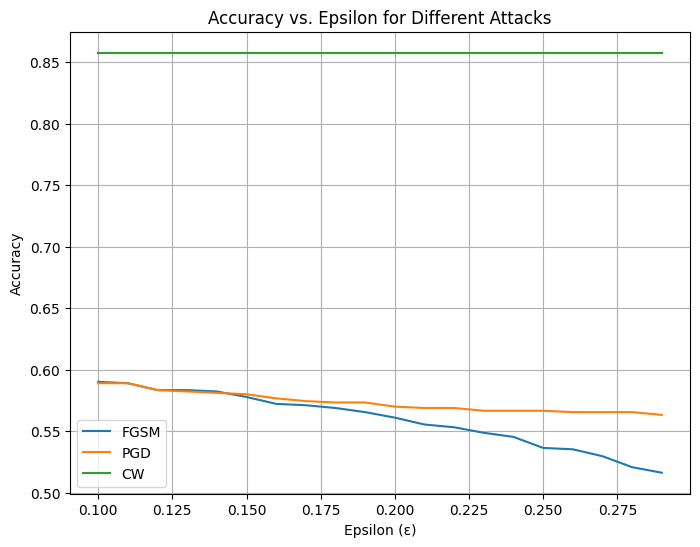

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have the `evaluate_attacks` function defined

# Define epsilon values
epsilons = np.arange(0.1, 0.3, 0.01)

# Initialize lists to store accuracies
acc_fgsm_list = []
acc_pgd_list = []
acc_cw_list = []

# Evaluate attacks for each epsilon
for eps in epsilons:
    alpha = 0.01
    iters = 10
    acc_fgsm, acc_pgd, acc_cw = evaluate_attacks(model, test_loader, eps, alpha, iters, device)

    acc_fgsm_list.append(acc_fgsm)
    acc_pgd_list.append(acc_pgd)
    acc_cw_list.append(acc_cw)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(epsilons, acc_fgsm_list, label='FGSM')
plt.plot(epsilons, acc_pgd_list, label='PGD')
plt.plot(epsilons, acc_cw_list, label='CW')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epsilon for Different Attacks')
plt.legend()
plt.grid(True)
plt.show()

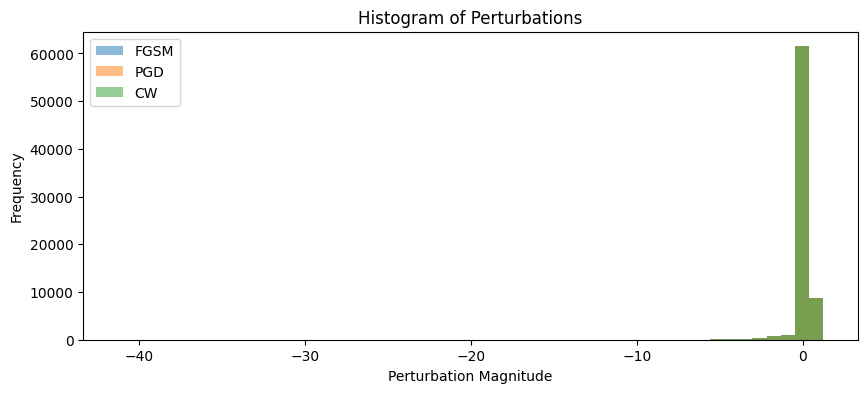

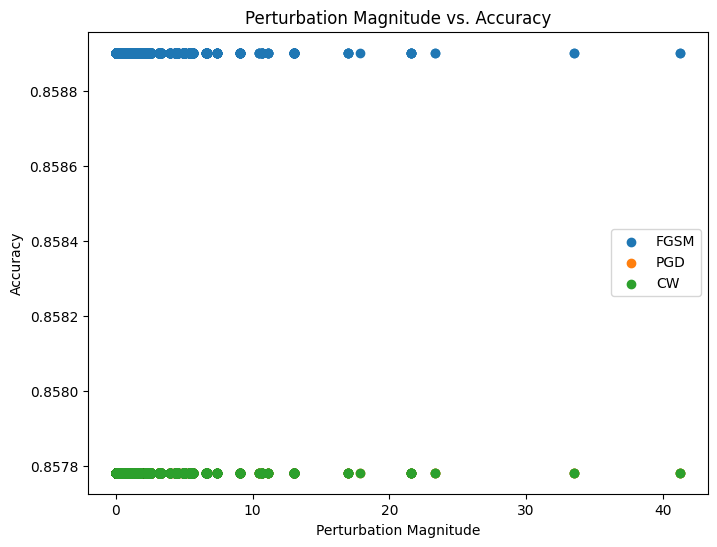

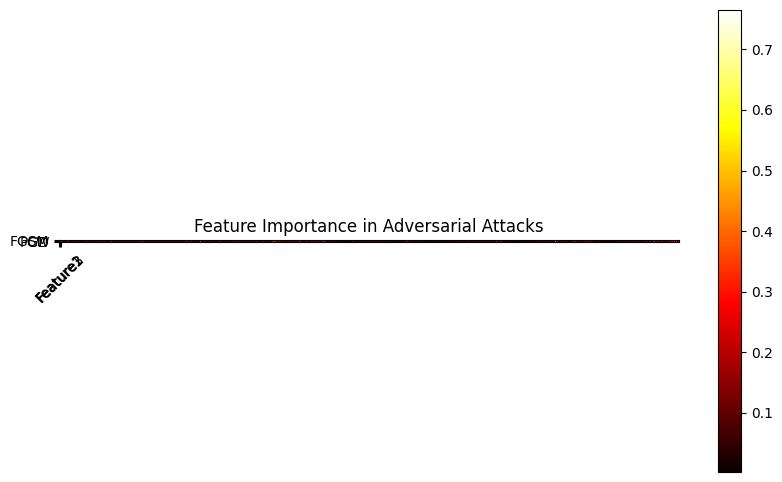

Accuracy under FGSM attack (ε=0.01): 0.86
Accuracy under PGD attack (ε=0.01, α=0.01, iters=10): 0.86
Accuracy under CW attack: 0.86


(0.858902575587906, 0.8577827547592385, 0.8577827547592385)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import pandas as pd
from sklearn.metrics import accuracy_score

# ... (your attack implementations: fgsm_attack, pgd_attack, cw_attack) ...

def evaluate_attacks(model, test_loader, eps, alpha, iters, device):
    model.eval()
    all_preds_fgsm, all_preds_pgd, all_preds_cw = [], [], []
    all_targets = []
    all_perturbations_fgsm, all_perturbations_pgd, all_perturbations_cw = [], [], []
    feature_importance_fgsm, feature_importance_pgd, feature_importance_cw = [], [], []

    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # FGSM Attack
        adv_fgsm = fgsm_attack(model, X_batch, y_batch, eps)
        outputs_fgsm = model(adv_fgsm)
        _, preds_fgsm = outputs_fgsm.max(1)
        all_preds_fgsm.extend(preds_fgsm.cpu().numpy())

        # Calculate and store perturbations for FGSM
        perturbations_fgsm = (adv_fgsm - X_batch).detach().cpu().numpy()  # Detach before converting to NumPy
        all_perturbations_fgsm.extend(perturbations_fgsm.flatten())

        # Calculate and store feature importance for FGSM (example using gradients)
        X_batch.requires_grad = True
        outputs = model(X_batch)
        loss = nn.CrossEntropyLoss()(outputs, y_batch)
        model.zero_grad()
        loss.backward()
        importance = torch.abs(X_batch.grad).sum(dim=0).cpu().numpy()
        feature_importance_fgsm.extend(importance)

        # PGD Attack
        adv_pgd = pgd_attack(model, X_batch, y_batch, eps, alpha, iters)
        outputs_pgd = model(adv_pgd)
        _, preds_pgd = outputs_pgd.max(1)
        all_preds_pgd.extend(preds_pgd.cpu().numpy())

        # Calculate and store perturbations for PGD
        perturbations_pgd = (adv_pgd - X_batch).detach().cpu().numpy()
        all_perturbations_pgd.extend(perturbations_pgd.flatten())

        # Calculate and store feature importance for PGD (example using gradients)
        X_batch.requires_grad = True
        outputs = model(X_batch)
        loss = nn.CrossEntropyLoss()(outputs, y_batch)
        model.zero_grad()
        loss.backward()
        importance = torch.abs(X_batch.grad).sum(dim=0).cpu().numpy()
        feature_importance_pgd.extend(importance)


        # CW Attack
        adv_cw = cw_attack(model, X_batch, y_batch, c=1e-4, lr=0.01, max_iters=iters)
        outputs_cw = model(adv_cw)
        _, preds_cw = outputs_cw.max(1)
        all_preds_cw.extend(preds_cw.cpu().numpy())

        # Calculate and store perturbations for CW
        perturbations_cw = (adv_cw - X_batch).detach().cpu().numpy()
        all_perturbations_cw.extend(perturbations_cw.flatten())

        # Calculate and store feature importance for CW (example using gradients)
        X_batch.requires_grad = True
        outputs = model(X_batch)
        loss = nn.CrossEntropyLoss()(outputs, y_batch)
        model.zero_grad()
        loss.backward()
        importance = torch.abs(X_batch.grad).sum(dim=0).cpu().numpy()
        feature_importance_cw.extend(importance)

        # Targets
        all_targets.extend(y_batch.cpu().numpy())

    # Calculate accuracy
    targets = np.array(all_targets)
    acc_fgsm = accuracy_score(targets, all_preds_fgsm)
    acc_pgd = accuracy_score(targets, all_preds_pgd)
    acc_cw = accuracy_score(targets, all_preds_cw)

    # --- Visualizations ---

    # 1. Perturbation Histograms
    plt.figure(figsize=(10, 4))
    plt.hist(all_perturbations_fgsm, bins=50, alpha=0.5, label='FGSM')
    plt.hist(all_perturbations_pgd, bins=50, alpha=0.5, label='PGD')
    plt.hist(all_perturbations_cw, bins=50, alpha=0.5, label='CW')
    plt.xlabel('Perturbation Magnitude')
    plt.ylabel('Frequency')
    plt.title('Histogram of Perturbations')
    plt.legend()
    plt.show()

    # 2. Scatter Plot: Perturbation Magnitude vs. Accuracy
    perturbation_magnitudes_fgsm = [np.mean(np.abs(p)) for p in all_perturbations_fgsm]  # Calculate mean perturbation magnitude for each sample
    perturbation_magnitudes_pgd = [np.mean(np.abs(p)) for p in all_perturbations_pgd]  # Calculate mean perturbation magnitude for each sample
    perturbation_magnitudes_cw = [np.mean(np.abs(p)) for p in all_perturbations_cw]  # Calculate mean perturbation magnitude for each sample

    plt.figure(figsize=(8, 6))
    plt.scatter(perturbation_magnitudes_fgsm, [acc_fgsm] * len(perturbation_magnitudes_fgsm), label='FGSM')
    plt.scatter(perturbation_magnitudes_pgd, [acc_pgd] * len(perturbation_magnitudes_pgd), label='PGD')
    plt.scatter(perturbation_magnitudes_cw, [acc_cw] * len(perturbation_magnitudes_cw), label='CW')
    plt.xlabel('Perturbation Magnitude')
    plt.ylabel('Accuracy')
    plt.title('Perturbation Magnitude vs. Accuracy')
    plt.legend()
    plt.show()

    # 3. Heatmap: Feature Importance
    feature_names = ['Feature1', 'Feature2', 'Feature3']  # Replace with actual feature names
    plt.figure(figsize=(10, 6))
    plt.imshow([feature_importance_fgsm, feature_importance_pgd, feature_importance_cw], cmap='hot', interpolation='nearest')
    plt.xticks(np.arange(len(feature_names)), feature_names, rotation=45)
    plt.yticks(np.arange(3), ['FGSM', 'PGD', 'CW'])
    plt.colorbar()
    plt.title('Feature Importance in Adversarial Attacks')
    plt.show()

    # Print results
    print(f"Accuracy under FGSM attack (ε={eps}): {acc_fgsm:.2f}")
    print(f"Accuracy under PGD attack (ε={eps}, α={alpha}, iters={iters}): {acc_pgd:.2f}")
    print(f"Accuracy under CW attack: {acc_cw:.2f}")

    return acc_fgsm, acc_pgd, acc_cw
evaluate_attacks(model, test_loader, 0.01, alpha, iters, device)


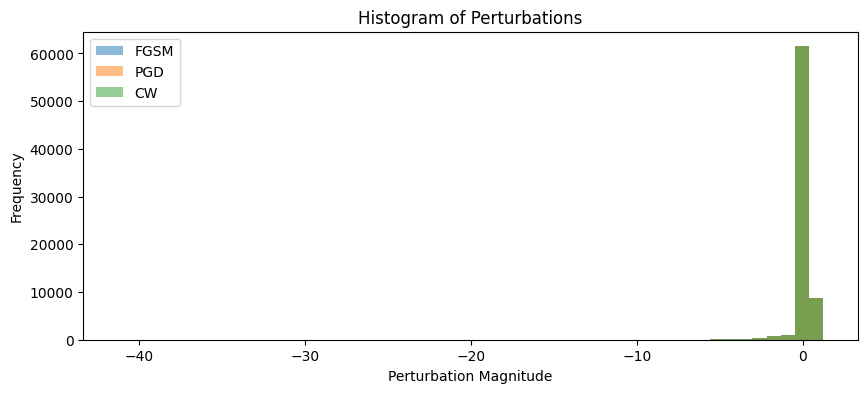

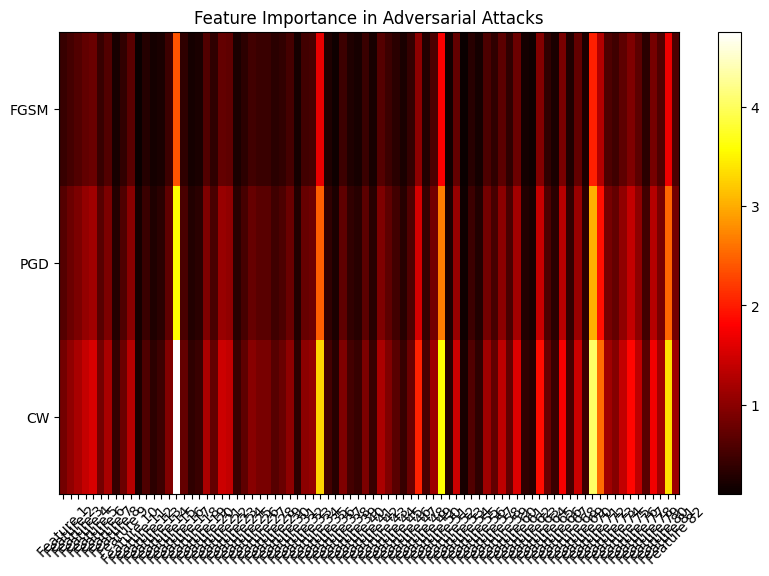

Accuracy under FGSM attack (ε=0.01): 0.86
Accuracy under PGD attack (ε=0.01, α=0.01, iters=10): 0.86
Accuracy under CW attack: 0.86


(0.858902575587906, 0.8577827547592385, 0.8577827547592385)

In [ ]:
def evaluate_attacks(model, test_loader, eps, alpha, iters, device):
    model.eval()
    all_preds_fgsm, all_preds_pgd, all_preds_cw = [], [], []
    all_targets = []
    all_perturbations_fgsm, all_perturbations_pgd, all_perturbations_cw = [], [], []
    feature_importance_fgsm = np.zeros_like(test_loader.dataset[0][0])
    feature_importance_pgd = np.zeros_like(test_loader.dataset[0][0])
    feature_importance_cw = np.zeros_like(test_loader.dataset[0][0])

    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # FGSM Attack
        adv_fgsm = fgsm_attack(model, X_batch, y_batch, eps)
        outputs_fgsm = model(adv_fgsm)
        _, preds_fgsm = outputs_fgsm.max(1)
        all_preds_fgsm.extend(preds_fgsm.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

        # Perturbations for FGSM
        perturbations_fgsm = (adv_fgsm - X_batch).detach().cpu().numpy()
        all_perturbations_fgsm.extend(perturbations_fgsm.flatten())

        # Feature importance for FGSM
        X_batch.requires_grad = True
        outputs = model(X_batch)
        loss = nn.CrossEntropyLoss()(outputs, y_batch)
        model.zero_grad()
        loss.backward()
        feature_importance_fgsm += torch.abs(X_batch.grad).sum(dim=0).cpu().numpy()

        # PGD Attack
        adv_pgd = pgd_attack(model, X_batch, y_batch, eps, alpha, iters)
        outputs_pgd = model(adv_pgd)
        _, preds_pgd = outputs_pgd.max(1)
        all_preds_pgd.extend(preds_pgd.cpu().numpy())

        # Perturbations for PGD
        perturbations_pgd = (adv_pgd - X_batch).detach().cpu().numpy()
        all_perturbations_pgd.extend(perturbations_pgd.flatten())

        # Feature importance for PGD
        X_batch.requires_grad = True
        outputs = model(X_batch)
        loss = nn.CrossEntropyLoss()(outputs, y_batch)
        model.zero_grad()
        loss.backward()
        feature_importance_pgd += torch.abs(X_batch.grad).sum(dim=0).cpu().numpy()

        # CW Attack
        adv_cw = cw_attack(model, X_batch, y_batch, c=1e-4, lr=0.01, max_iters=iters)
        outputs_cw = model(adv_cw)
        _, preds_cw = outputs_cw.max(1)
        all_preds_cw.extend(preds_cw.cpu().numpy())

        # Perturbations for CW
        perturbations_cw = (adv_cw - X_batch).detach().cpu().numpy()
        all_perturbations_cw.extend(perturbations_cw.flatten())

        # Feature importance for CW
        X_batch.requires_grad = True
        outputs = model(X_batch)
        loss = nn.CrossEntropyLoss()(outputs, y_batch)
        model.zero_grad()
        loss.backward()
        feature_importance_cw += torch.abs(X_batch.grad).sum(dim=0).cpu().numpy()

    # Calculate accuracy
    acc_fgsm = accuracy_score(all_targets, all_preds_fgsm)
    acc_pgd = accuracy_score(all_targets, all_preds_pgd)
    acc_cw = accuracy_score(all_targets, all_preds_cw)

    # Visualizations
    # Perturbation Histograms
    plt.figure(figsize=(10, 4))
    plt.hist(all_perturbations_fgsm, bins=50, alpha=0.5, label='FGSM')
    plt.hist(all_perturbations_pgd, bins=50, alpha=0.5, label='PGD')
    plt.hist(all_perturbations_cw, bins=50, alpha=0.5, label='CW')
    plt.xlabel('Perturbation Magnitude')
    plt.ylabel('Frequency')
    plt.title('Histogram of Perturbations')
    plt.legend()
    plt.show()

    # Heatmap: Feature Importance
    feature_names = [f'Feature {i+1}' for i in range(len(feature_importance_fgsm))]
    plt.figure(figsize=(10, 6))
    feature_matrix = np.vstack([feature_importance_fgsm, feature_importance_pgd, feature_importance_cw])
    plt.imshow(feature_matrix, cmap='hot', interpolation='nearest', aspect='auto')
    plt.xticks(np.arange(len(feature_names)), feature_names, rotation=45)
    plt.yticks(np.arange(3), ['FGSM', 'PGD', 'CW'])
    plt.colorbar()
    plt.title('Feature Importance in Adversarial Attacks')
    plt.show()

    # Print results
    print(f"Accuracy under FGSM attack (ε={eps}): {acc_fgsm:.2f}")
    print(f"Accuracy under PGD attack (ε={eps}, α={alpha}, iters={iters}): {acc_pgd:.2f}")
    print(f"Accuracy under CW attack: {acc_cw:.2f}")

    return acc_fgsm, acc_pgd, acc_cw
evaluate_attacks(model, test_loader, 0.01, alpha, iters, device)


#### epsilon

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gy


Retrained Model Performance on Combined Features:
Accuracy: 0.9305750350631136


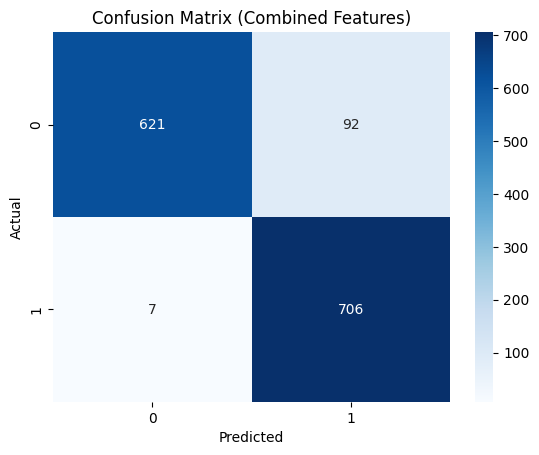

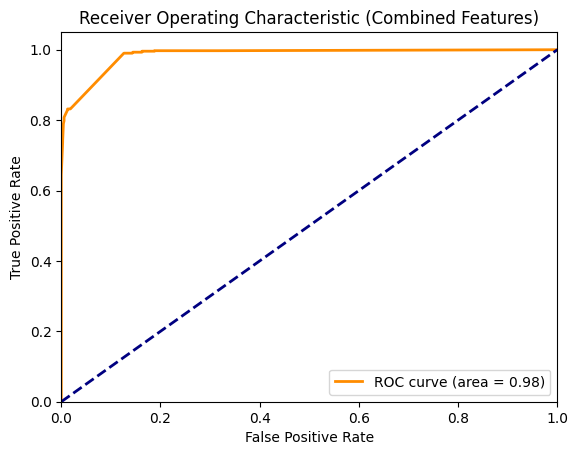

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.8653576437587658


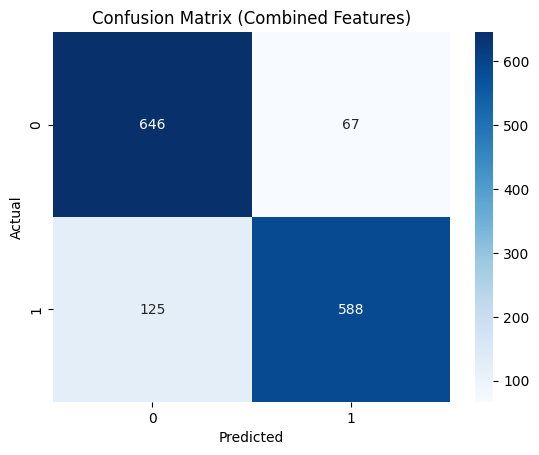

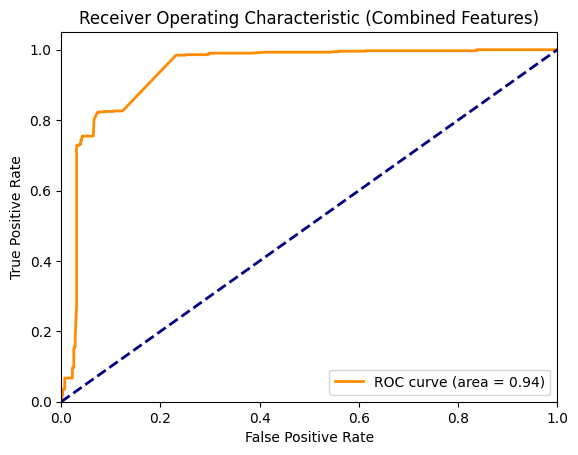

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.8779803646563815


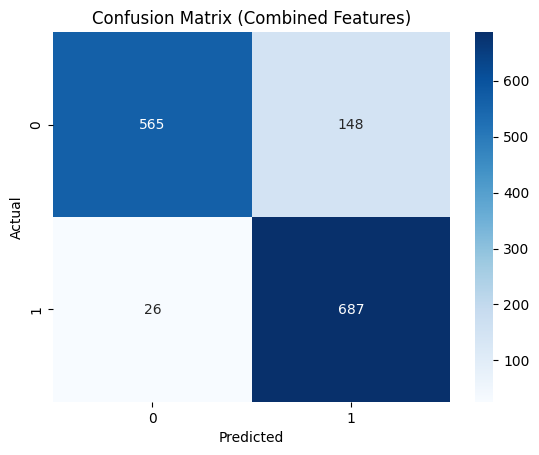

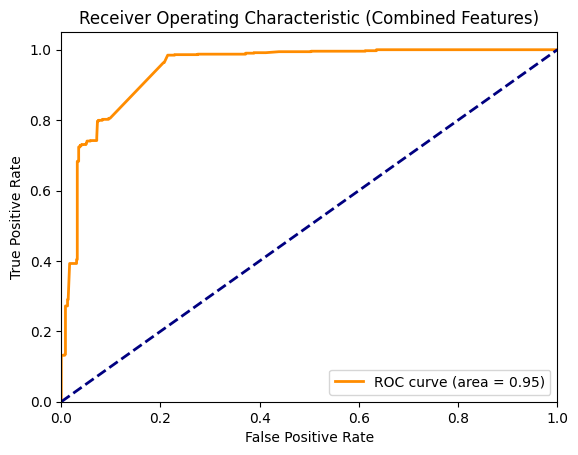

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)

# Preprocessing
logging.info("Preprocessing data...")
assert 'Label' in data.columns, "The 'Label' column is missing in the dataset."
assert set(permission_features).issubset(data.columns), "Some permission features are missing."
assert set(api_features).issubset(data.columns), "Some API features are missing."

# Remove under-represented classes
class_counts = data['Label'].value_counts()
if class_counts.min() < 2:
    logging.warning("Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

# Encode labels
label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Combine and scale features
X_combined = data[permission_features + api_features]
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

# Split into subsets for permissions and APIs
X_permissions_scaled = X_combined_scaled[:, :len(permission_features)]
X_apis_scaled = X_combined_scaled[:, len(permission_features):]

# Resampling with SMOTE
smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)
logging.info("SMOTE resampling completed.")

# Train-test split
X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] + self.epsilon * action
        feature_min = np.min(self.X_train, axis=0)
        feature_max = np.max(self.X_train, axis=0)
        perturbed_sample = np.clip(perturbed_sample, feature_min, feature_max)

        probs = self.model.predict_proba([perturbed_sample])[0]
        reward = max(probs) - probs[self.y_train[self.current_idx]]
        predicted_class = self.model.predict([perturbed_sample])[0]
        success = predicted_class != self.y_train[self.current_idx]

        done = True
        return perturbed_sample, reward, done, {}

# Generate adversarial samples and retrain
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    logging.info(f"Training model with {feature_set} features...")
    model.fit(X_train, y_train)

    # Adversarial training
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)
    logging.info("Adversarial agent training completed.")

    # Generate adversarial samples
    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train, perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])
    model.fit(X_augmented, y_augmented)

    # Evaluate model
    y_pred = model.predict(X_test)
    print(f"\nRetrained Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"confusion_matrix_{feature_set}.png")
    plt.show()
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability of positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic ({feature_set} Features)')
    plt.legend(loc="lower right")
    plt.savefig(f"roc_curve_{feature_set}.png")
    plt.show()

# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train and evaluate models with combined features
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)

# Preprocessing
#logging.info("Preprocessing data...")
assert 'Label' in data.columns, "The 'Label' column is missing in the dataset."
assert set(permission_features).issubset(data.columns), "Some permission features are missing."
assert set(api_features).issubset(data.columns), "Some API features are missing."

# Remove under-represented classes
class_counts = data['Label'].value_counts()
if class_counts.min() < 2:
    logging.warning("Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

# Encode labels
label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Combine and scale features
X_combined = data[permission_features + api_features]
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

# Split into subsets for permissions and APIs
X_permissions_scaled = X_combined_scaled[:, :len(permission_features)]
X_apis_scaled = X_combined_scaled[:, len(permission_features):]

# Resampling with SMOTE
smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)
logging.info("SMOTE resampling completed.")

# Train-test split
X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] + self.epsilon * action
        feature_min = np.min(self.X_train, axis=0)
        feature_max = np.max(self.X_train, axis=0)
        perturbed_sample = np.clip(perturbed_sample, feature_min, feature_max)

        probs = self.model.predict_proba([perturbed_sample])[0]
        reward = max(probs) - probs[self.y_train[self.current_idx]]
        predicted_class = self.model.predict([perturbed_sample])[0]
        success = predicted_class != self.y_train[self.current_idx]

        done = True
        return perturbed_sample, reward, done, {}

# Generate adversarial samples and retrain
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    logging.info(f"Training model with {feature_set} features...")
    model.fit(X_train, y_train)

    # Adversarial training
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)
    logging.info("Adversarial agent training completed.")

    # Generate adversarial samples
    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train, perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])
    model.fit(X_augmented, y_augmented)

    # Evaluate model
    y_pred = model.predict(X_test)
    print(f"\nRetrained Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"confusion_matrix_{feature_set}.png")
    plt.show()
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability of positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic ({feature_set} Features)')
    plt.legend(loc="lower right")
    plt.savefig(f"roc_curve_{feature_set}.png")
    plt.show()

# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train and evaluate models with combined features
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Accuracy: 0.5131061598951507


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Accuracy: 0.5006553079947575


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


...

Accuracy: 0.5150720838794234


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Accuracy: 0.49737876802096986


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Accuracy: 0.5052424639580603


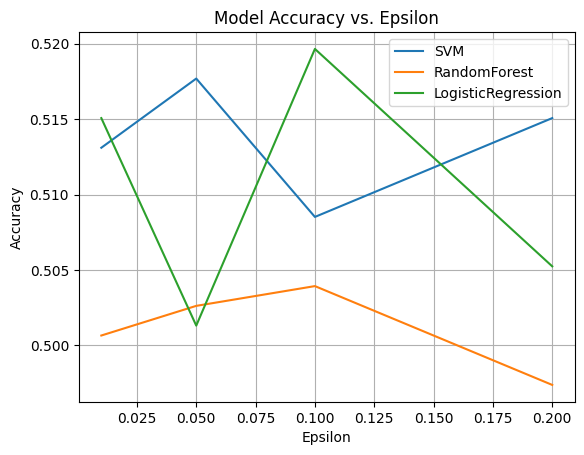

In [ ]:
epsilons = [0.01, 0.05, 0.1, 0.2]
models = {
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000)
}

results = {}

for epsilon in epsilons:
    results[epsilon] = {}
    for model_name, model in models.items():
        #logging.info(f"Evaluating {model_name} with epsilon={epsilon}...")
        model.fit(X_train_combined, y_train)
        env = AdversarialEnv(model, X_train_combined, y_train, epsilon=epsilon)
        adversarial_agent = PPO("MlpPolicy", env, verbose=0)
        adversarial_agent.learn(total_timesteps=5000)

        # Generate adversarial samples and retrain
        perturbations = []
        for _ in range(100):
            obs = env.reset()
            action, _ = adversarial_agent.predict(obs)
            perturbations.append(obs + action)

        X_augmented = np.vstack([X_train_combined, perturbations])
        y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])
        # Create augmented test data using the same perturbations
        X_test_subset = X_test.iloc[:, :X_train_combined.shape[1]]
        X_augmented_test = np.vstack([X_test_subset, perturbations])
        y_augmented_test = np.hstack([y_test, np.random.choice(y_test, size=len(perturbations))])

        # Retrain the model with augmented data
        model.fit(X_augmented, y_augmented)

        # Predict on augmented test data
        y_pred = model.predict(X_augmented_test)
        feature_set="Combined"
        acc = accuracy_score(y_augmented_test, y_pred) # Calculate accuracy
        results[epsilon][model_name] = acc # Store accuracy in results

        print("Accuracy:", acc) # Print accuracy
        sns.heatmap(confusion_matrix(y_augmented_test, y_pred), annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix ({feature_set} Features)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.close()

# Plot accuracy vs. epsilon
for model_name in models.keys():
    accs = [results[epsilon][model_name] for epsilon in epsilons]
    plt.plot(epsilons, accs, label=model_name)

plt.title("Model Accuracy vs. Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_vs_epsilon.png")
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validatio


Retrained Model Performance on Combined Features:
Accuracy: 0.9319775596072931


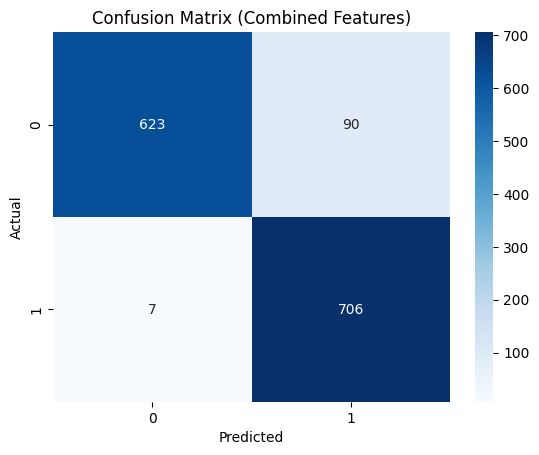

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.8688639551192145


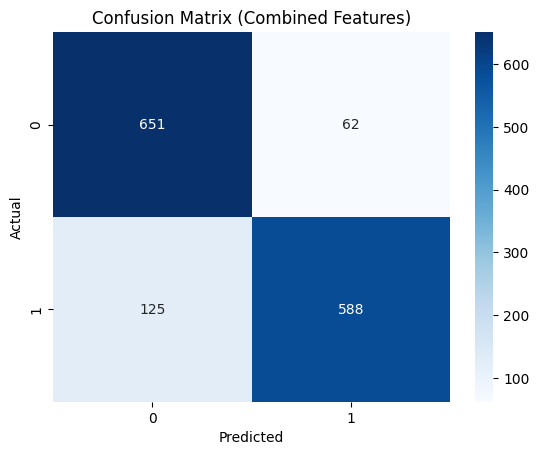

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.8583450210378681


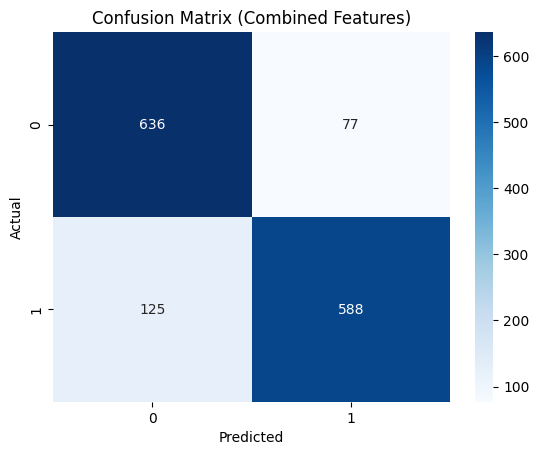

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8892005610098177


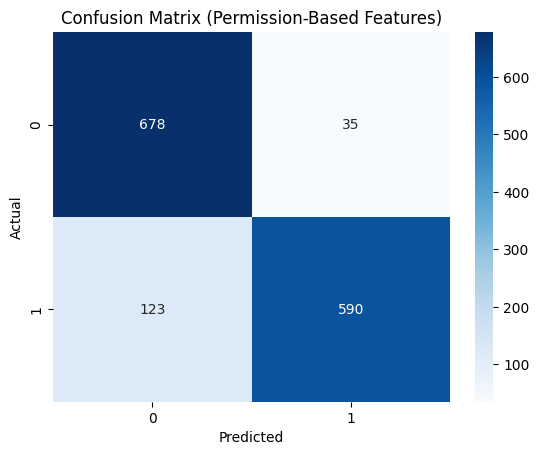

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8316970546984572


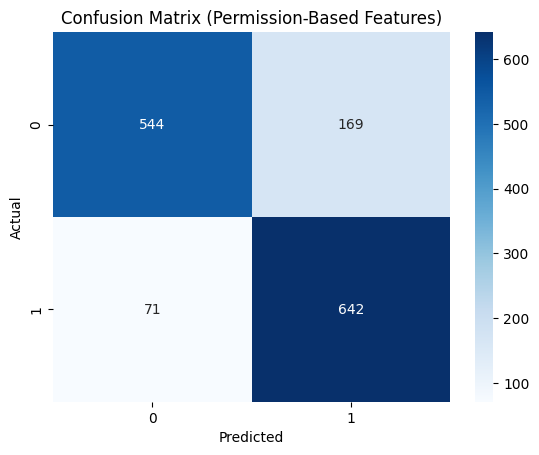

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8064516129032258


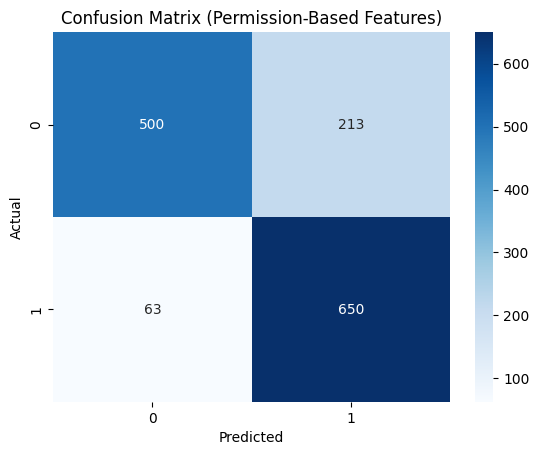

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.8506311360448808


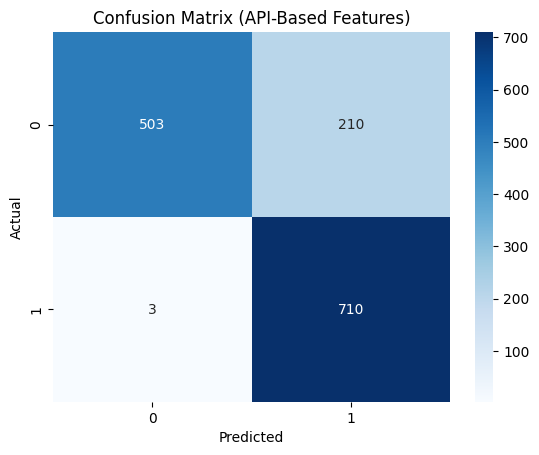

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.800140252454418


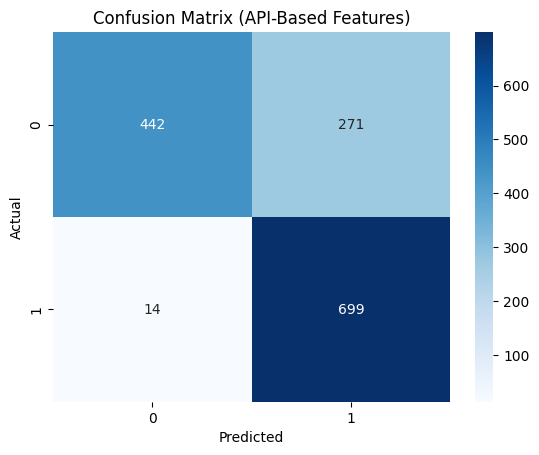

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.8141654978962132


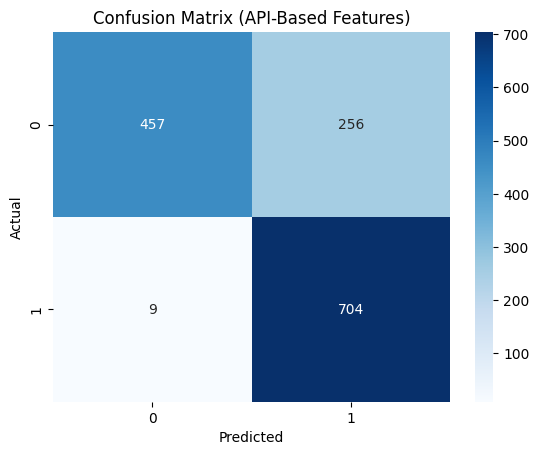

In [ ]:
#final
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO

# Preprocessing and feature extraction
class_counts = data['Label'].value_counts()
min_class_count = class_counts.min()
if min_class_count < 2:
    print("Warning: Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Separate features
X_permissions = data[permission_features]
X_apis = data[api_features]
X_combined = data[permission_features + api_features]

scaler = StandardScaler()
X_permissions_scaled = scaler.fit_transform(X_permissions)
X_apis_scaled = scaler.fit_transform(X_apis)
X_combined_scaled = scaler.fit_transform(X_combined)

smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)

X_permissions_resampled, _ = smote.fit_resample(X_permissions_scaled, y_encoded)
X_apis_resampled, _ = smote.fit_resample(X_apis_scaled, y_encoded)

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

X_train_permissions, X_test_permissions = train_test_split(
    X_permissions_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

X_train_apis, X_test_apis = train_test_split(
    X_apis_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.current_index = 0
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] +self.epsilon * action
        perturbed_sample = np.clip(perturbed_sample, 0, 1)
        prob = self.model.predict_proba([perturbed_sample])[0]
        #success = pred != self.y[self.current_index]
        predicted_class = self.model.predict([perturbed_sample])[0]
        # Compare predicted class to actual class
        success = predicted_class != self.y_train[self.current_idx]
        reward = 1 if success else -1  # Higher uncertainty = better reward
        done = True
        return perturbed_sample, reward, done, {}

# Generate adversarial samples and retrain for each feature type
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train, perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])

    model.fit(X_augmented, y_augmented)

    y_pred = model.predict(X_test)
    print(f"\nRetrained Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Combined Features
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")

# Permission-Based Features
generate_adversarial_and_retrain(rf_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")
generate_adversarial_and_retrain(svm_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")
generate_adversarial_and_retrain(lr_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")

# API-Based Features
generate_adversarial_and_retrain(rf_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")
generate_adversarial_and_retrain(svm_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")
generate_adversarial_and_retrain(lr_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validatio


Retrained Model Performance on Combined Features:
Accuracy: 0.7563891178895301


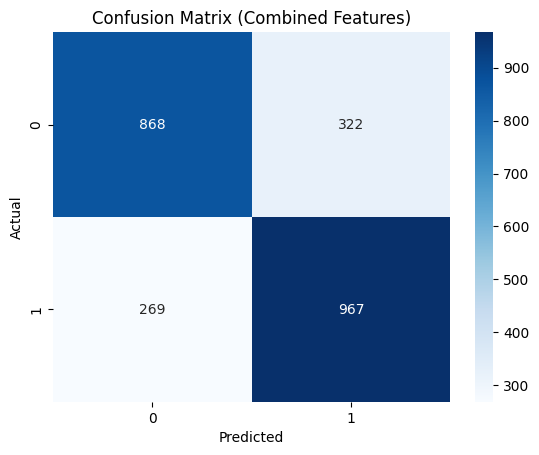

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.7077493816982687


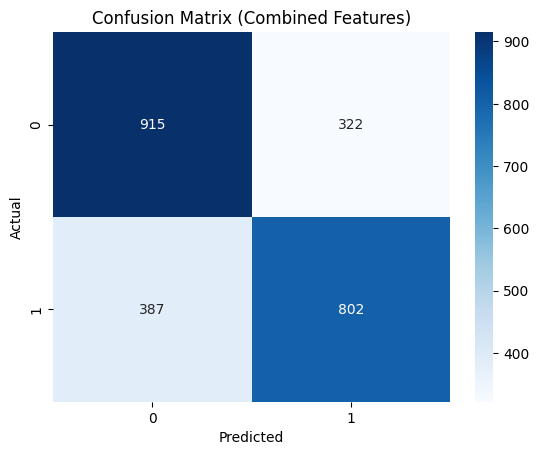

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.7052761747732894


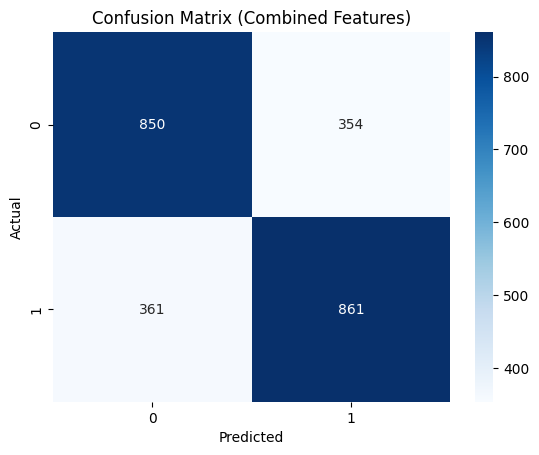

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.7258862324814509


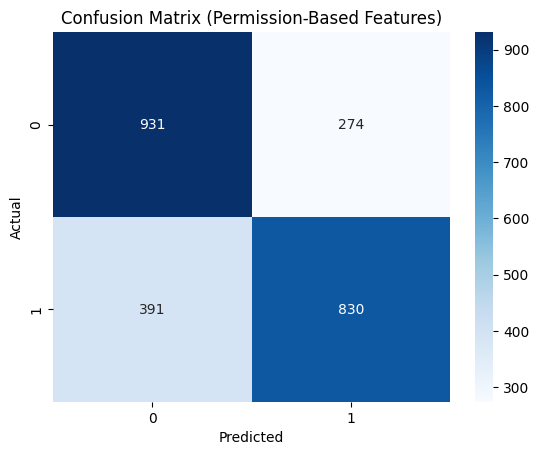

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.6793075020610058


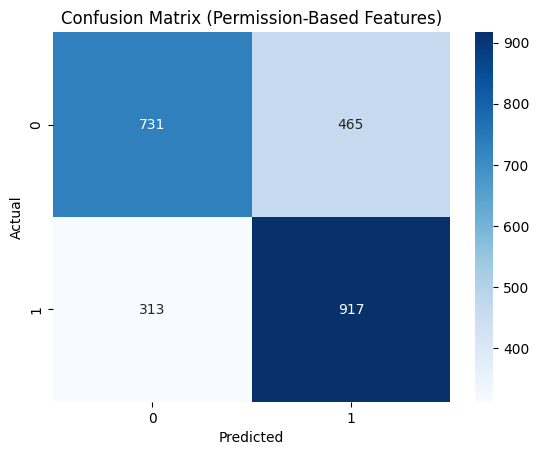

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.6698268755152514


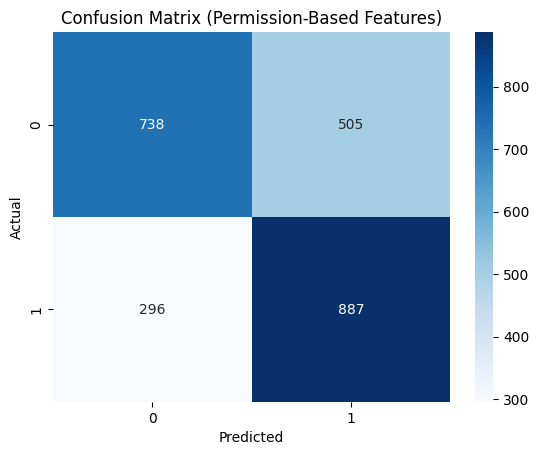

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.7139323990107173


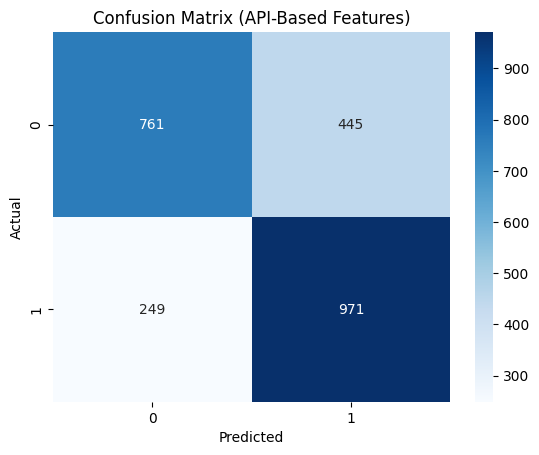

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.6702390766694146


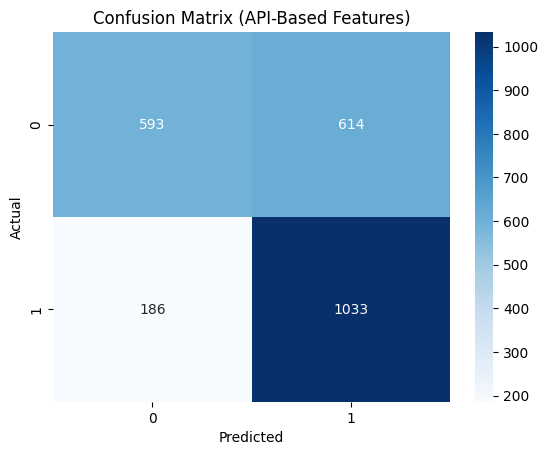

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.6854905193734543


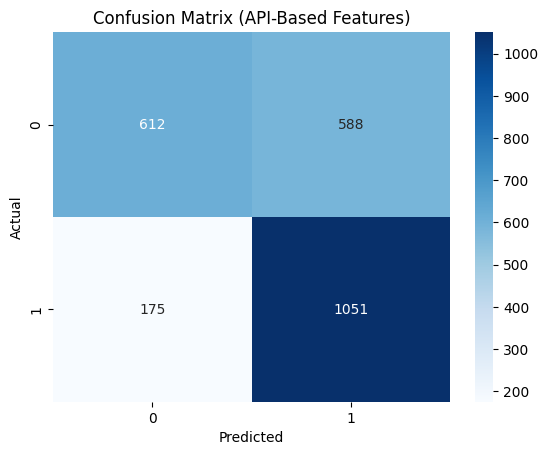

In [ ]:
#final
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO

# Preprocessing and feature extraction
class_counts = data['Label'].value_counts()
min_class_count = class_counts.min()
if min_class_count < 2:
    print("Warning: Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Separate features
X_permissions = data[permission_features]
X_apis = data[api_features]
X_combined = data[permission_features + api_features]

scaler = StandardScaler()
X_permissions_scaled = scaler.fit_transform(X_permissions)
X_apis_scaled = scaler.fit_transform(X_apis)
X_combined_scaled = scaler.fit_transform(X_combined)

smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)

X_permissions_resampled, _ = smote.fit_resample(X_permissions_scaled, y_encoded)
X_apis_resampled, _ = smote.fit_resample(X_apis_scaled, y_encoded)

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

X_train_permissions, X_test_permissions = train_test_split(
    X_permissions_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

X_train_apis, X_test_apis = train_test_split(
    X_apis_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.current_index = 0
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] +self.epsilon * action
        perturbed_sample = np.clip(perturbed_sample, 0, 1)
        prob = self.model.predict_proba([perturbed_sample])[0]
        #success = pred != self.y[self.current_index]
        predicted_class = self.model.predict([perturbed_sample])[0]
        # Compare predicted class to actual class
        success = predicted_class != self.y_train[self.current_idx]
        reward = 1 if success else -1  # Higher uncertainty = better reward
        done = True
        return perturbed_sample, reward, done, {}

# Generate adversarial samples and retrain for each feature type
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train, perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])
    # Create augmented test data using the same perturbations
    X_augmented_test = np.vstack([X_test, perturbations])
    y_augmented_test = np.hstack([y_test, np.random.choice(y_test, size=len(perturbations))])

    # Retrain the model with augmented data
    model.fit(X_augmented, y_augmented)

    # Predict on augmented test data
    y_pred = model.predict(X_augmented_test)
    print(f"\nRetrained Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_augmented_test, y_pred))
    sns.heatmap(confusion_matrix(y_augmented_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Combined Features
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")

# Permission-Based Features
generate_adversarial_and_retrain(rf_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")
generate_adversarial_and_retrain(svm_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")
generate_adversarial_and_retrain(lr_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")

# API-Based Features
generate_adversarial_and_retrain(rf_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")
generate_adversarial_and_retrain(svm_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")
generate_adversarial_and_retrain(lr_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validatio


Retrained Model Performance on Combined Features:
Accuracy: 0.7361912613355317


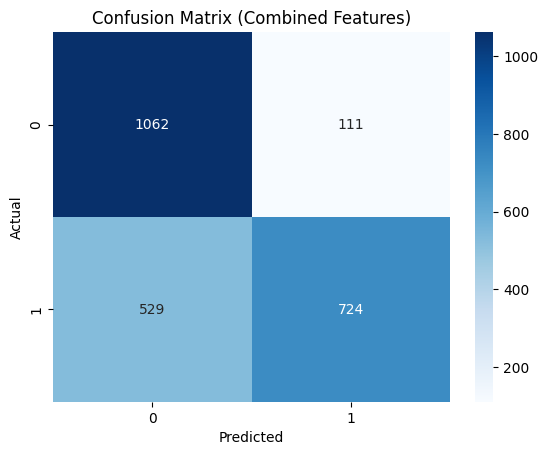

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.7246496290189612


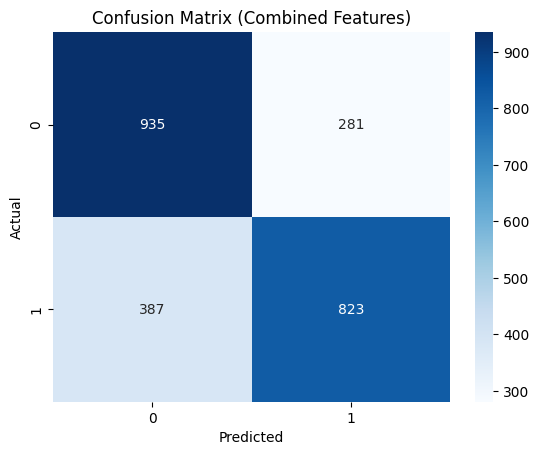

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Combined Features:
Accuracy: 0.7217642209398186


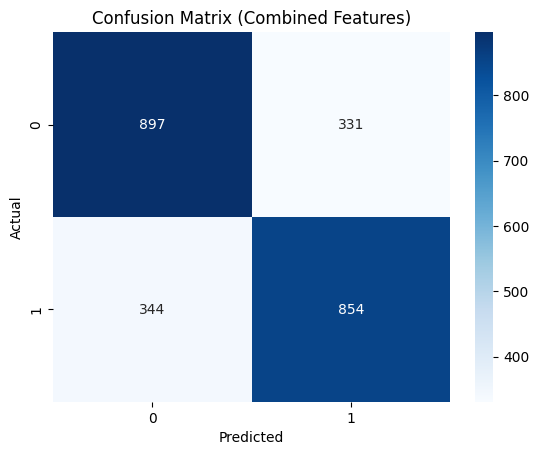

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.7361912613355317


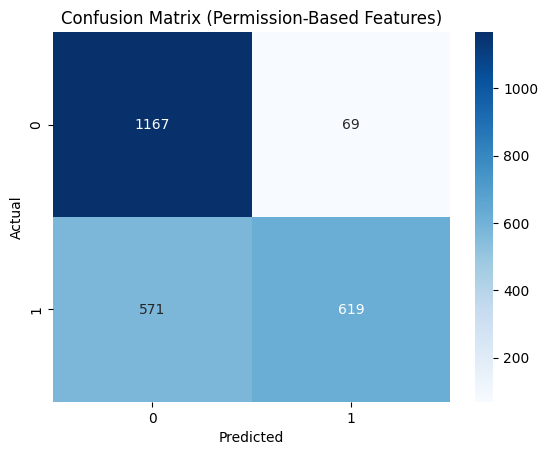

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.708161582852432


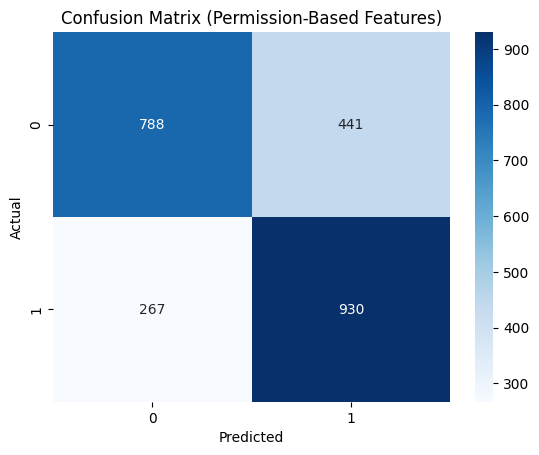

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on Permission-Based Features:
Accuracy: 0.6776586974443528


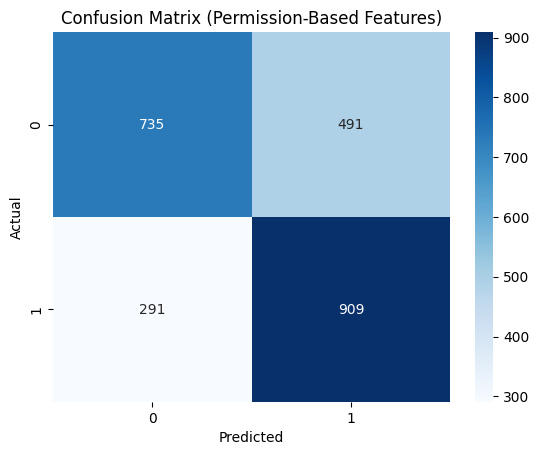

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.7048639736191261


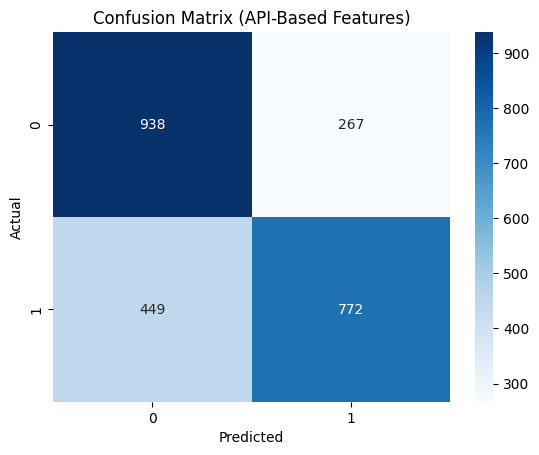

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.6776586974443528


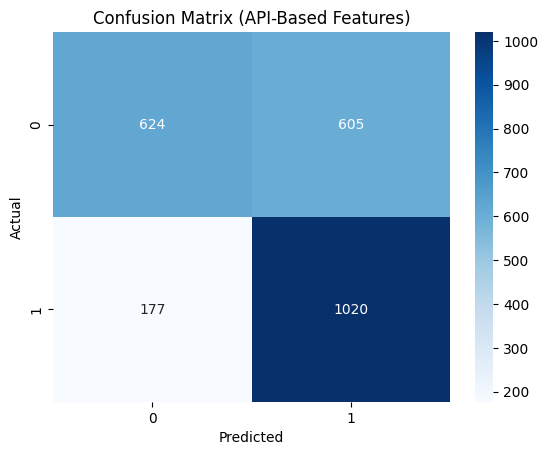

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



Retrained Model Performance on API-Based Features:
Accuracy: 0.686727122835944


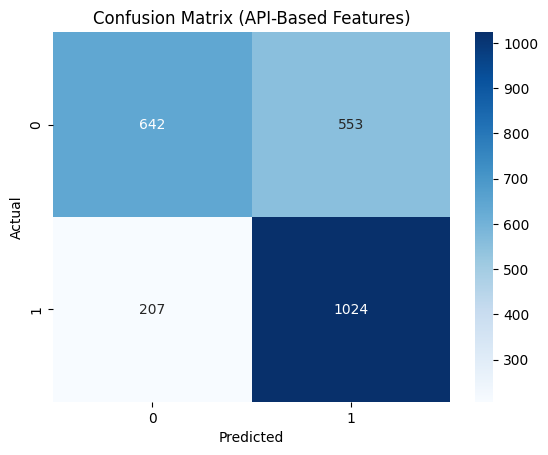

In [ ]:
#final
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO

# Preprocessing and feature extraction
class_counts = data['Label'].value_counts()
min_class_count = class_counts.min()
if min_class_count < 2:
    print("Warning: Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Separate features
X_permissions = data[permission_features]
X_apis = data[api_features]
X_combined = data[permission_features + api_features]

scaler = StandardScaler()
X_permissions_scaled = scaler.fit_transform(X_permissions)
X_apis_scaled = scaler.fit_transform(X_apis)
X_combined_scaled = scaler.fit_transform(X_combined)

smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)

X_permissions_resampled, _ = smote.fit_resample(X_permissions_scaled, y_encoded)
X_apis_resampled, _ = smote.fit_resample(X_apis_scaled, y_encoded)

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

X_train_permissions, X_test_permissions = train_test_split(
    X_permissions_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

X_train_apis, X_test_apis = train_test_split(
    X_apis_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.current_index = 0
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] +self.epsilon * action
        perturbed_sample = np.clip(perturbed_sample, 0, 1)
        prob = self.model.predict_proba([perturbed_sample])[0]
        #success = pred != self.y[self.current_index]
        predicted_class = self.model.predict([perturbed_sample])[0]
        # Compare predicted class to actual class
        success = predicted_class != self.y_train[self.current_idx]
        reward = 1 if success else -1  # Higher uncertainty = better reward
        done = True
        return perturbed_sample, reward, done, {}

# Generate adversarial samples and retrain for each feature type
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train, perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])
    # Create augmented test data using the same perturbations
    X_augmented_test = np.vstack([X_test, perturbations])
    y_augmented_test = np.hstack([y_test, np.random.choice(y_test, size=len(perturbations))])

    # Retrain the model with augmented data
    #model.fit(X_augmented, y_augmented)

    # Predict on augmented test data
    y_pred = model.predict(X_augmented_test)
    print(f"\nRetrained Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_augmented_test, y_pred))
    sns.heatmap(confusion_matrix(y_augmented_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Combined Features
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")

# Permission-Based Features
generate_adversarial_and_retrain(rf_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")
generate_adversarial_and_retrain(svm_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")
generate_adversarial_and_retrain(lr_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based")

# API-Based Features
generate_adversarial_and_retrain(rf_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")
generate_adversarial_and_retrain(svm_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")
generate_adversarial_and_retrain(lr_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based")


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


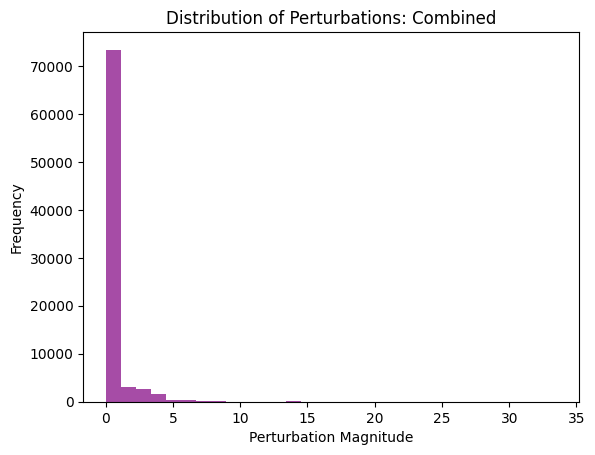


Retrained Model Performance on Combined Features:
Accuracy: 0.9319775596072931


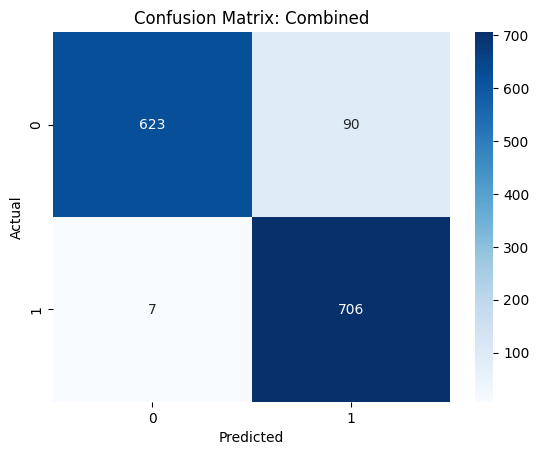

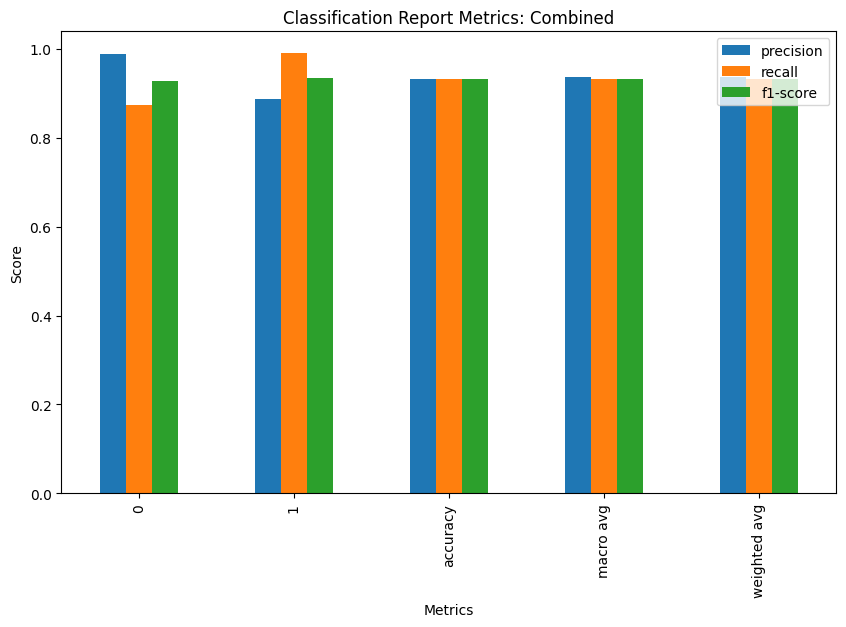

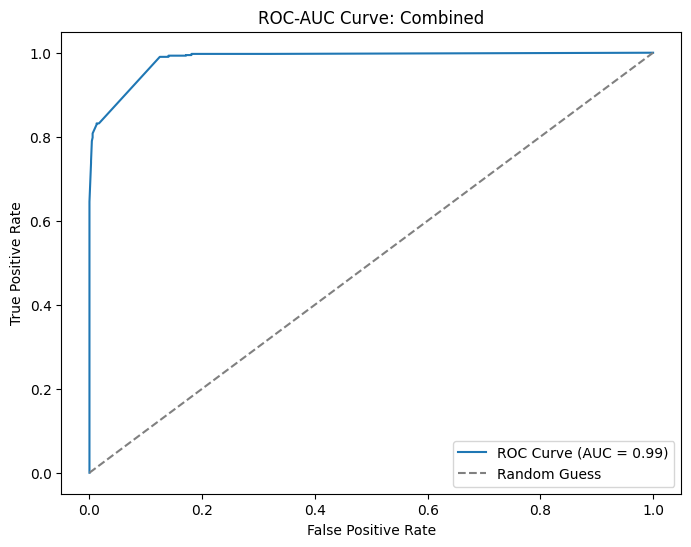

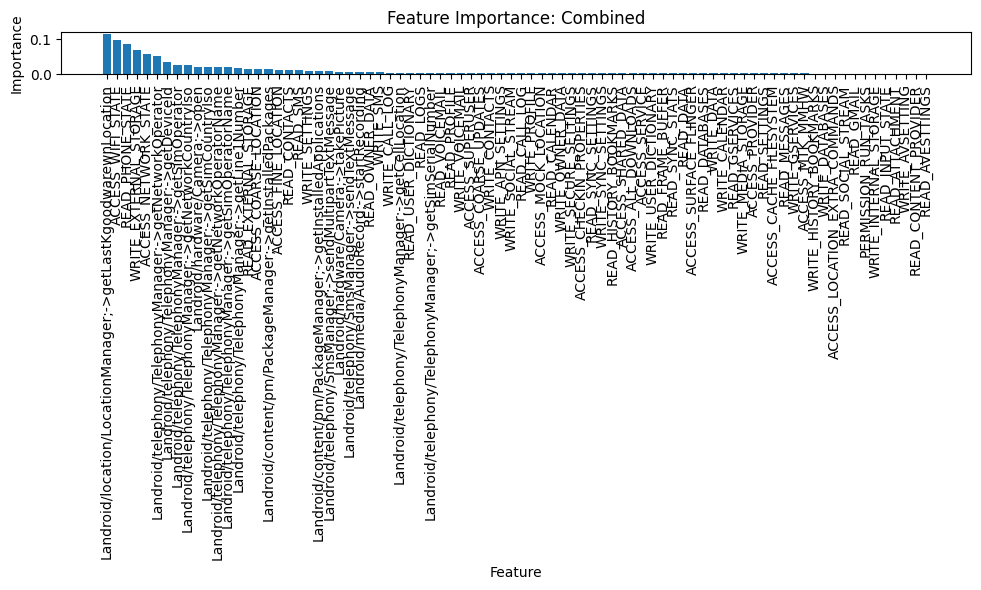

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


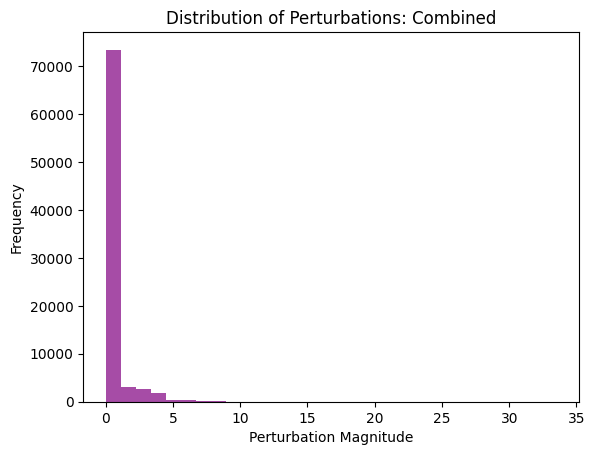


Retrained Model Performance on Combined Features:
Accuracy: 0.8625525946704067


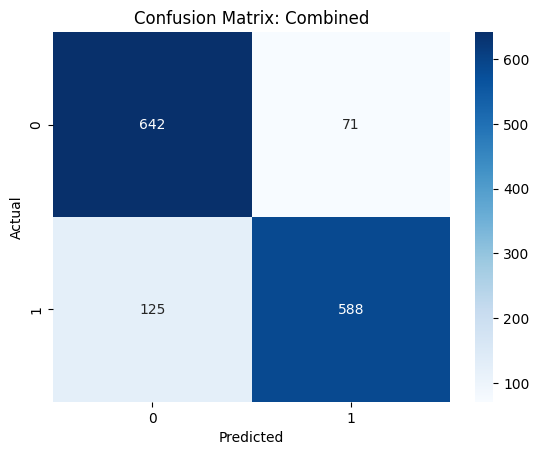

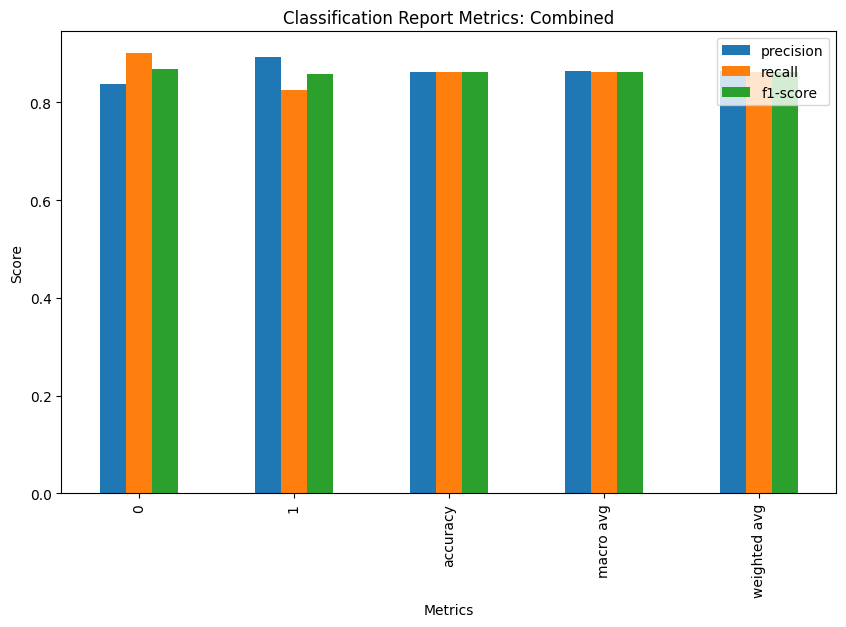

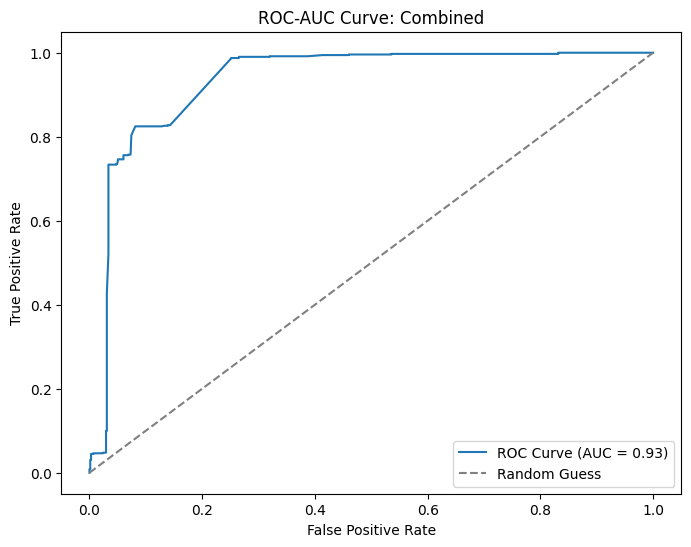

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


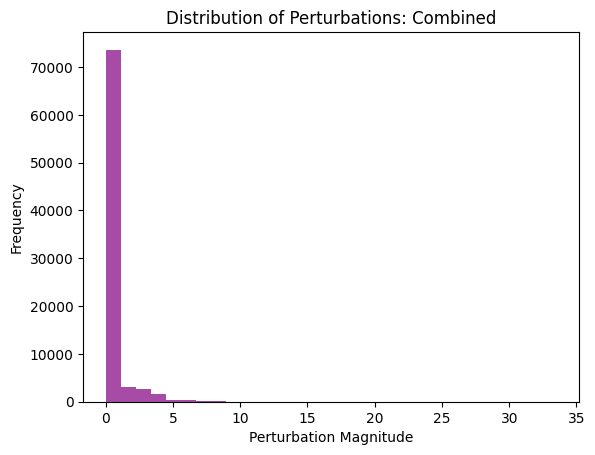


Retrained Model Performance on Combined Features:
Accuracy: 0.8639551192145862


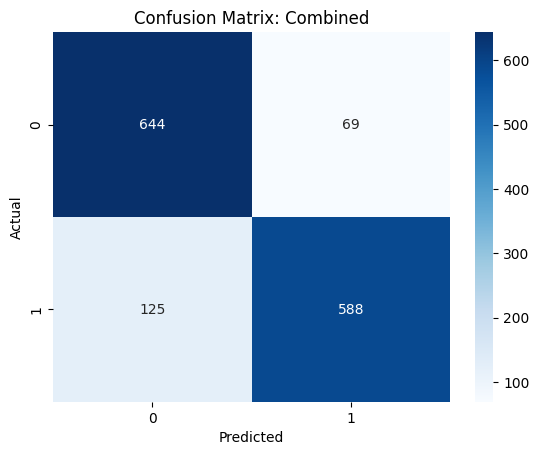

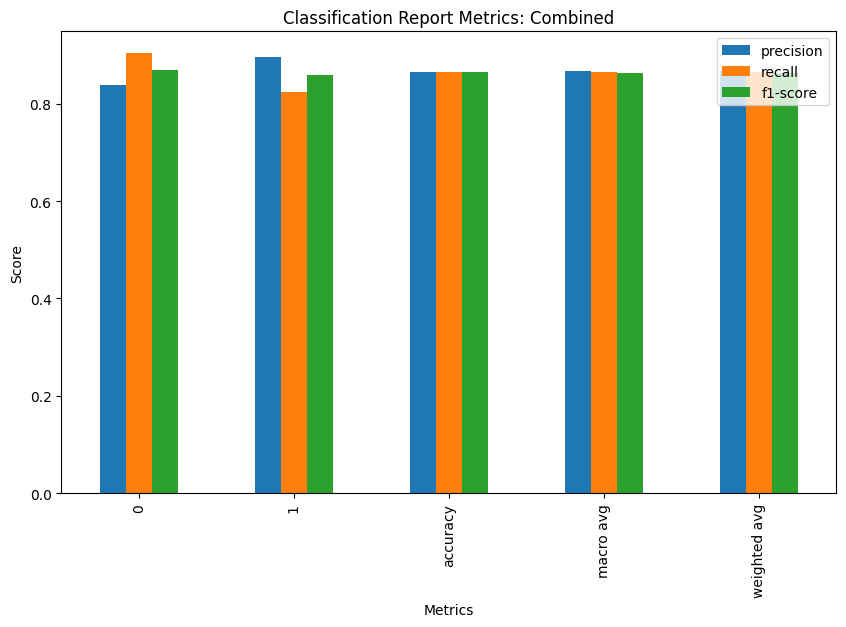

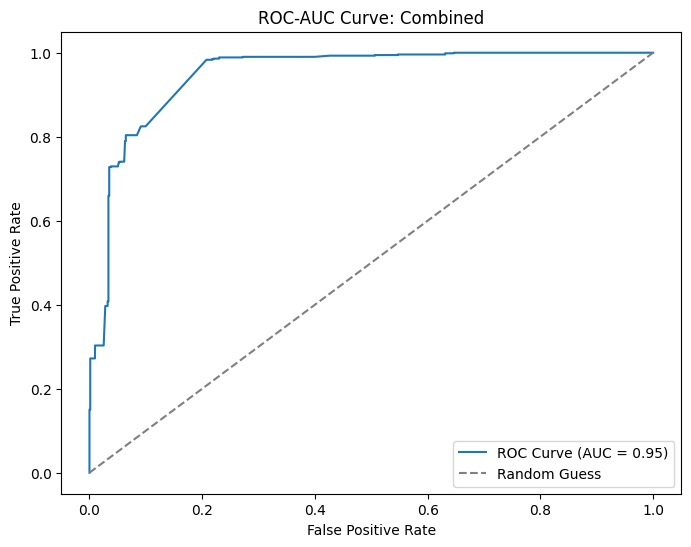

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


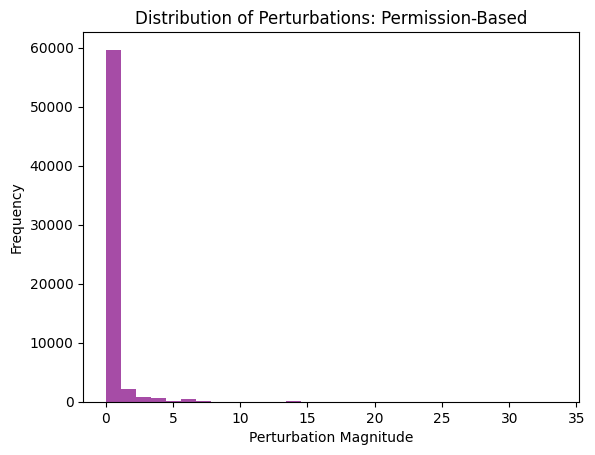


Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8892005610098177


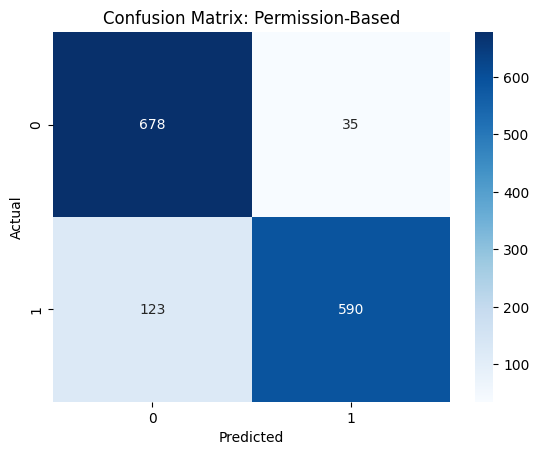

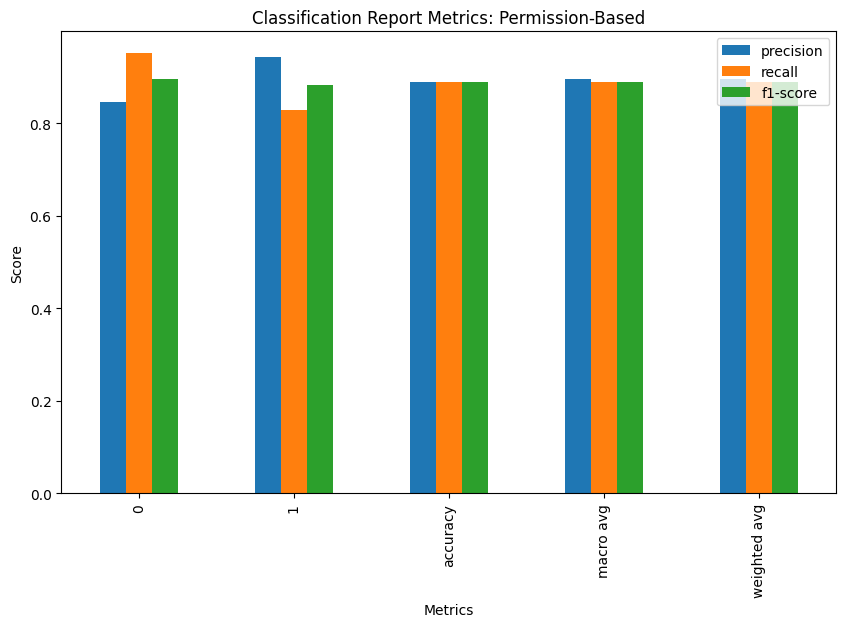

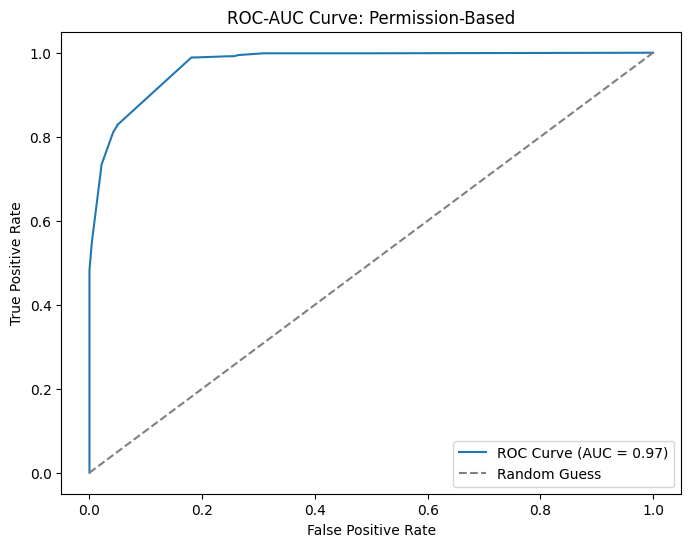

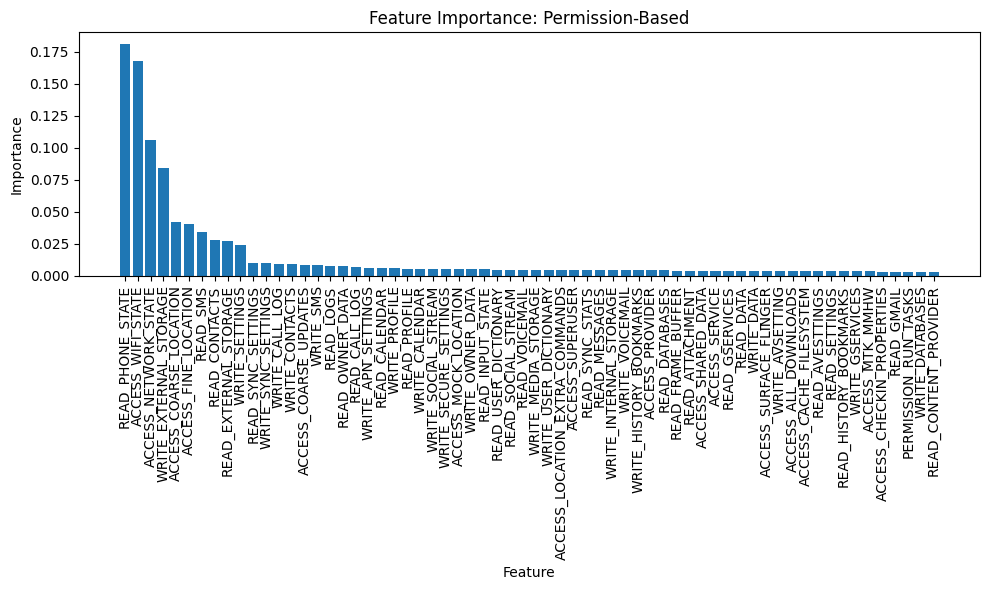

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


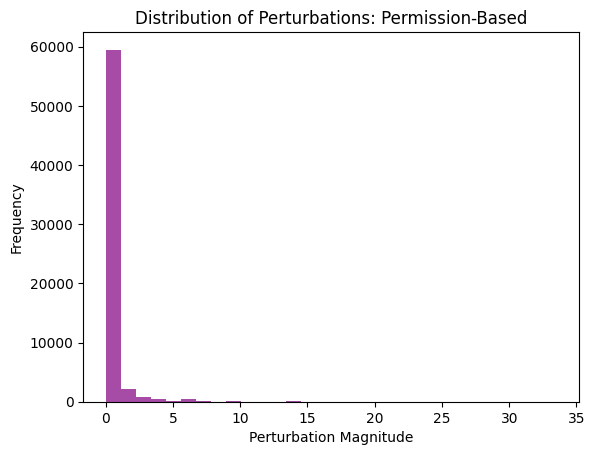


Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8302945301542777


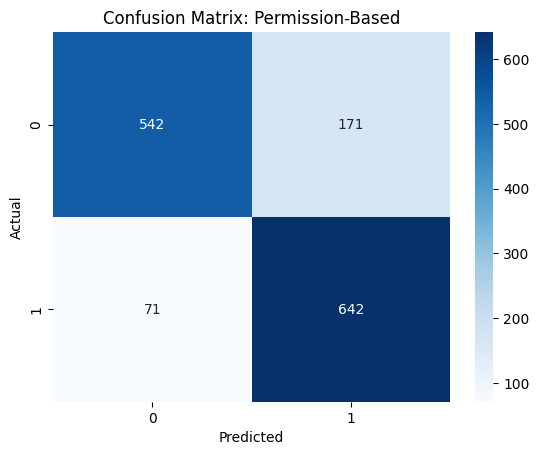

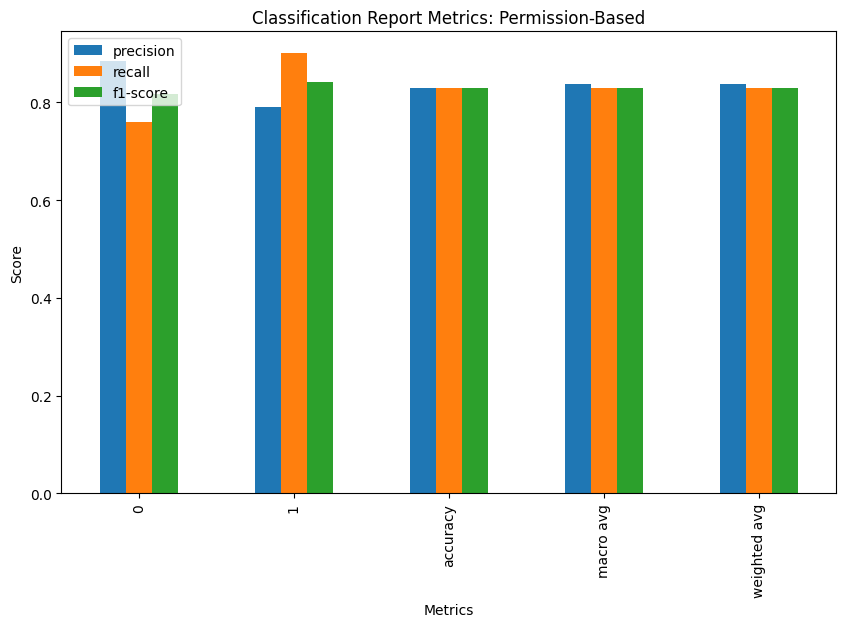

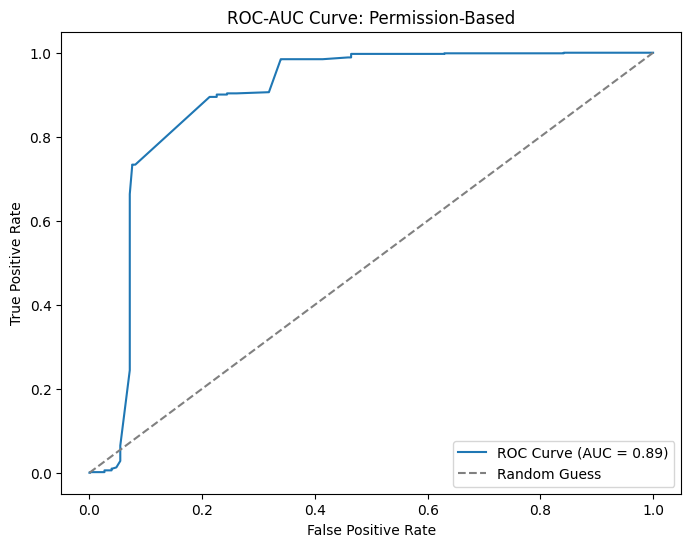

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


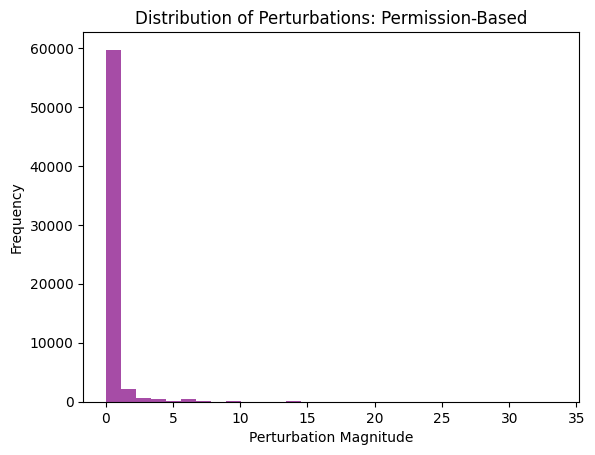


Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8043478260869565


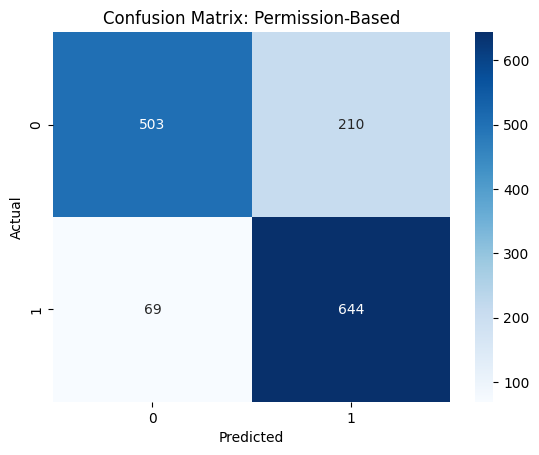

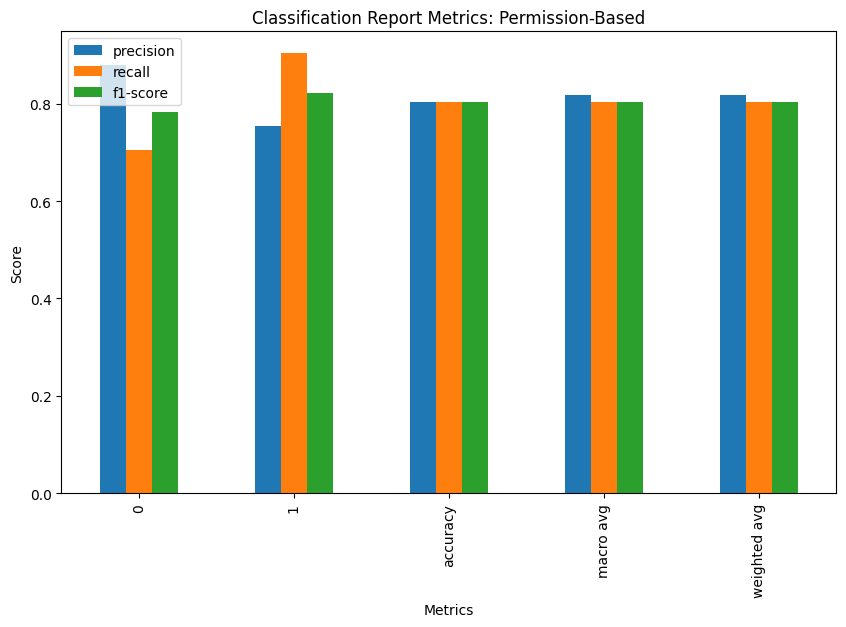

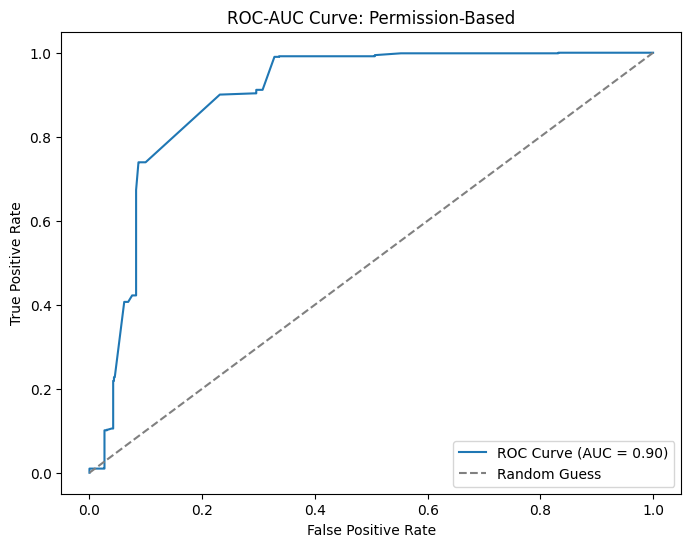

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


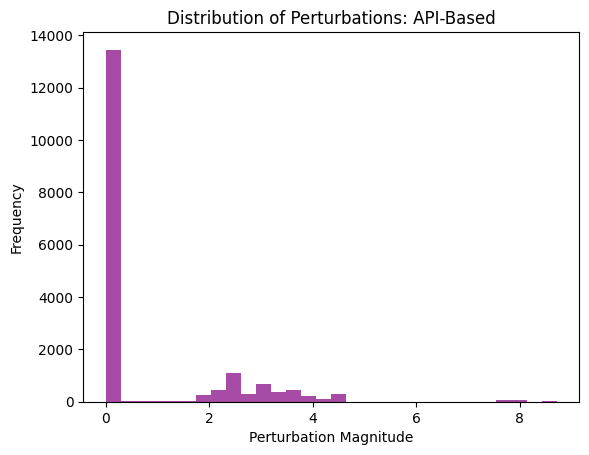


Retrained Model Performance on API-Based Features:
Accuracy: 0.8506311360448808


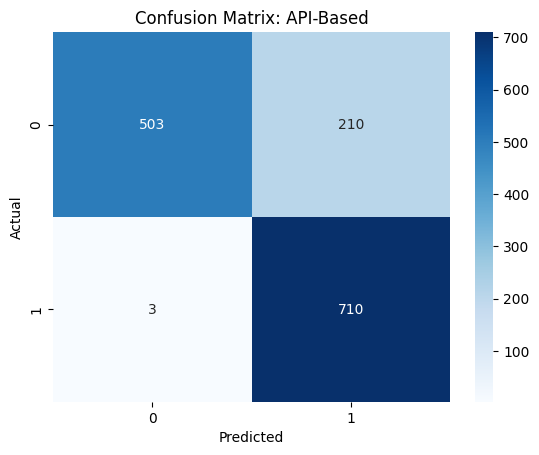

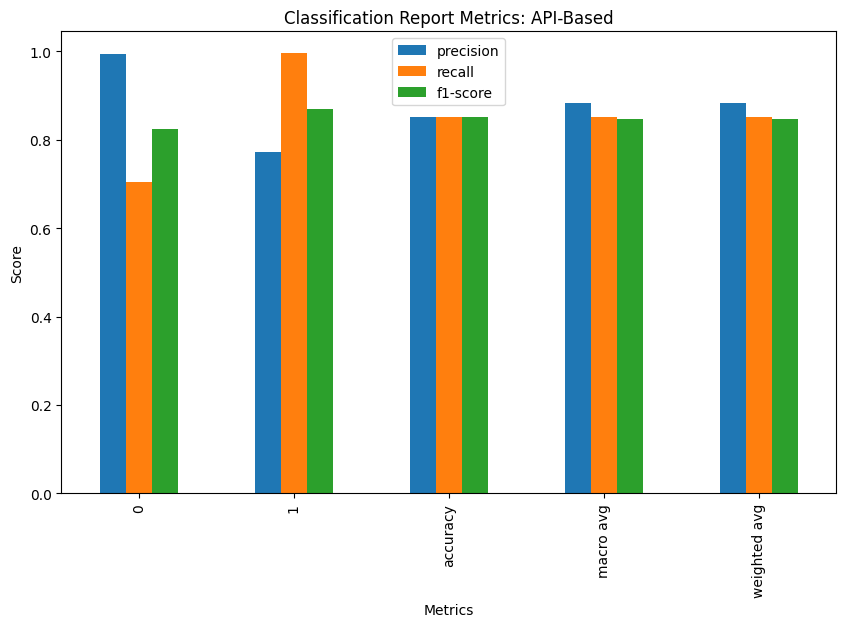

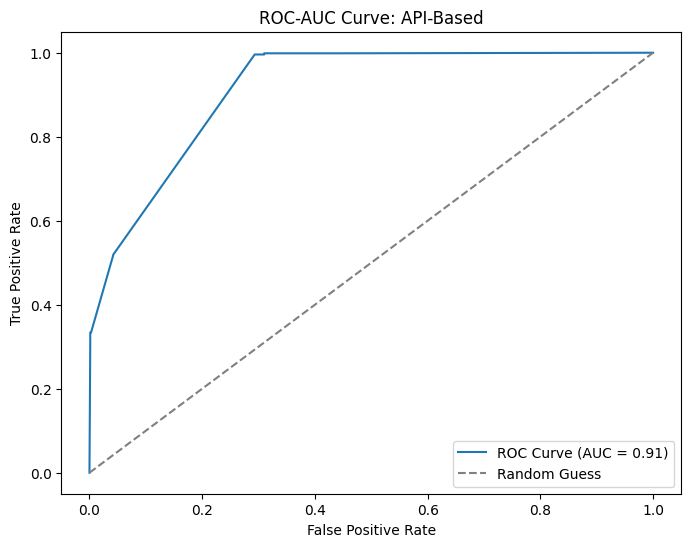

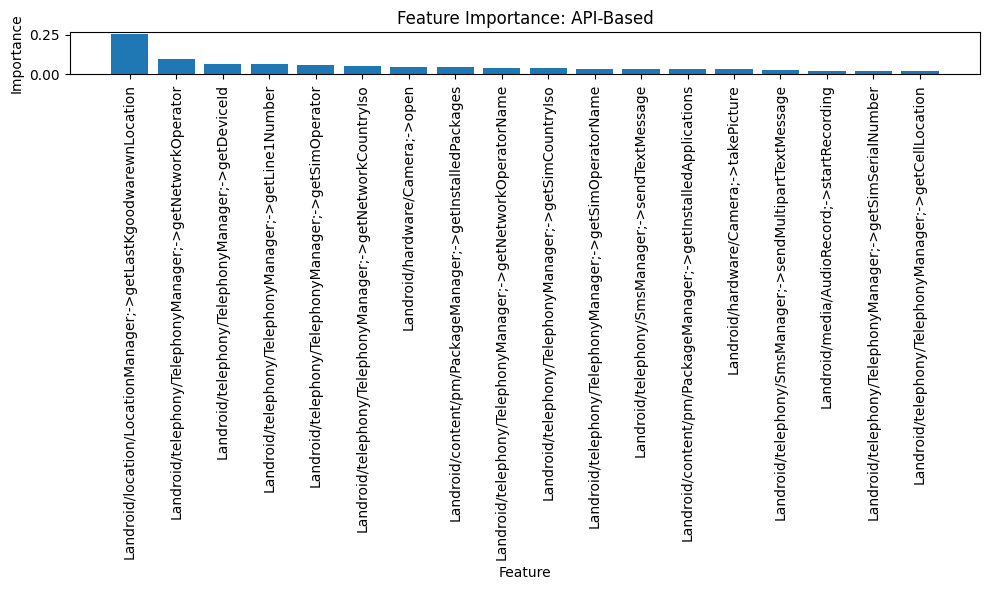

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


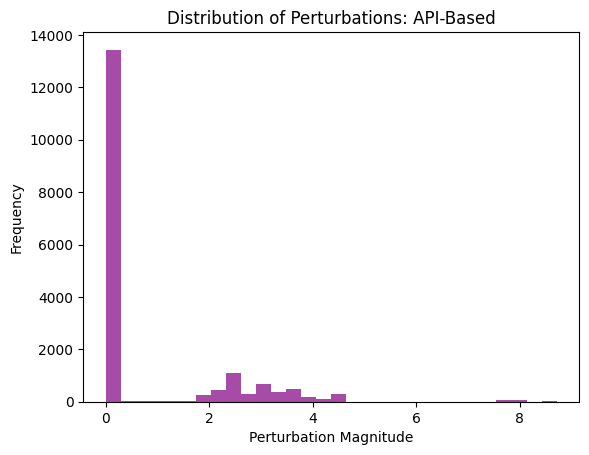


Retrained Model Performance on API-Based Features:
Accuracy: 0.8050490883590463


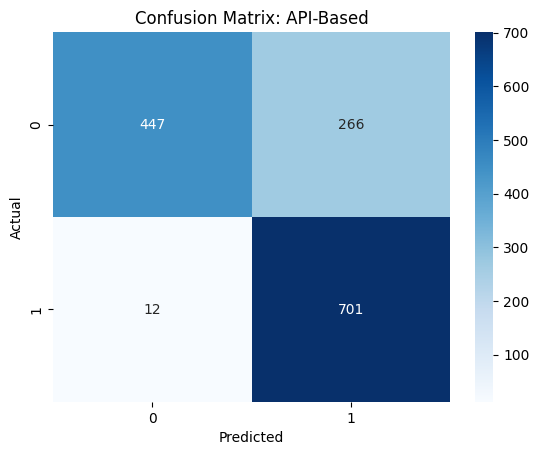

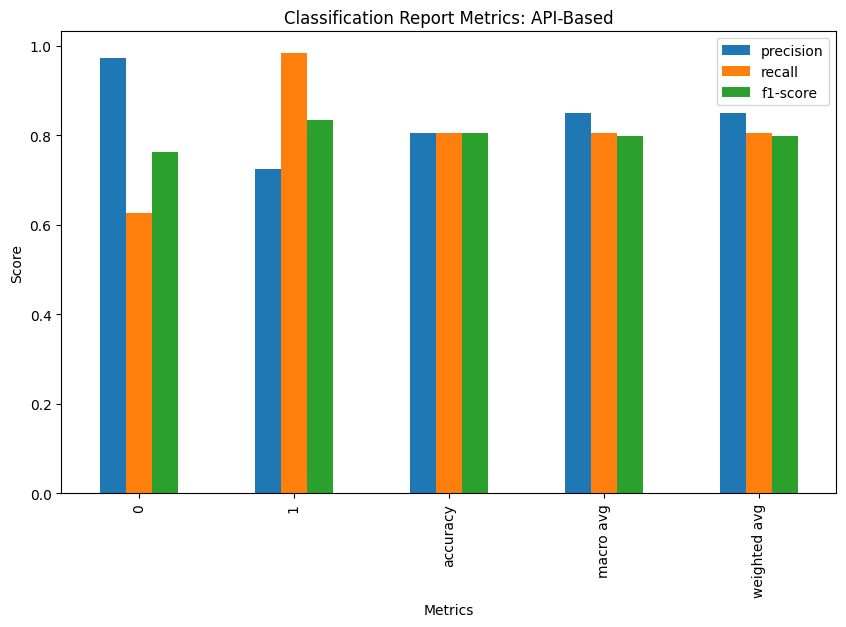

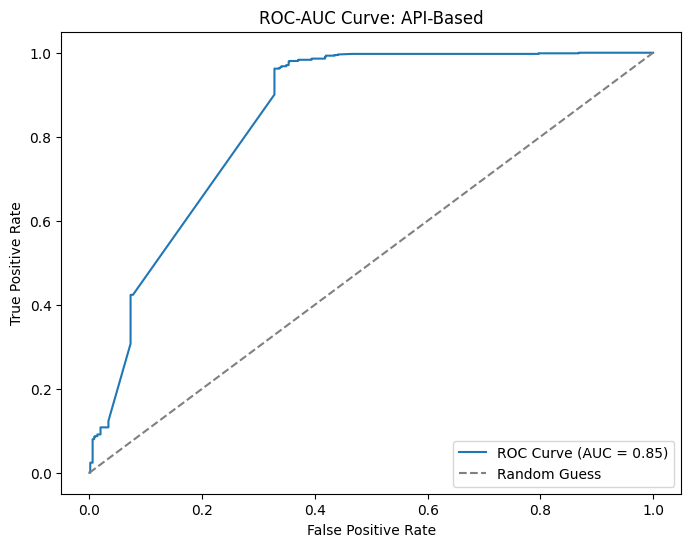

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


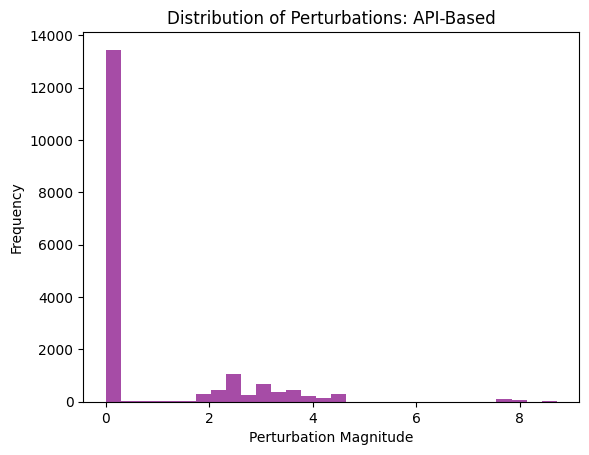


Retrained Model Performance on API-Based Features:
Accuracy: 0.8106591865357644


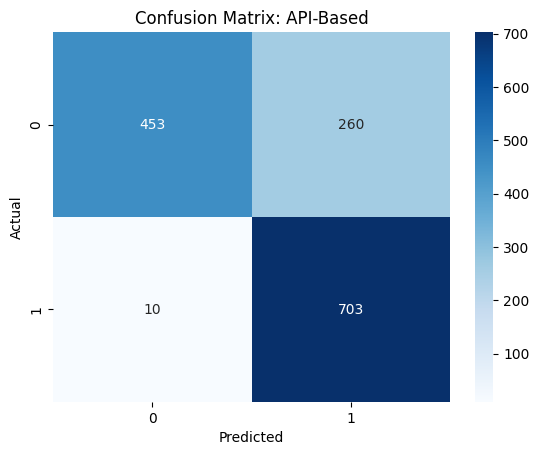

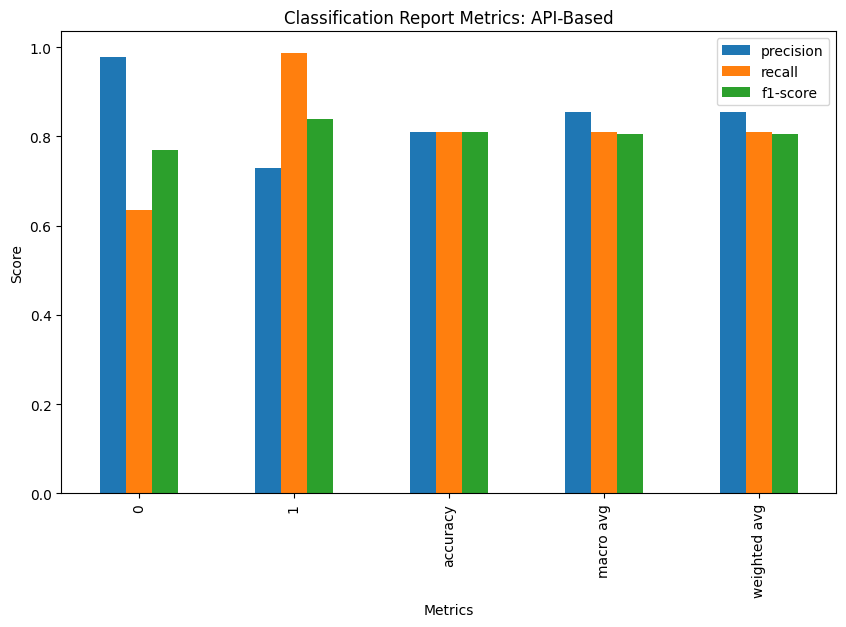

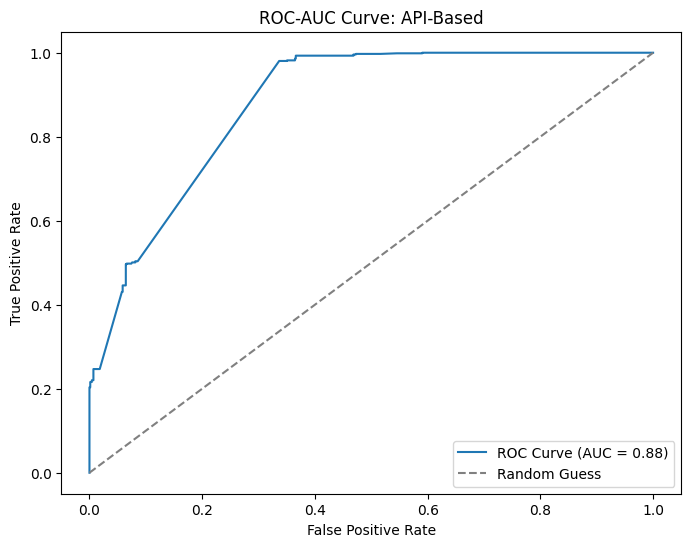

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc,
    precision_recall_fscore_support
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO

# Function for plotting performance metrics
def plot_metrics(y_test, y_pred, y_pred_proba, title):
    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.drop("support", axis=1).plot(kind="bar", figsize=(10, 6))
    plt.title(f"Classification Report Metrics: {title}")
    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.show()

    # ROC-AUC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.2f})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random Guess")
    plt.title(f"ROC-AUC Curve: {title}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Function for plotting adversarial perturbations
def plot_perturbations(original_samples, perturbed_samples, title):
    original_samples_subset = original_samples[np.random.choice(original_samples.shape[0], size=perturbed_samples.shape[0], replace=False)]

    perturbations = np.abs(perturbed_samples - original_samples_subset)  # Calculate perturbations for the subset
    plt.hist(perturbations.flatten(), bins=30, color='purple', alpha=0.7)
    plt.title(f"Distribution of Perturbations: {title}")
    plt.xlabel("Perturbation Magnitude")
    plt.ylabel("Frequency")
    plt.show()

# Function for feature importance (Random Forest only)
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.bar(range(len(importances)), importances[indices], align="center")
        plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
        plt.title(f"Feature Importance: {title}")
        plt.xlabel("Feature")
        plt.ylabel("Importance")
        plt.tight_layout()
        plt.show()

# Generate adversarial samples and retrain for each feature type
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set, feature_names):
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    perturbed_samples = np.array(perturbations)
    plot_perturbations(X_train, perturbed_samples, feature_set)

    X_augmented = np.vstack([X_train, perturbed_samples])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbed_samples))])

    model.fit(X_augmented, y_augmented)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    print(f"\nRetrained Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # Plot Metrics
    plot_metrics(y_test, y_pred, y_pred_proba, feature_set)

    # Feature Importance
    plot_feature_importance(model, feature_names, feature_set)

# Apply the updated code for each feature set and model
# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Combined Features
combined_features = permission_features + api_features
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined", combined_features)
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined", combined_features)
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined", combined_features)

# Permission-Based Features
generate_adversarial_and_retrain(rf_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based", permission_features)
generate_adversarial_and_retrain(svm_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based", permission_features)
generate_adversarial_and_retrain(lr_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based", permission_features)

# API-Based Features
generate_adversarial_and_retrain(rf_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based", api_features)
generate_adversarial_and_retrain(svm_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based", api_features)
generate_adversarial_and_retrain(lr_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based", api_features)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


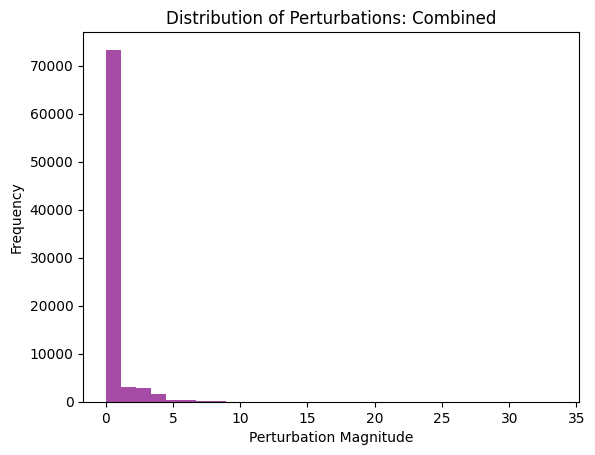


Retrained Model Performance on Combined Features:
Accuracy: 0.9298737727910238


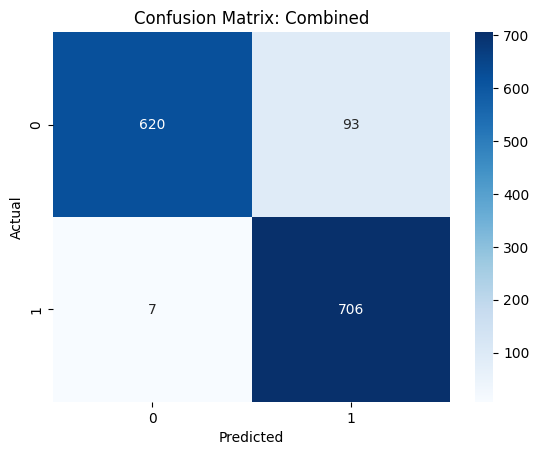

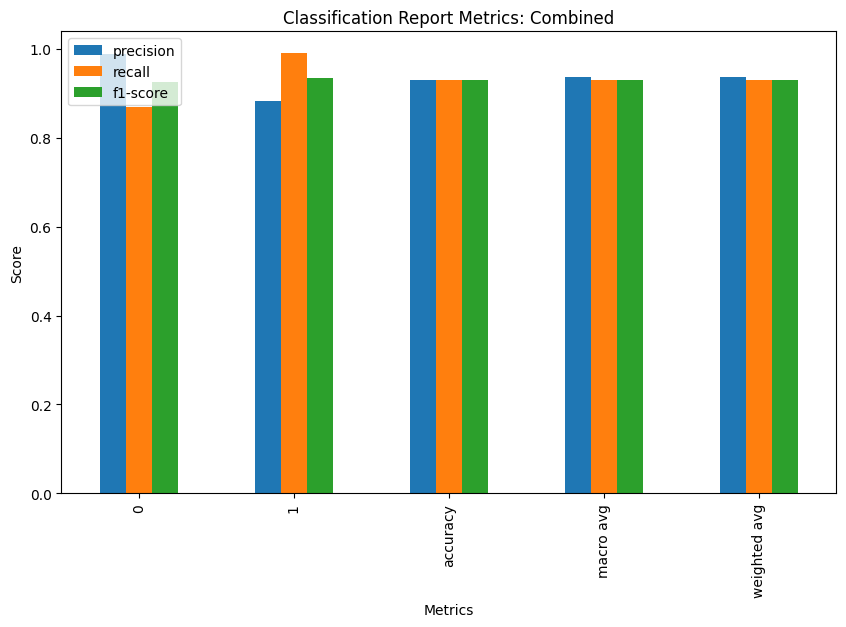

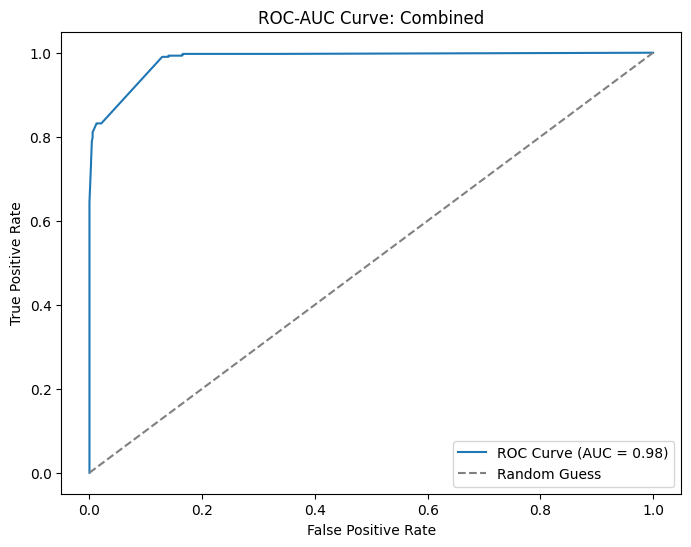

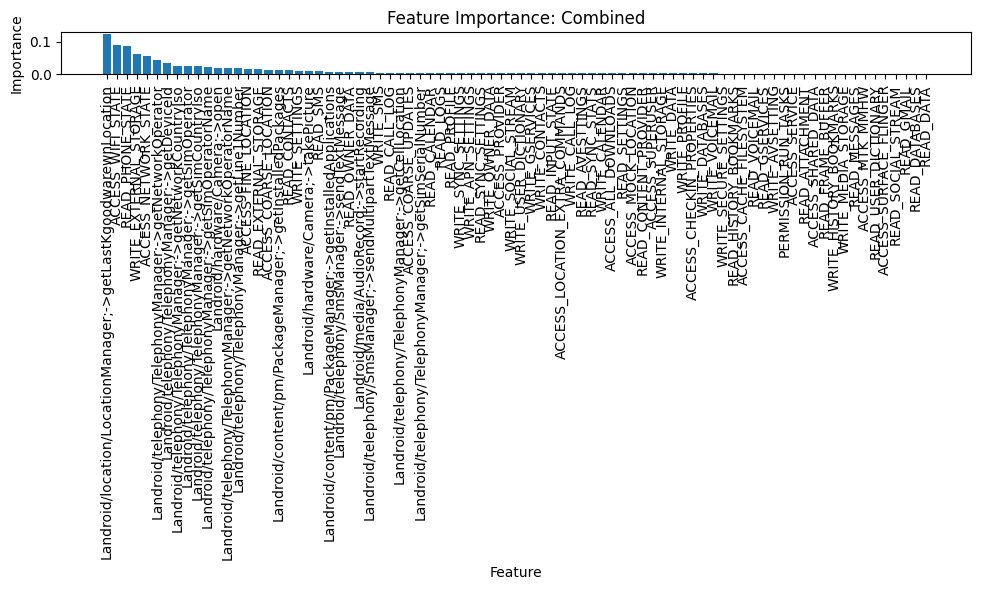

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


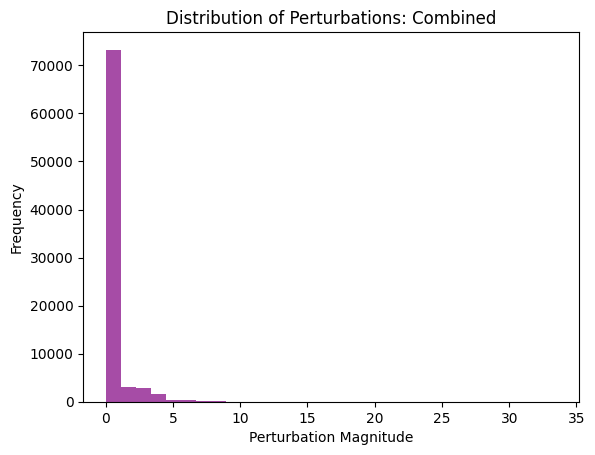


Retrained Model Performance on Combined Features:
Accuracy: 0.8611500701262272


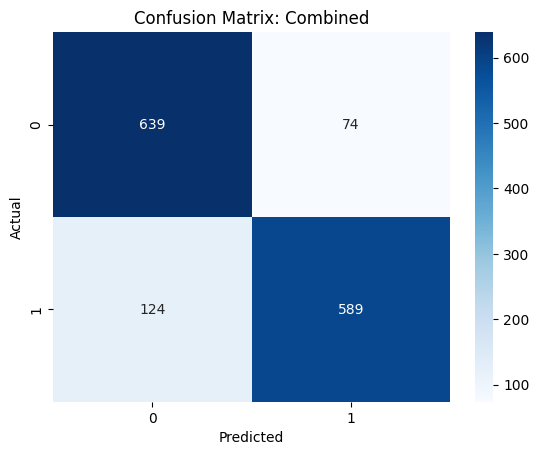

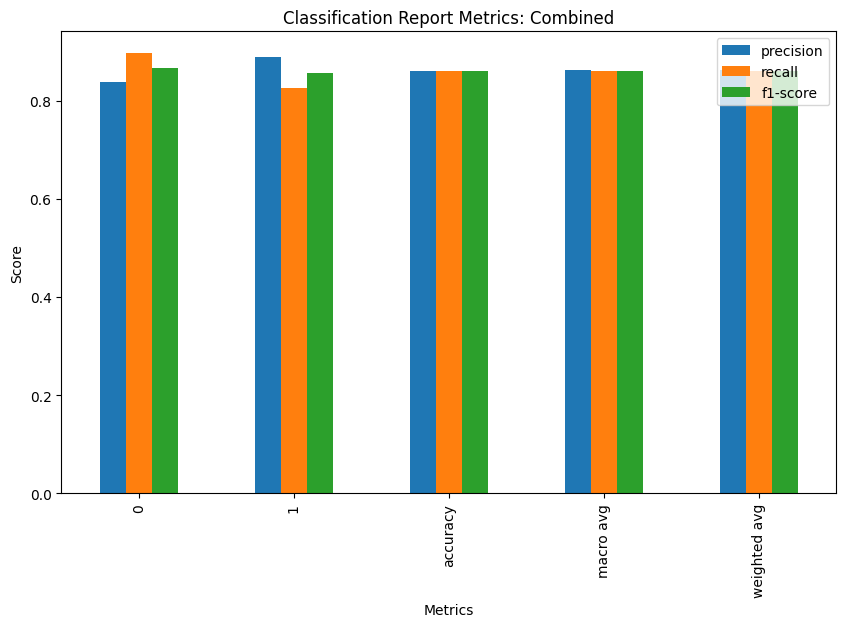

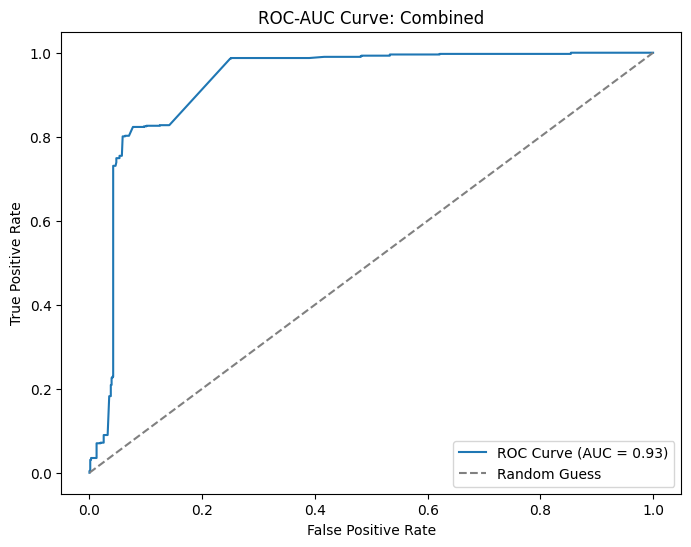

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


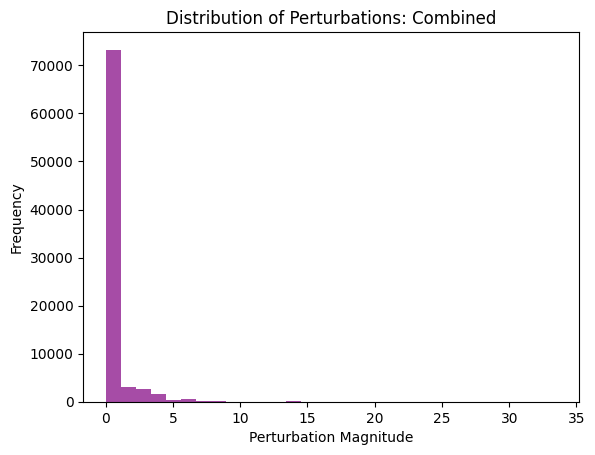


Retrained Model Performance on Combined Features:
Accuracy: 0.8863955119214586


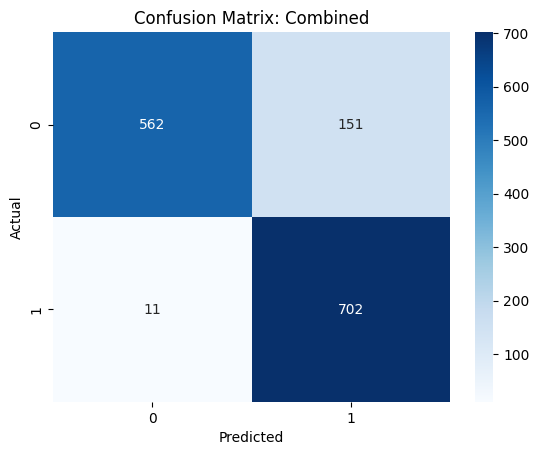

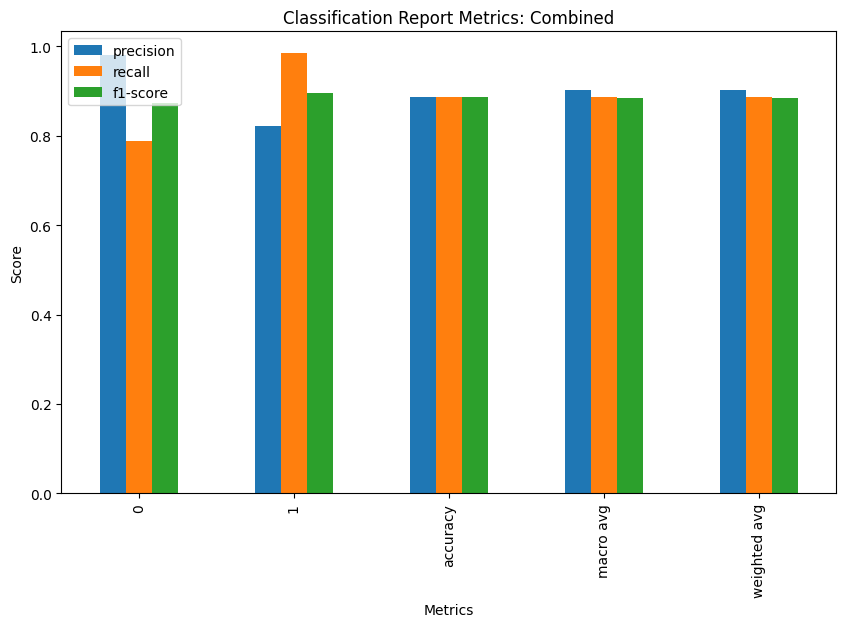

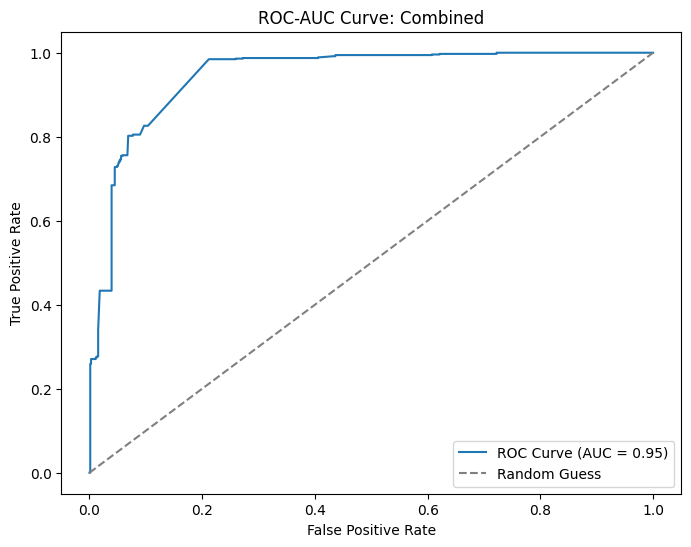

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


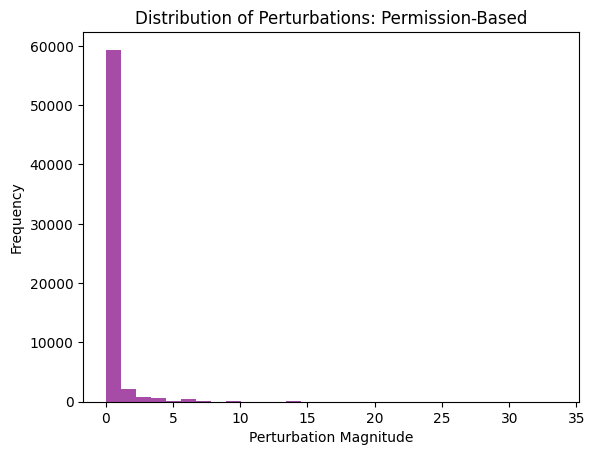


Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8892005610098177


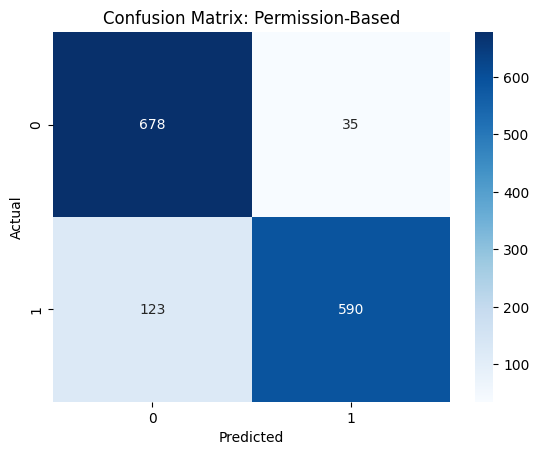

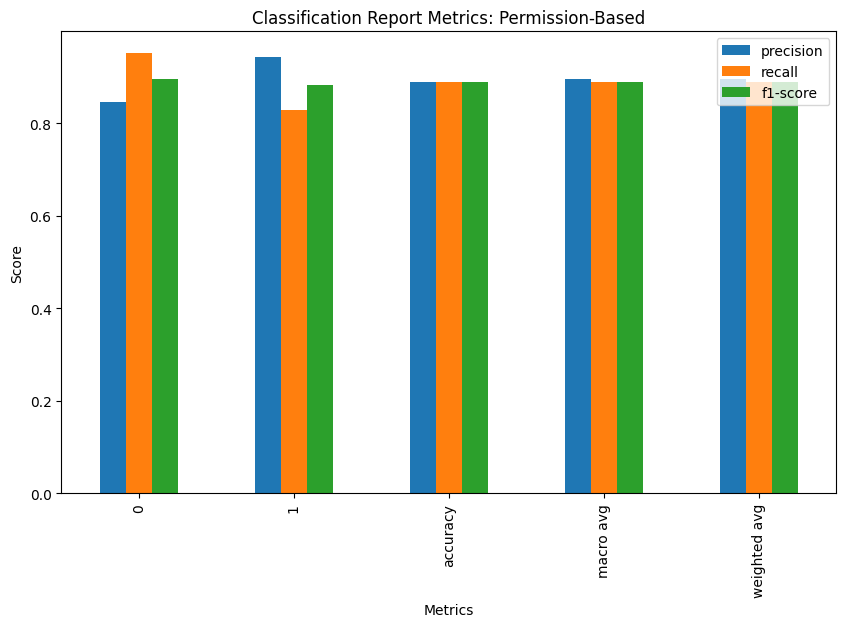

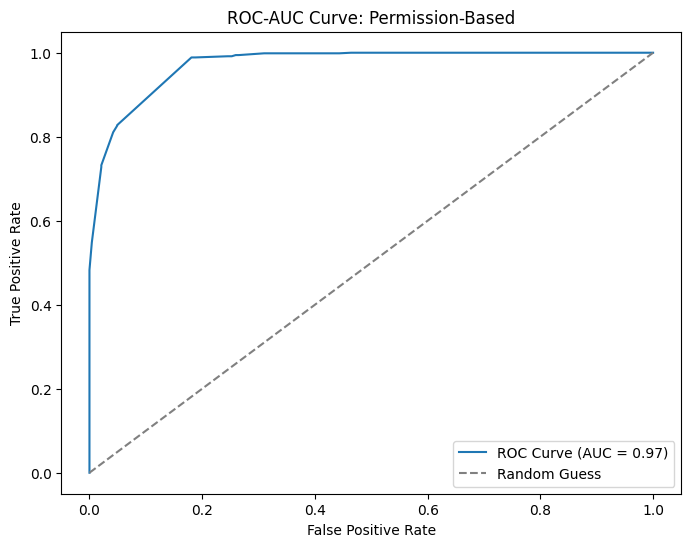

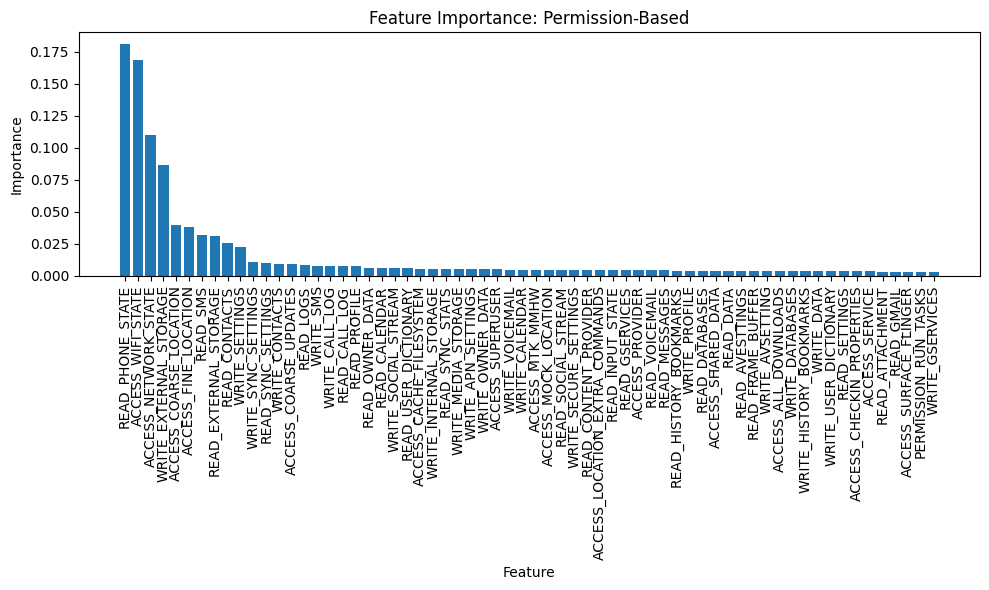

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


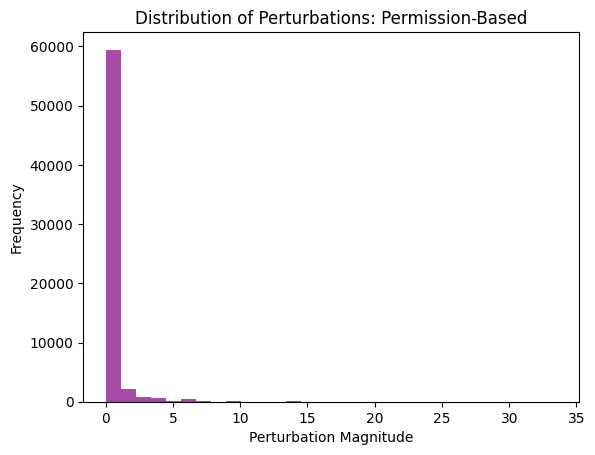


Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8309957924263675


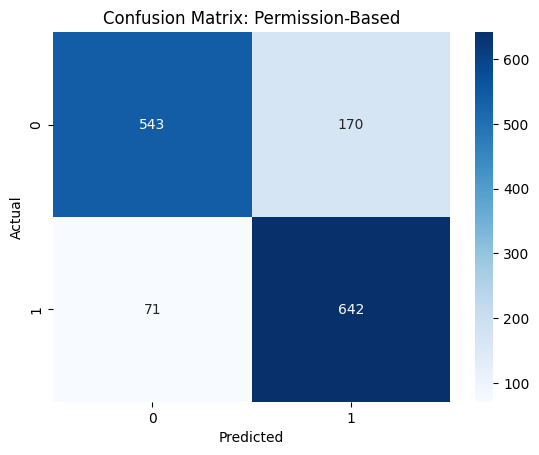

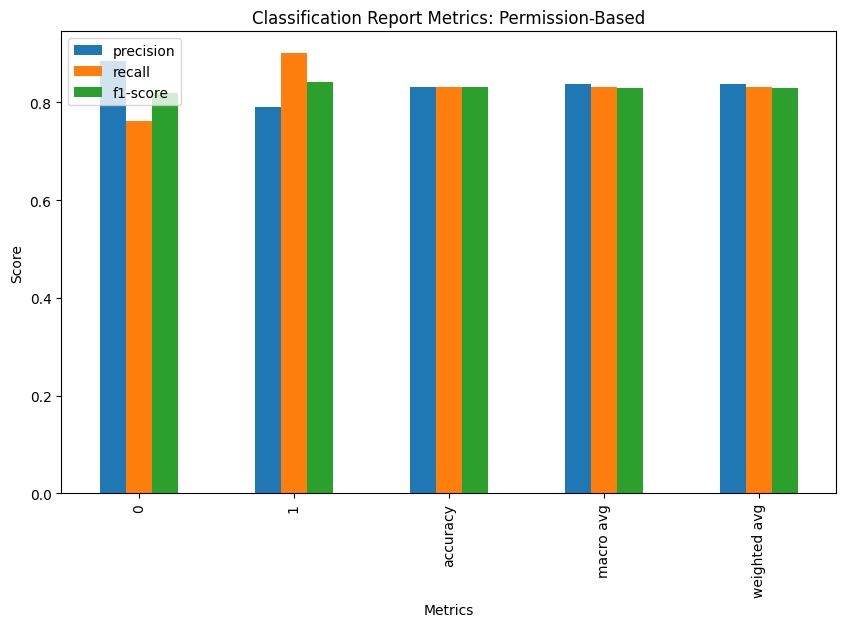

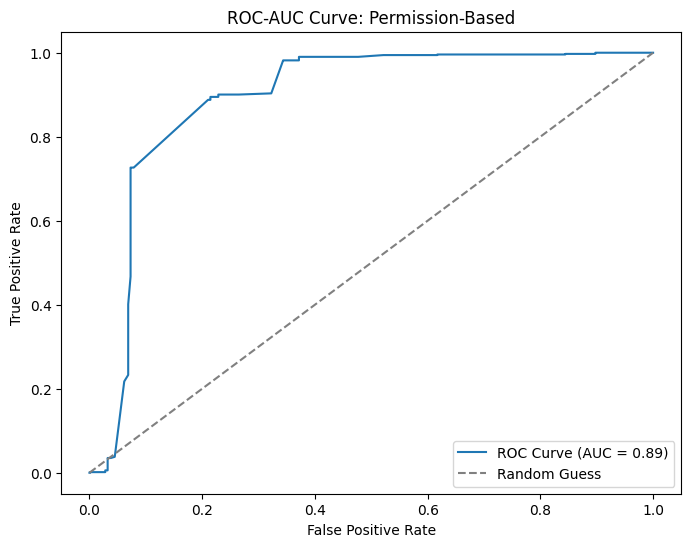

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


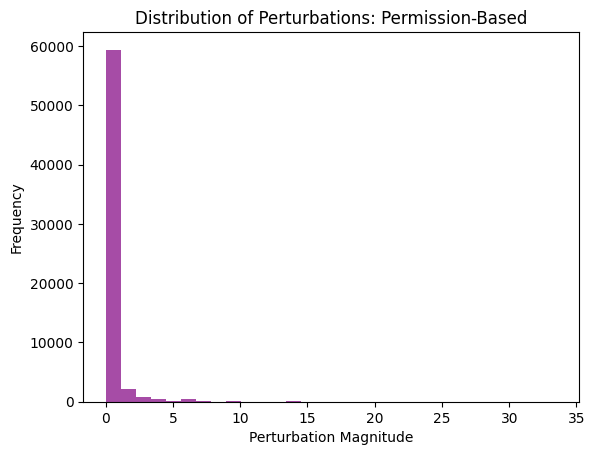


Retrained Model Performance on Permission-Based Features:
Accuracy: 0.8092566619915849


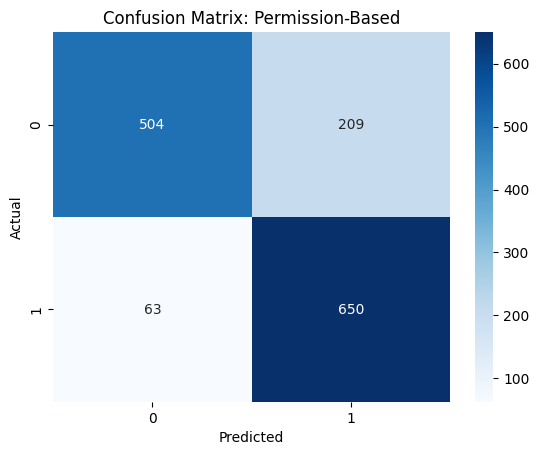

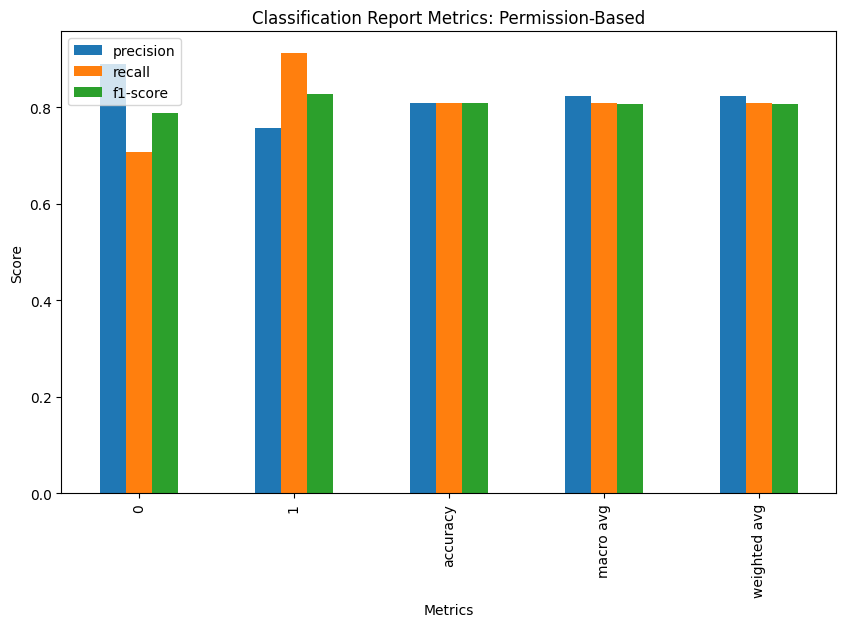

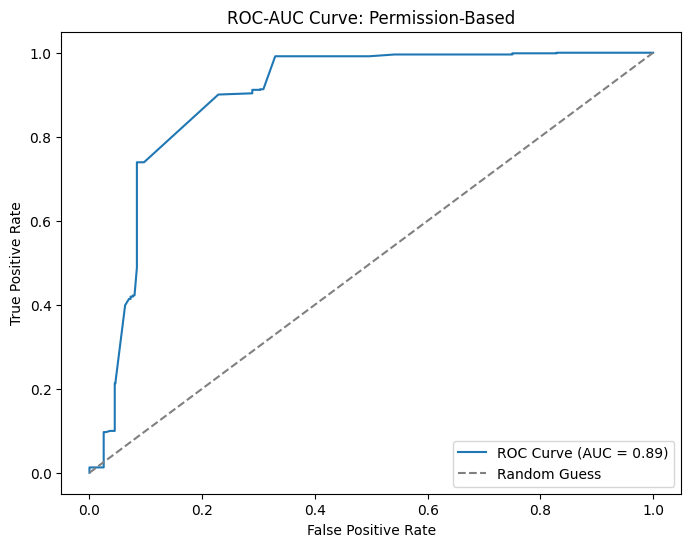

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


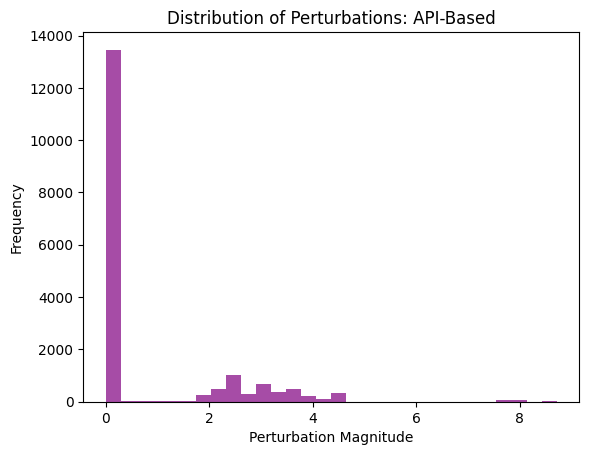


Retrained Model Performance on API-Based Features:
Accuracy: 0.8492286115007013


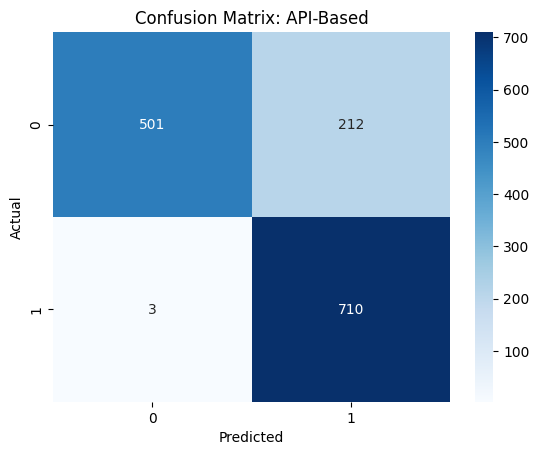

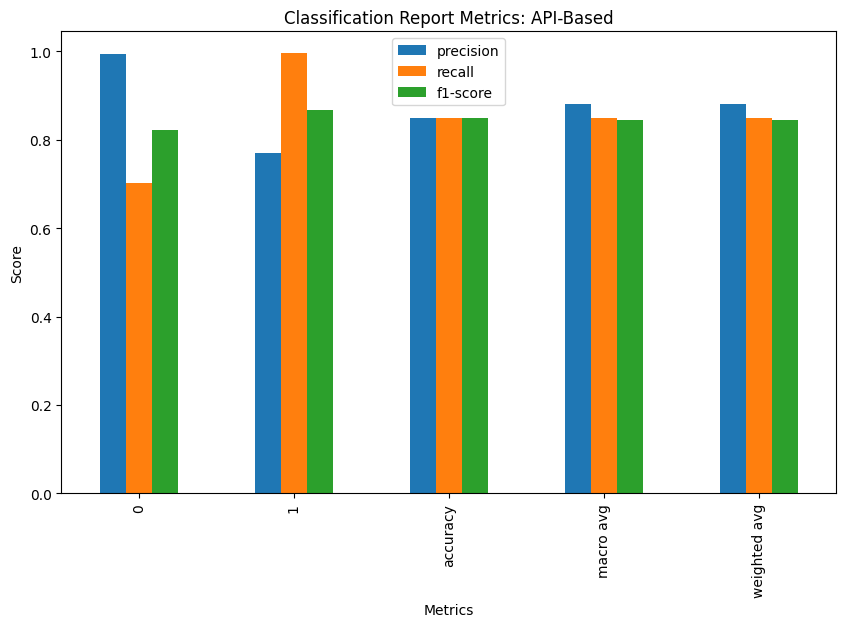

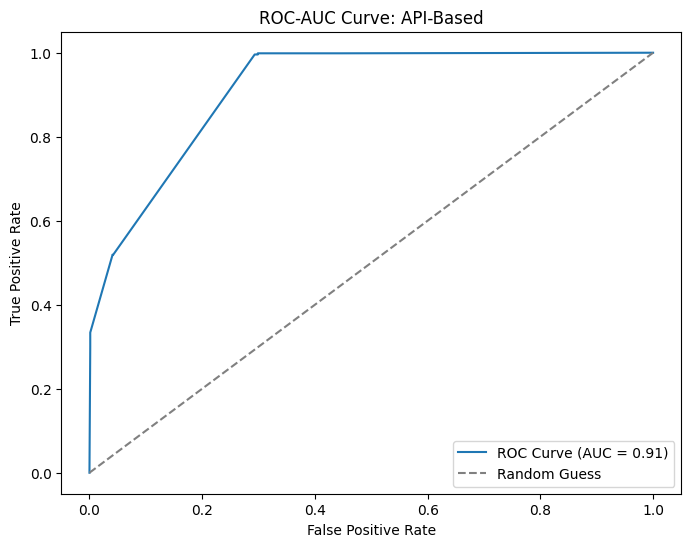

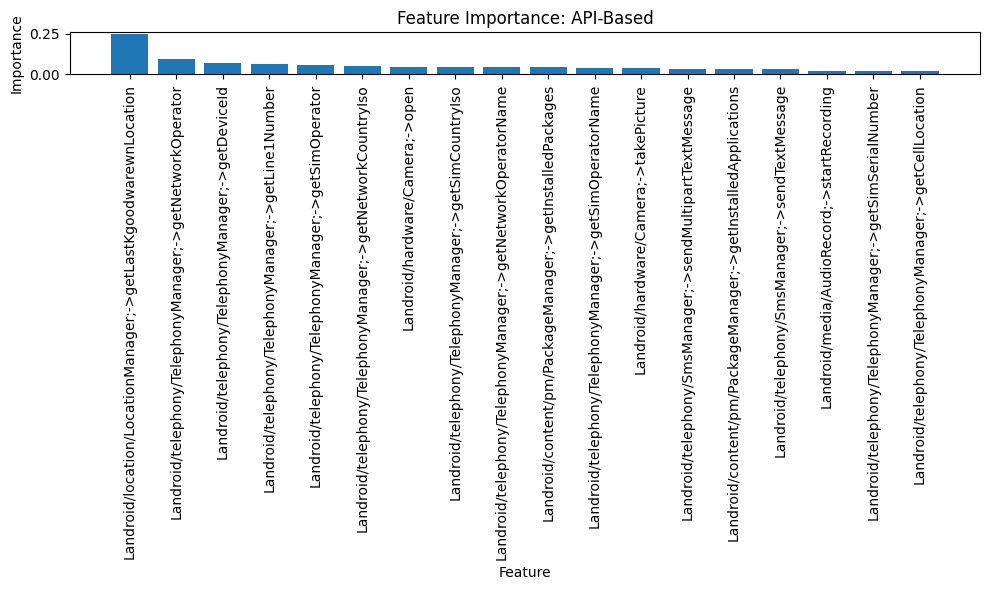

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


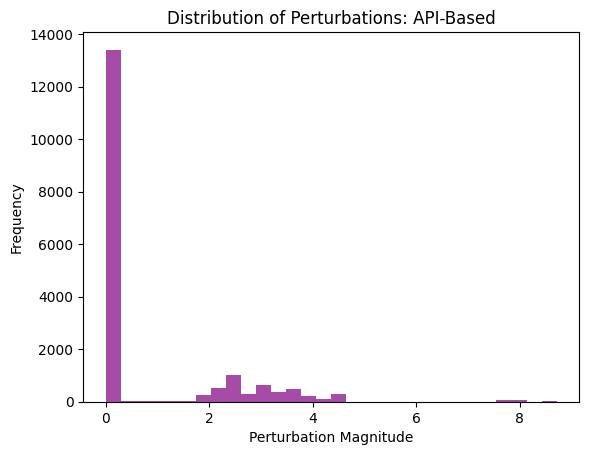


Retrained Model Performance on API-Based Features:
Accuracy: 0.8015427769985974


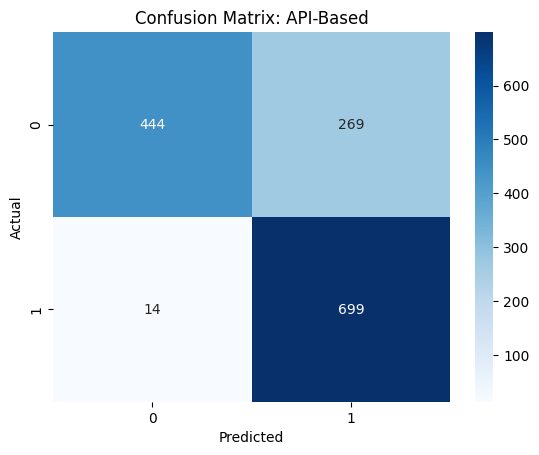

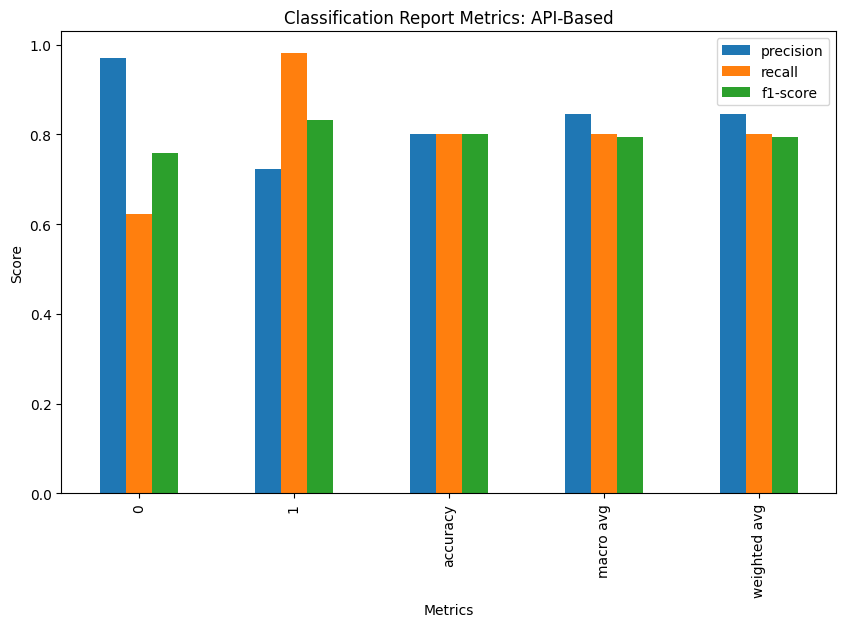

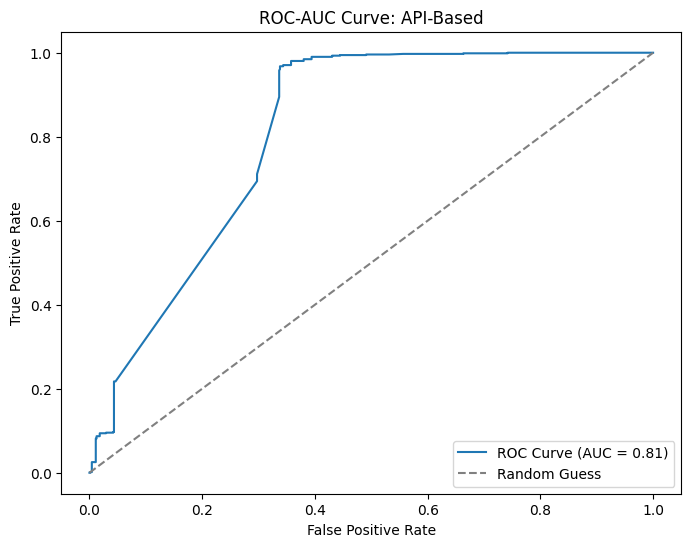

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


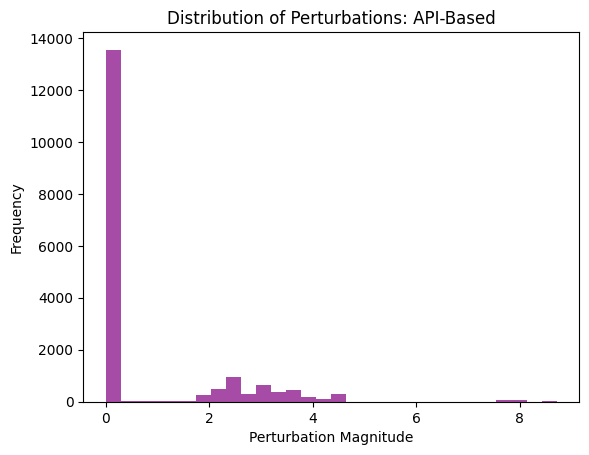


Retrained Model Performance on API-Based Features:
Accuracy: 0.8162692847124825


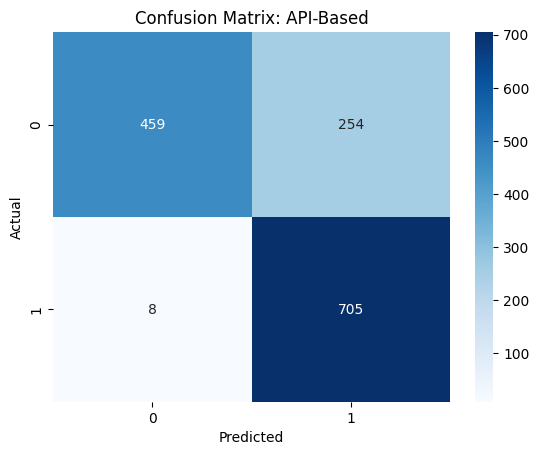

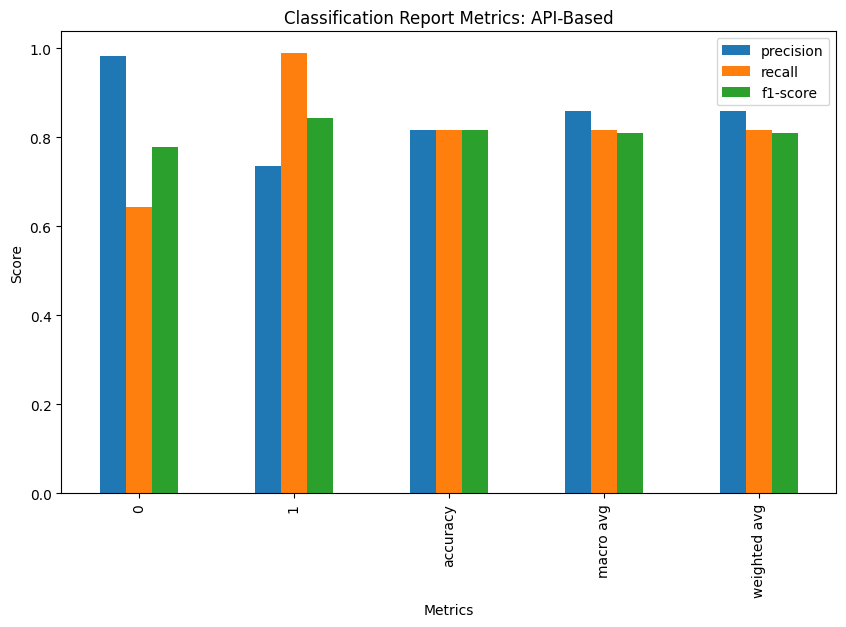

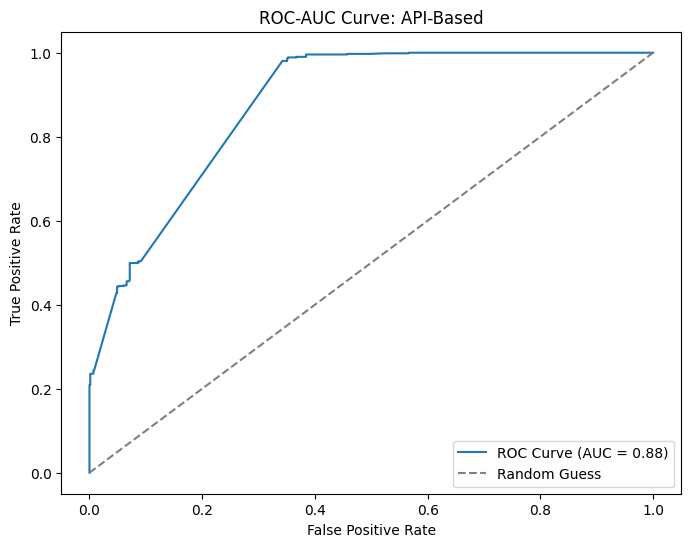

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc,
    precision_recall_fscore_support
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO

# Function for plotting performance metrics
def plot_metrics(y_test, y_pred, y_pred_proba, title):
    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.drop("support", axis=1).plot(kind="bar", figsize=(10, 6))
    plt.title(f"Classification Report Metrics: {title}")
    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.show()

    # ROC-AUC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.2f})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random Guess")
    plt.title(f"ROC-AUC Curve: {title}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Function for plotting adversarial perturbations
def plot_perturbations(original_samples, perturbed_samples, title):
    original_samples_subset = original_samples[np.random.choice(original_samples.shape[0], size=perturbed_samples.shape[0], replace=False)]

    perturbations = np.abs(perturbed_samples - original_samples_subset)  # Calculate perturbations for the subset
    plt.hist(perturbations.flatten(), bins=30, color='purple', alpha=0.7)
    plt.title(f"Distribution of Perturbations: {title}")
    plt.xlabel("Perturbation Magnitude")
    plt.ylabel("Frequency")
    plt.show()

# Function for feature importance (Random Forest only)
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.bar(range(len(importances)), importances[indices], align="center")
        plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
        plt.title(f"Feature Importance: {title}")
        plt.xlabel("Feature")
        plt.ylabel("Importance")
        plt.tight_layout()
        plt.show()

# Generate adversarial samples and retrain for each feature type
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set, feature_names):
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    perturbed_samples = np.array(perturbations)
    plot_perturbations(X_train, perturbed_samples, feature_set)

    import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc,
    precision_recall_fscore_support
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import gym
from stable_baselines3 import PPO

# Function for plotting performance metrics
def plot_metrics(y_test, y_pred, y_pred_proba, title):
    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.drop("support", axis=1).plot(kind="bar", figsize=(10, 6))
    plt.title(f"Classification Report Metrics: {title}")
    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.show()

    # ROC-AUC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.2f})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random Guess")
    plt.title(f"ROC-AUC Curve: {title}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Function for plotting adversarial perturbations
def plot_perturbations(original_samples, perturbed_samples, title):
    original_samples_subset = original_samples[np.random.choice(original_samples.shape[0], size=perturbed_samples.shape[0], replace=False)]

    perturbations = np.abs(perturbed_samples - original_samples_subset)  # Calculate perturbations for the subset
    plt.hist(perturbations.flatten(), bins=30, color='purple', alpha=0.7)
    plt.title(f"Distribution of Perturbations: {title}")
    plt.xlabel("Perturbation Magnitude")
    plt.ylabel("Frequency")
    plt.show()

# Function for feature importance (Random Forest only)
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.bar(range(len(importances)), importances[indices], align="center")
        plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
        plt.title(f"Feature Importance: {title}")
        plt.xlabel("Feature")
        plt.ylabel("Importance")
        plt.tight_layout()
        plt.show()

# Generate adversarial samples and retrain for each feature type
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set, feature_names):
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    perturbed_samples = np.array(perturbations)
    plot_perturbations(X_train, perturbed_samples, feature_set)

    X_augmented = np.vstack([X_train, perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])

    # Retrain the model with augmented data
    model.fit(X_augmented, y_augmented)

    # Predict only on the original test data
    y_pred = model.predict(X_test)  # Change here
    y_pred_proba = model.predict_proba(X_test)  # Change here

    print(f"\nRetrained Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # Plot Metrics
    plot_metrics(y_test, y_pred, y_pred_proba, feature_set)

    # Feature Importance
    plot_feature_importance(model, feature_names, feature_set)

# Apply the updated code for each feature set and model
# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Combined Features
combined_features = permission_features + api_features
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined", combined_features)
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined", combined_features)
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined", combined_features)

# Permission-Based Features
generate_adversarial_and_retrain(rf_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based", permission_features)
generate_adversarial_and_retrain(svm_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based", permission_features)
generate_adversarial_and_retrain(lr_model, X_train_permissions, X_test_permissions, y_train, y_test, "Permission-Based", permission_features)

# API-Based Features
generate_adversarial_and_retrain(rf_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based", api_features)
generate_adversarial_and_retrain(svm_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based", api_features)
generate_adversarial_and_retrain(lr_model, X_train_apis, X_test_apis, y_train, y_test, "API-Based", api_features)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import gym

# Step 1: Define FGSM Adversarial Attack
def fgsm_attack(model, input_data, epsilon):
    """Generates adversarial samples using FGSM."""
    input_tensor = tf.convert_to_tensor(input_data, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor)
        loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(
            tf.one_hot([0]*len(predictions), depth=predictions.shape[-1]), predictions))
    gradient = tape.gradient(loss, input_tensor)
    adversarial_data = input_data + epsilon * tf.sign(gradient)
    return tf.clip_by_value(adversarial_data, 0, 1)

# Step 2: Modify the Environment to Incorporate Adversarial Examples
class ActiveLearningEnv(gym.Env):
    def __init__(self, X_pool, y_pool, model, epsilon=0.1):
        super(ActiveLearningEnv, self).__init__()
        self.X_pool = X_pool
        self.y_pool = y_pool
        self.model = model  # Adversarial attack uses this model
        self.epsilon = epsilon
        self.action_space = gym.spaces.Discrete(len(X_pool))
        self.observation_space = gym.spaces.Box(
            low=0, high=1, shape=X_pool.shape[1:], dtype=np.float32
        )

    def reset(self):
        self.current_index = 0
        self.selected_indices = []
        return self._apply_adversarial_attack(self.X_pool[self.current_index])

    def step(self, action):
        if action in self.selected_indices:
            reward = -1  # Penalize selecting the same sample
        else:
            self.selected_indices.append(action)
            reward = self._calculate_reward(action)

        self.current_index += 1
        done = self.current_index >= len(self.X_pool) - 1
        obs = (self._apply_adversarial_attack(self.X_pool[self.current_index])
               if not done else np.zeros_like(self.X_pool[0]))

        return obs, reward, done, {}

    def _calculate_reward(self, action):
        # Reward based on uncertainty (higher uncertainty yields a higher reward)
        uncertainty = 1 - np.max(probs[action])
        return uncertainty

    def _apply_adversarial_attack(self, data):
        return fgsm_attack(self.model, data[np.newaxis], self.epsilon).numpy()[0]

# Step 3: Build the RL agent
class RLAgent:
    def __init__(self, state_size, action_size, lr=0.001):
        self.state_size = state_size
        self.action_size = action_size
        self.model = self._build_model(lr)

    def _build_model(self, lr):
        model = Sequential([
            Dense(64, activation="relu", input_shape=(self.state_size,)),
            Dense(64, activation="relu"),
            Dense(self.action_size, activation="linear")
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
        return model

    def act(self, state, epsilon):
        if np.random.rand() <= epsilon:
            return np.random.choice(self.action_size)
        q_values = self.model.predict(state[np.newaxis], verbose=0)
        return np.argmax(q_values[0])

    def train(self, state, action, reward, next_state, done, gamma=0.95):
        target = reward
        if not done:
            target += gamma * np.amax(self.model.predict(next_state[np.newaxis], verbose=0)[0])

        target_f = self.model.predict(state[np.newaxis], verbose=0)
        target_f[0][action] = target
        self.model.fit(state[np.newaxis], target_f, epochs=1, verbose=0)

# Step 4: Replace baseline_model with a differentiable model
nn_baseline_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(len(np.unique(y_train)), activation="softmax")
])
nn_baseline_model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy")
nn_baseline_model.fit(X_train_scaled, y_train, epochs=10, verbose=1)

# Step 5: Set up the training loop
n_samples = int(0.1 * len(X_train_scaled))
probs = nn_baseline_model.predict(X_train_scaled)
uncertain_indices = uncertainty_sampling(probs, n_samples)
X_active = X_train_scaled[uncertain_indices]
y_active = y_train.iloc[uncertain_indices]

env = ActiveLearningEnv(X_active, y_active, nn_baseline_model, epsilon=0.1)
agent = RLAgent(state_size=X_active.shape[1], action_size=len(X_active))

n_episodes = 1000
batch_size = 32
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
gamma = 0.95

for episode in range(n_episodes):
    state = env.reset()
    total_reward = 0

    while True:
        action = agent.act(state, epsilon)
        next_state, reward, done, _ = env.step(action)
        agent.train(state, action, reward, next_state, done, gamma)
        state = next_state
        total_reward += reward

        if done:
            print(f"Episode {episode+1}/{n_episodes}, Total Reward: {total_reward}")
            break

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

print("RL agent training with adversarial attacks complete.")

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3150
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0366
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0214
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0168
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0108
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0097
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102
Epoch 9/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0101
Epoch 10/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0103
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Episode 1/1000, Total Reward: -205.04971528053284
Episode 2/1000, Total Reward: -212.1089579463005
Episode 3/1000, Total Reward: -217.1646353006363
Episode 4/1000, Total Reward: -212.1807410120964
Episode 5/1000, Total Reward: -210.11905884742737
Episode 6/1000, Total Reward: -212.044328

KeyboardInterrupt: 

####defense

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9464
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6611
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5745
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5860
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6663
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5880
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5493
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6240
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5802
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5707
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5753
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6129
Epoch 13/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6232
Epoch 14/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5658
Epoch 15/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5715
Epoch 16/20
70/70 ━━━━━━━━━━━━

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Defended Model Performance on Combined Features:
Accuracy (on augmented test set): 0.7522671063478977


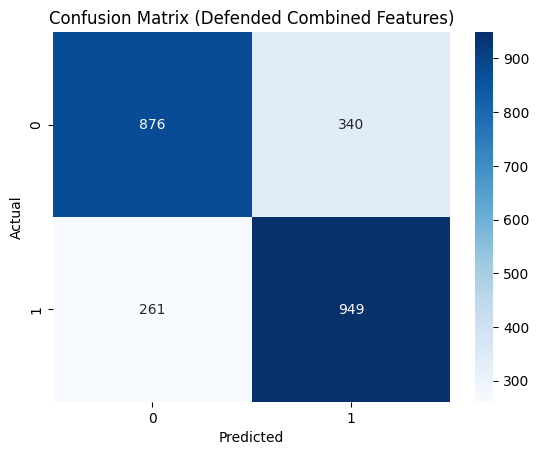

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Defended Model Performance on Combined Features:
Accuracy (on augmented test set): 0.7221764220939819


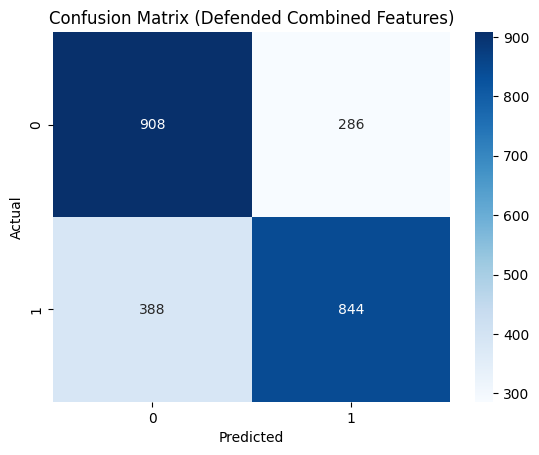

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Defended Model Performance on Combined Features:
Accuracy (on augmented test set): 0.7143446001648804


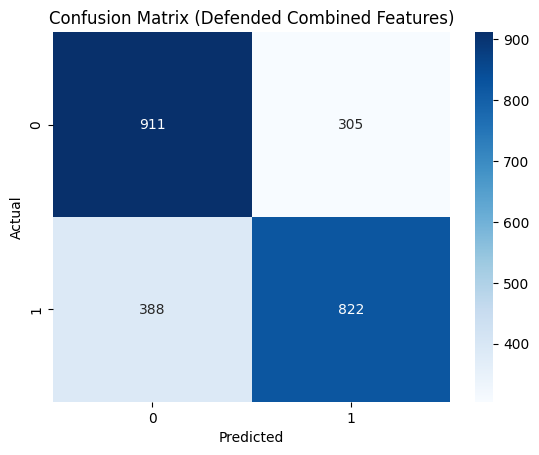

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from stable_baselines3 import PPO
import gym

# Preprocessing and feature extraction
class_counts = data['Label'].value_counts()
min_class_count = class_counts.min()
if min_class_count < 2:
    print("Warning: Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Separate features
X_permissions = data[permission_features]
X_apis = data[api_features]
X_combined = data[permission_features + api_features]

scaler = StandardScaler()
X_permissions_scaled = scaler.fit_transform(X_permissions)
X_apis_scaled = scaler.fit_transform(X_apis)
X_combined_scaled = scaler.fit_transform(X_combined)

smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.current_index = 0
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] + self.epsilon * action
        perturbed_sample = np.clip(perturbed_sample, 0, 1)
        predicted_class = self.model.predict([perturbed_sample])[0]
        success = predicted_class != self.y_train[self.current_idx]
        reward = 1 if success else -1
        done = True
        return perturbed_sample, reward, done, {}

# Build and train autoencoder for feature squeezing
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dense(64, activation='relu')(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(128, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder

input_dim = X_combined_scaled.shape[1]
autoencoder = build_autoencoder(input_dim)
autoencoder.fit(X_combined_scaled, X_combined_scaled, epochs=20, batch_size=64, shuffle=True, verbose=1)

# Feature squeezing by reconstruction
def reconstruct_samples(X):
    return autoencoder.predict(X)

# Preprocess and defend against adversarial attacks
def preprocess_and_defend(X):
    reconstructed_X = reconstruct_samples(X)
    return reconstructed_X

# Generate adversarial samples and retrain for defense
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train, perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])

    X_augmented_test = np.vstack([X_test, perturbations])
    y_augmented_test = np.hstack([y_test, np.random.choice(y_test, size=len(perturbations))])

    # Apply defense (autoencoder) on augmented data
    X_augmented_defended = preprocess_and_defend(X_augmented)
    X_test_defended = preprocess_and_defend(X_augmented_test)

    # Retrain the model with defended augmented data
    model.fit(X_augmented_defended, y_augmented)

    # Evaluate the defended model
    y_pred = model.predict(X_test_defended)  # Predictions on augmented test set
    print(f"\nDefended Model Performance on {feature_set} Features:")
    print("Accuracy (on augmented test set):", accuracy_score(y_augmented_test, y_pred))
    sns.heatmap(confusion_matrix(y_augmented_test, y_pred), annot=True, fmt="d", cmap="Blues")  # Use augmented y_test
    plt.title(f"Confusion Matrix (Defended {feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # You can still evaluate on the original test set if needed:
    #y_pred_original_test = model.predict(preprocess_and_defend(X_test)) # Predictions on original test set
    #print("Accuracy (on original test set):", accuracy_score(y_test, y_pred_original_test))


# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Retrain models with adversarial data and apply defense
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.9574
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8256
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6932
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6292
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6160
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6114
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5988
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6151
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6175
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6725
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5855
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6311
Epoch 13/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5579
Epoch 14/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6645
Epoch 15/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5948
Epoch 16

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Defended Model Performance on Combined Features:
Accuracy: 0.7481450948062655


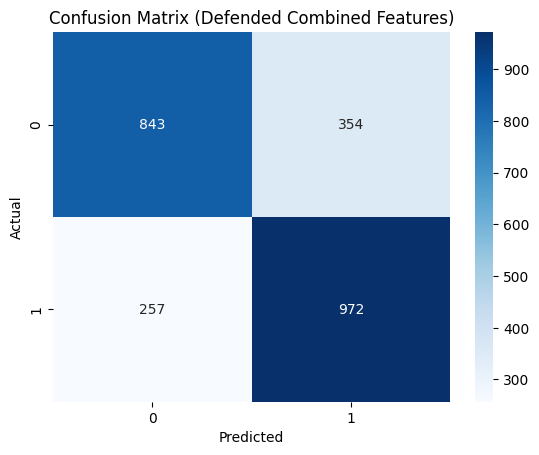

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Defended Model Performance on Combined Features:
Accuracy: 0.7159934047815334


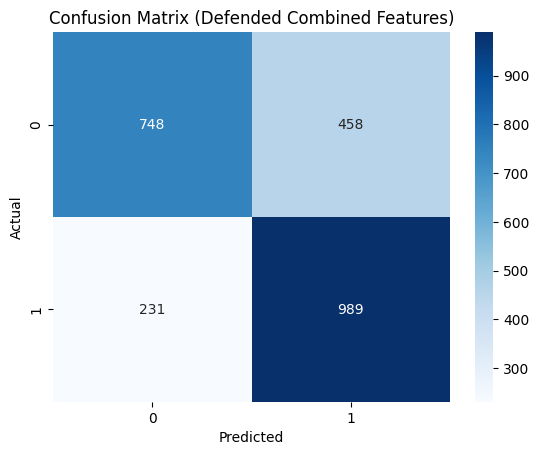

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Defended Model Performance on Combined Features:
Accuracy: 0.7176422093981863


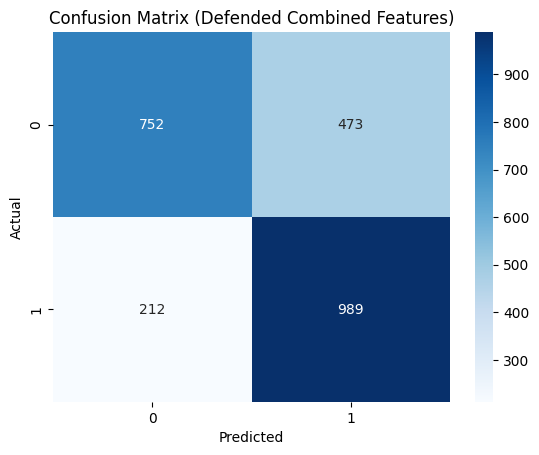

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from stable_baselines3 import PPO
import gym

# Preprocessing and feature extraction
class_counts = data['Label'].value_counts()
min_class_count = class_counts.min()
if min_class_count < 2:
    print("Warning: Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Separate features
X_permissions = data[permission_features]
X_apis = data[api_features]
X_combined = data[permission_features + api_features]

scaler = StandardScaler()
X_permissions_scaled = scaler.fit_transform(X_permissions)
X_apis_scaled = scaler.fit_transform(X_apis)
X_combined_scaled = scaler.fit_transform(X_combined)

smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.current_index = 0
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] + self.epsilon * action
        perturbed_sample = np.clip(perturbed_sample, 0, 1)
        predicted_class = self.model.predict([perturbed_sample])[0]
        success = predicted_class != self.y_train[self.current_idx]
        reward = 1 if success else -1
        done = True
        return perturbed_sample, reward, done, {}

# Build and train autoencoder for feature squeezing
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dense(64, activation='relu')(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dropout(0.2)(encoded)  # Adding Dropout to improve generalization
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(decoded)
    decoded = Dense(128, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder
#run the code twice
#X_augmented
input_dim = X_combined_scaled.shape[1]
autoencoder = build_autoencoder(input_dim)
autoencoder.fit(X_combined_scaled, X_combined_scaled, epochs=30, batch_size=128, shuffle=True, verbose=1)

# Feature squeezing by reconstruction
def reconstruct_samples(X):
    return autoencoder.predict(X)

# Preprocess and defend against adversarial attacks
def preprocess_and_defend(X):
    reconstructed_X = reconstruct_samples(X)
    return reconstructed_X

# Generate adversarial samples and retrain for defense
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    global X_augmented
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train,perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])
    X_augmented_test = np.vstack([X_test, perturbations])
    y_augmented_test = np.hstack([y_test, np.random.choice(y_test, size=len(perturbations))])

    # Apply defense (autoencoder) on augmented data
    X_augmented_defended = preprocess_and_defend(X_augmented)
    X_test_defended = preprocess_and_defend(X_augmented_test)

    # Retrain the model with defended augmented data
    model.fit(X_augmented_defended, y_augmented)

    # Evaluate the defended model
    y_pred = model.predict(X_test_defended)
    print(f"\nDefended Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_augmented_test, y_pred))
    sns.heatmap(confusion_matrix(y_augmented_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix (Defended {feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Retrain models with adversarial data and apply defense
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.9510
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7133
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7213
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6672
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5773
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6631
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6411
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6284
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6416
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6677
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6292
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5769
Epoch 13/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5578
Epoch 14/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5990
Epoch 15/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6092
Epoch 16/30
35/3

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Defended Model Performance on Combined Features:
Accuracy: 0.7539159109645507


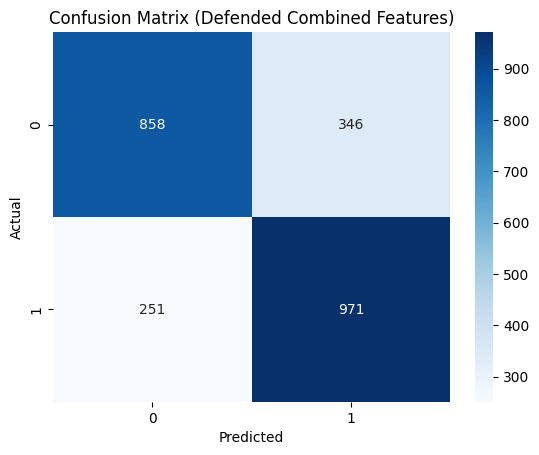

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Defended Model Performance on Combined Features:
Accuracy: 0.713520197856554


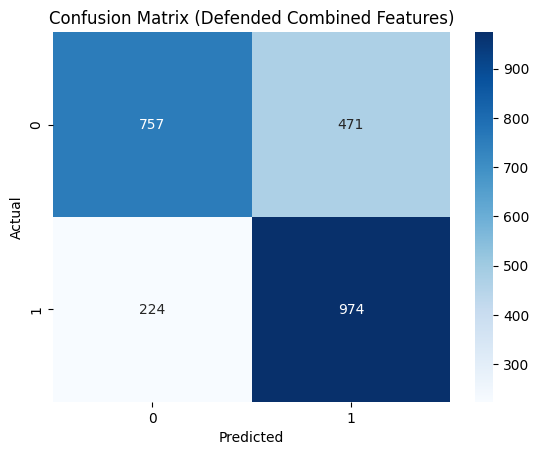

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Defended Model Performance on Combined Features:
Accuracy: 0.7217642209398186


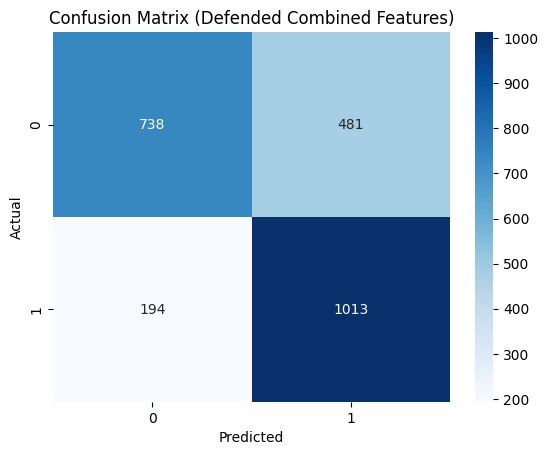

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from stable_baselines3 import PPO
import gym

# Preprocessing and feature extraction
class_counts = data['Label'].value_counts()
min_class_count = class_counts.min()
if min_class_count < 2:
    print("Warning: Removing under-represented classes.")
    valid_classes = class_counts[class_counts > 1].index
    data = data[data['Label'].isin(valid_classes)]

label_encoder = LabelEncoder()
y = data['Label']
y_encoded = label_encoder.fit_transform(y)

# Separate features
X_permissions = data[permission_features]
X_apis = data[api_features]
X_combined = data[permission_features + api_features]

scaler = StandardScaler()
X_permissions_scaled = scaler.fit_transform(X_permissions)
X_apis_scaled = scaler.fit_transform(X_apis)
X_combined_scaled = scaler.fit_transform(X_combined)

smote = SMOTE(random_state=0)
X_combined_resampled, y_resampled = smote.fit_resample(X_combined_scaled, y_encoded)

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Define a custom gym environment for adversarial attacks
class AdversarialEnv(gym.Env):
    def __init__(self, model, X_train, y_train, epsilon=0.1):
        super(AdversarialEnv, self).__init__()
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.current_index = 0
        self.action_space = gym.spaces.Box(low=-0.1, high=0.1, shape=X_train.shape[1:])
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=X_train.shape[1:])

    def reset(self):
        self.current_idx = np.random.choice(len(self.X_train))
        return self.X_train[self.current_idx]

    def step(self, action):
        perturbed_sample = self.X_train[self.current_idx] + self.epsilon * action
        perturbed_sample = np.clip(perturbed_sample, 0, 1)
        predicted_class = self.model.predict([perturbed_sample])[0]
        success = predicted_class != self.y_train[self.current_idx]
        reward = 1 if success else -1
        done = True
        return perturbed_sample, reward, done, {}

# Build and train autoencoder for feature squeezing
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dense(64, activation='relu')(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dropout(0.2)(encoded)  # Adding Dropout to improve generalization
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(decoded)
    decoded = Dense(128, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder
#run the code twice
#X_augmented
input_dim = X_combined_scaled.shape[1]
autoencoder = build_autoencoder(input_dim)
autoencoder.fit(X_combined_scaled, X_combined_scaled, epochs=30, batch_size=128, shuffle=True, verbose=1)

# Feature squeezing by reconstruction
def reconstruct_samples(X):
    return autoencoder.predict(X)

# Preprocess and defend against adversarial attacks
def preprocess_and_defend(X):
    reconstructed_X = reconstruct_samples(X)
    return reconstructed_X

# Generate adversarial samples and retrain for defense
def generate_adversarial_and_retrain(model, X_train, X_test, y_train, y_test, feature_set):
    global X_augmented
    model.fit(X_train, y_train)
    env = AdversarialEnv(model, X_train, y_train)
    adversarial_agent = PPO("MlpPolicy", env, verbose=0)
    adversarial_agent.learn(total_timesteps=5000)

    perturbations = []
    for _ in range(1000):
        obs = env.reset()
        action, _ = adversarial_agent.predict(obs)
        perturbations.append(obs + action)

    X_augmented = np.vstack([X_train,perturbations])
    y_augmented = np.hstack([y_train, np.random.choice(y_train, size=len(perturbations))])
    X_augmented_test = np.vstack([X_test, perturbations])
    y_augmented_test = np.hstack([y_test, np.random.choice(y_test, size=len(perturbations))])

    # Apply defense (autoencoder) on augmented data
    X_augmented_defended = preprocess_and_defend(X_augmented)
    X_test_defended = preprocess_and_defend(X_augmented_test)

    # Retrain the model with defended augmented data
    model.fit(X_augmented_defended, y_augmented)
    # Evaluate the defended model
    y_pred = model.predict(X_test_defended)
    print(f"\nDefended Model Performance on {feature_set} Features:")
    print("Accuracy:", accuracy_score(y_augmented_test, y_pred))
    sns.heatmap(confusion_matrix(y_augmented_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix (Defended {feature_set} Features)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Models to train
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Retrain models with adversarial data and apply defense
generate_adversarial_and_retrain(rf_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(svm_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
generate_adversarial_and_retrain(lr_model, X_train_combined, X_test_combined, y_train, y_test, "Combined")
